<a href="https://colab.research.google.com/github/Peiprjs/MAI3002-Framingham_Heart_Study/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing
## Imports (Packages and Data)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from colorama import Fore, Back, Style

from scipy import stats
from scipy.stats import levene

import numpy as np
from numpy.ma.core import indices

from sklearn import tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings

### Configs

In [2]:
Prod = False
DoLongCells = False # Long Cells are those take over 5 minutes per cell to run

DatasetURL = "https://raw.githubusercontent.com/LUCE-Blockchain/Databases-for-teaching/refs/heads/main/Framingham%20Dataset.csv"
DatasetLocal = "Framingham Dataset.csv"

In [3]:
if Prod: warnings.filterwarnings('ignore'); data=pd.read_csv(DatasetLocal)
else: data = pd.read_csv(DatasetURL)

### Function imports

#### Graphs
##### Correlation plot

In [4]:
def corr_plot(input_df):
    corr_df = input_df.corr()
    corr_mat = corr_df[corr_df.columns[::-1]].stack().reset_index(name="correlation")

    sns.set_style("whitegrid")
    g = sns.relplot(
        data=corr_mat,
        x="level_0", y="level_1", hue="correlation", size="correlation",
        palette="vlag", edgecolor=".7",
        height=10, sizes=(50, 250), hue_norm=(-0.5, 1),size_norm=(-0.5, 1),
    )

    g.set(xlabel="", ylabel="", aspect="equal")
    g.despine(left=True, bottom=True)
    g.ax.margins(.02)
    for label in g.ax.get_xticklabels():
        label.set_rotation(90)

##### Distplots


In [5]:
def distplots(df):
    numeric_df = df.select_dtypes(include=['number'])
    num_features = len(numeric_df.columns)
    cols = int(np.ceil(np.sqrt(num_features)))
    rows = int(np.ceil(num_features / cols))

    # A figure with subplots looks much nicer
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = axes.flatten()

    for i, column in enumerate(numeric_df.columns):
        # Technically not needed but might as well
        numeric_df_nona = numeric_df[column].dropna()

        axes[i].hist(numeric_df_nona, bins=30, alpha=0.7, edgecolor='black')

        if len(numeric_df_nona) > 1:
            density = stats.gaussian_kde(numeric_df_nona)
            xs = np.linspace(numeric_df_nona.min(), numeric_df_nona.max(), 200)
            axes[i].plot(xs, density(xs) * len(numeric_df_nona) * (numeric_df_nona.max() - numeric_df_nona.min()) / 30,
                         'r-', linewidth=2)

        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Number of Patients')
        axes[i].set_title(f'Distribution of {column}')
        axes[i].grid(axis='y', alpha=0.3)

    # Remove any empty subplots if they exist
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#### Imputation
##### Drop high missing columns

In [6]:
def drop_high_missing_cols(df, threshold=0.50):
    """
    1. Drops columns with a high percentage of missing values.
    """
    print(f"--- Running Step 1: Dropping columns > {threshold:.0%} missing ---")
    # Calculate missing percentage on the dataframe
    missing_pct = df.isnull().sum() / len(df)

    # Identify columns to drop based on the threshold
    cols_to_drop = missing_pct[missing_pct >= threshold].index.tolist()

    if cols_to_drop:
        print(f"   -> Dropping columns: {', '.join(cols_to_drop)}")
        # Drop columns from the dataframe
        df_dropped = df.drop(columns=cols_to_drop)
    else:
        print("   -> No columns exceeded the missing value threshold.")
        df_dropped = df.copy()

    return df_dropped

##### Dataframe reconstruction

In [7]:
def _reconstruct_dataframe(encoded_df, original_df, num_cols, cat_cols, enc):
    """
    Internal helper function to revert a one-hot encoded DataFrame
    back to its original shape.
    """
    # Isolate the imputed numerical data
    # Ensure we only select num_cols that are still in the encoded_df
    present_num_cols = [col for col in num_cols if col in encoded_df.columns]
    imputed_numerical = encoded_df[present_num_cols]

    # Isolate the encoded columns to be inverse-transformed
    encoded_cols_names = enc.get_feature_names_out(cat_cols)

    # Ensure all expected encoded columns are present, fill with 0 if not
    for col in encoded_cols_names:
        if col not in encoded_df.columns:
            encoded_df[col] = 0

    imputed_encoded = encoded_df[encoded_cols_names]

    # Perform the inverse transform
    imputed_categorical_array = enc.inverse_transform(imputed_encoded)

    # Convert the result back to a DataFrame
    imputed_categorical = pd.DataFrame(imputed_categorical_array,
                                       columns=cat_cols,
                                       index=encoded_df.index)

    # Combine numerical and reverted categorical data
    reconstructed_df = pd.concat([imputed_numerical, imputed_categorical], axis=1)

    # Enforce the original column order
    # Use .columns.intersection() to avoid errors if columns were dropped
    original_cols_present = original_df.columns.intersection(reconstructed_df.columns)
    final_df = reconstructed_df.reindex(columns=original_cols_present)

    return final_df

##### KNN imputation

In [8]:
def knn_impute(df, min_thresh=0.05, max_thresh=0.50, n_neighbors=3):
    """
    2. Uses KNN Imputation for columns with moderate missing values (5%-50%).

    What the function does:
    - One-hot encodes categorical data.
    - Trains KNN models (Regressor or Classifier) on the data
      to predict its own missing values.
    - Reconstructs the dataframe back to its original format.
    """
    print(f"\n--- Running Step 2: KNN Imputation ({min_thresh:.0%} - {max_thresh:.0%} missing) ---")
    # Create a copy to avoid modifying the original dataframe
    df_imputed = df.copy()

    # --- 1. One-Hot Encoding ---

    # Identify categorical/numerical columns
    categorical_cols = [col for col in df_imputed.columns
                        if df_imputed[col].dtype == 'object']
    numerical_cols = [col for col in df_imputed.columns
                      if df_imputed[col].dtype != 'object']

    # Initialize encoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    # Handle case with no categorical columns
    if not categorical_cols:
        print("   -> No categorical columns found. Skipping encoding.")
        df_encoded = df_imputed.copy()
        encoder = None  # Flag that no encoder was used
    else:
        print(f"   -> Fitting OneHotEncoder on {len(categorical_cols)} columns...")
        # Fit and transform the data
        encoded_cols_df = pd.DataFrame(encoder.fit_transform(df_imputed[categorical_cols]),
                                       columns=encoder.get_feature_names_out(categorical_cols),
                                       index=df_imputed.index)

        # Create the new, fully encoded dataframe
        df_encoded = df_imputed.drop(columns=categorical_cols).join(encoded_cols_df)
        print(f"   -> Data encoded. New shape: {df_encoded.shape}")

    # --- 2. KNN Imputation on Data ---

    # Calculate means *once* to be used for filling features (not targets)
    feature_fill_values = df_encoded.mean()

    for col in df_encoded.columns:
        missing_pct = df_encoded[col].isnull().mean()

        # Apply KNN to columns with moderate missingness
        if min_thresh <= missing_pct <= max_thresh:
            print(f"   -> KNN Imputing '{col}' (Missing: {missing_pct:.2%})")

            other_cols = [c for c in df_encoded.columns if c != col]

            # Split data for the imputer model
            train_rows = df_encoded[col].notnull()
            predict_rows = df_encoded[col].isnull()

            # If no rows to predict, skip
            if not predict_rows.any():
                print(f"      -> Skipping '{col}', no rows to predict.")
                continue

            # Fill NaNs in *features* with the mean for model stability
            X_train = df_encoded.loc[train_rows, other_cols].fillna(feature_fill_values)
            y_train = df_encoded.loc[train_rows, col]
            X_predict = df_encoded.loc[predict_rows, other_cols].fillna(feature_fill_values)

            # Select and train the appropriate KNN model
            is_binary = y_train.nunique() <= 2
            model = KNeighborsClassifier(n_neighbors=n_neighbors) if is_binary else KNeighborsRegressor(
                n_neighbors=n_neighbors)

            model.fit(X_train, y_train)
            predicted_values = model.predict(X_predict)

            # Assign the predicted values back to the encoded dataframe
            df_encoded.loc[predict_rows, col] = predicted_values
            print(f"      -> Successfully imputed {len(predicted_values)} values.")

    # --- 3. Reconstruct DataFrame ---

    # If no encoding was done, just return the dataframe
    if encoder is None:
        print("   -> Skipping reconstruction (no categorical columns).")
        return df_encoded

    print("   -> Reconstructing dataframe...")
    # Reconstruct the dataframe
    df_reconstructed = _reconstruct_dataframe(
        df_encoded,
        df_imputed,  # Pass the original copy for column order
        numerical_cols,
        categorical_cols,
        encoder
    )
    df_reconstructed.sort_index(inplace=True)

    return df_reconstructed

##### Normal imputation

In [9]:
def impute_simple_central(df, max_thresh=0.05):
    """
    3. Uses simple imputation (median/mode) for columns with < 5% missing values.

    This function learns the imputation value (median for numeric, mode for
    categorical) from the dataframe and applies it to fill its own NaNs.
    """
    print(f"\n--- Running Step 3: Simple Imputation (< {max_thresh:.0%} missing) ---")
    df_imputed = df.copy()

    for col in df_imputed.columns:
        # Calculate the percentage of missing values
        missing_pct = df_imputed[col].isnull().mean()

        # Check if the column fits the < 5% criteria
        if 0 < missing_pct < max_thresh:
            print(f"   -> Found '{col}' with {missing_pct:.2%} missing values. Imputing...")

            # Distinguish between numerical and categorical data
            if pd.api.types.is_numeric_dtype(df_imputed[col]):
                # For numerical columns, use the median
                fill_value = df_imputed[col].median()
                df_imputed[col].fillna(fill_value, inplace=True)
                print(f"      -> Filled with median: {fill_value}")
            else:
                # For categorical columns, use the mode
                fill_value = df_imputed[col].mode()[0]
                df_imputed[col].fillna(fill_value, inplace=True)
                print(f"      -> Filled with mode: '{fill_value}'")

    print("   -> Simple imputation complete.")
    return df_imputed

#### Data cleanup

In [10]:
def skewness_check(df):
    for column in df:
        skewness = stats.skew(df[column])
        if skewness > 1:
            print(Fore.RED + f"{column} is strongly right skewed (skew: {skewness:.3f})")
        elif skewness > 0.5:
            print(Fore.RED + f"{column} is moderately right skewed (skew: {skewness:.3f})")
        elif stats.skew(df[column]) < -1:
            print(Fore.MAGENTA + f"{column} is strongly left skewed (skew: {skewness:.3f})")
        elif stats.skew(df[column]) < -0.5:
            print(Fore.MAGENTA + f"{column} is moderately left skewed (skew: {skewness:.3f})")
        else:
            print(Fore.GREEN + f"{column} is symmetric (skew: {skewness:.3f})")
print(Style.RESET_ALL)

## Research questions
- Is there a statistically significant difference in mean total cholesterol levels between current smokers and non-smokers?
- Is there a statistically significant difference in mean blood pressure levels between current smokers and non-smokers?
- Among individuals who have developed cardiovascular disease, is there a statistically significant difference in mean age between current smokers and non-smokers?
- Among individuals who have suffered any kind of cardiovascular disease, is there a statistically significant difference in mean age between diabetic and non-diabetic people?

## Data exploration and cleanup

In [11]:
numeric_df = data.select_dtypes(include=['number'])
time_cols = data.columns[data.columns.str.startswith('TIME')]

In [12]:
data.shape

(11627, 39)

### Statistics

In [13]:
data.describe()

,RANDID,SEX,TOTCHOL,AGE,SYSBP,DIABP,CURSMOKE,CIGPDAY,BMI,DIABETES,...,CVD,HYPERTEN,TIMEAP,TIMEMI,TIMEMIFC,TIMECHD,TIMESTRK,TIMECVD,TIMEDTH,TIMEHYP
count,1.162700e+04,11627.000000,11218.000000,11627.000000,11627.000000,11627.000000,11627.000000,11548.000000,11575.000000,11627.000000,...,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000,11627.000000
mean,5.004741e+06,1.568074,241.162418,54.792810,136.324116,83.037757,0.432528,8.250346,25.877349,0.045584,...,0.249333,0.743270,7241.556893,7593.846736,7543.036725,7008.153608,7660.880021,7166.082996,7854.102950,3598.956395
std,2.900877e+06,0.495366,45.368030,9.564299,22.798625,11.660144,0.495448,12.186888,4.102640,0.208589,...,0.432646,0.436848,2477.780010,2136.730285,2192.120311,2641.344513,2011.077091,2541.668477,1788.369623,3464.164659
min,2.448000e+03,1.000000,107.000000,32.000000,83.500000,30.000000,0.000000,0.000000,14.430000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.000000
25%,2.474378e+06,1.000000,210.000000,48.000000,120.000000,75.000000,0.000000,0.000000,23.095000,0.000000,...,0.000000,0.000000,6224.000000,7212.000000,7049.500000,5598.500000,7295.000000,6004.000000,7797.500000,0.000000
50%,5.006008e+06,2.000000,238.000000,54.000000,132.000000,82.000000,0.000000,0.000000,25.480000,0.000000,...,0.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,2429.000000
75%,7.472730e+06,2.000000,268.000000,62.000000,149.000000,90.000000,1.000000,20.000000,28.070000,0.000000,...,0.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,7329.000000
max,9.999312e+06,2.000000,696.000000,81.000000,295.000000,150.000000,1.000000,90.000000,56.800000,1.000000,...,1.000000,1.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000,8766.000000


### Graphs

In [14]:
if DoLongCells: distplots(data)

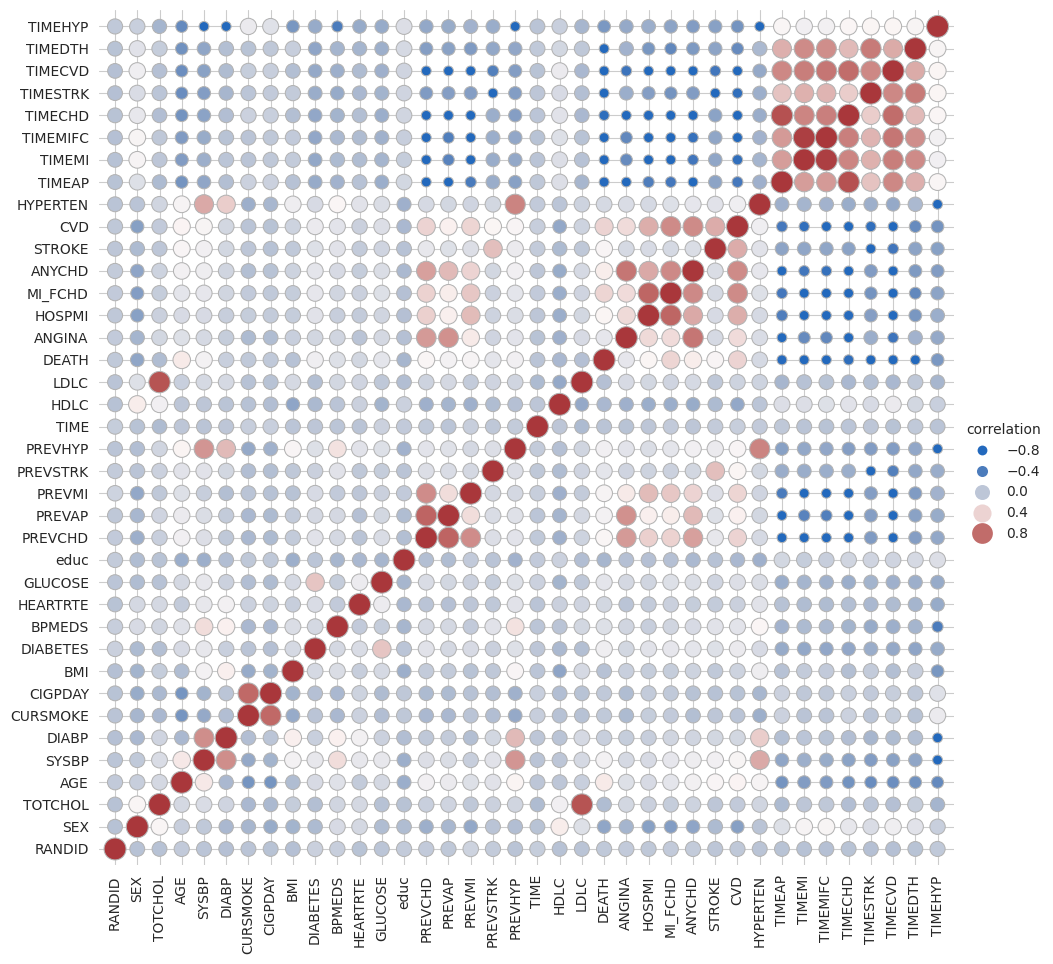

In [15]:
corr_plot(data.dropna())

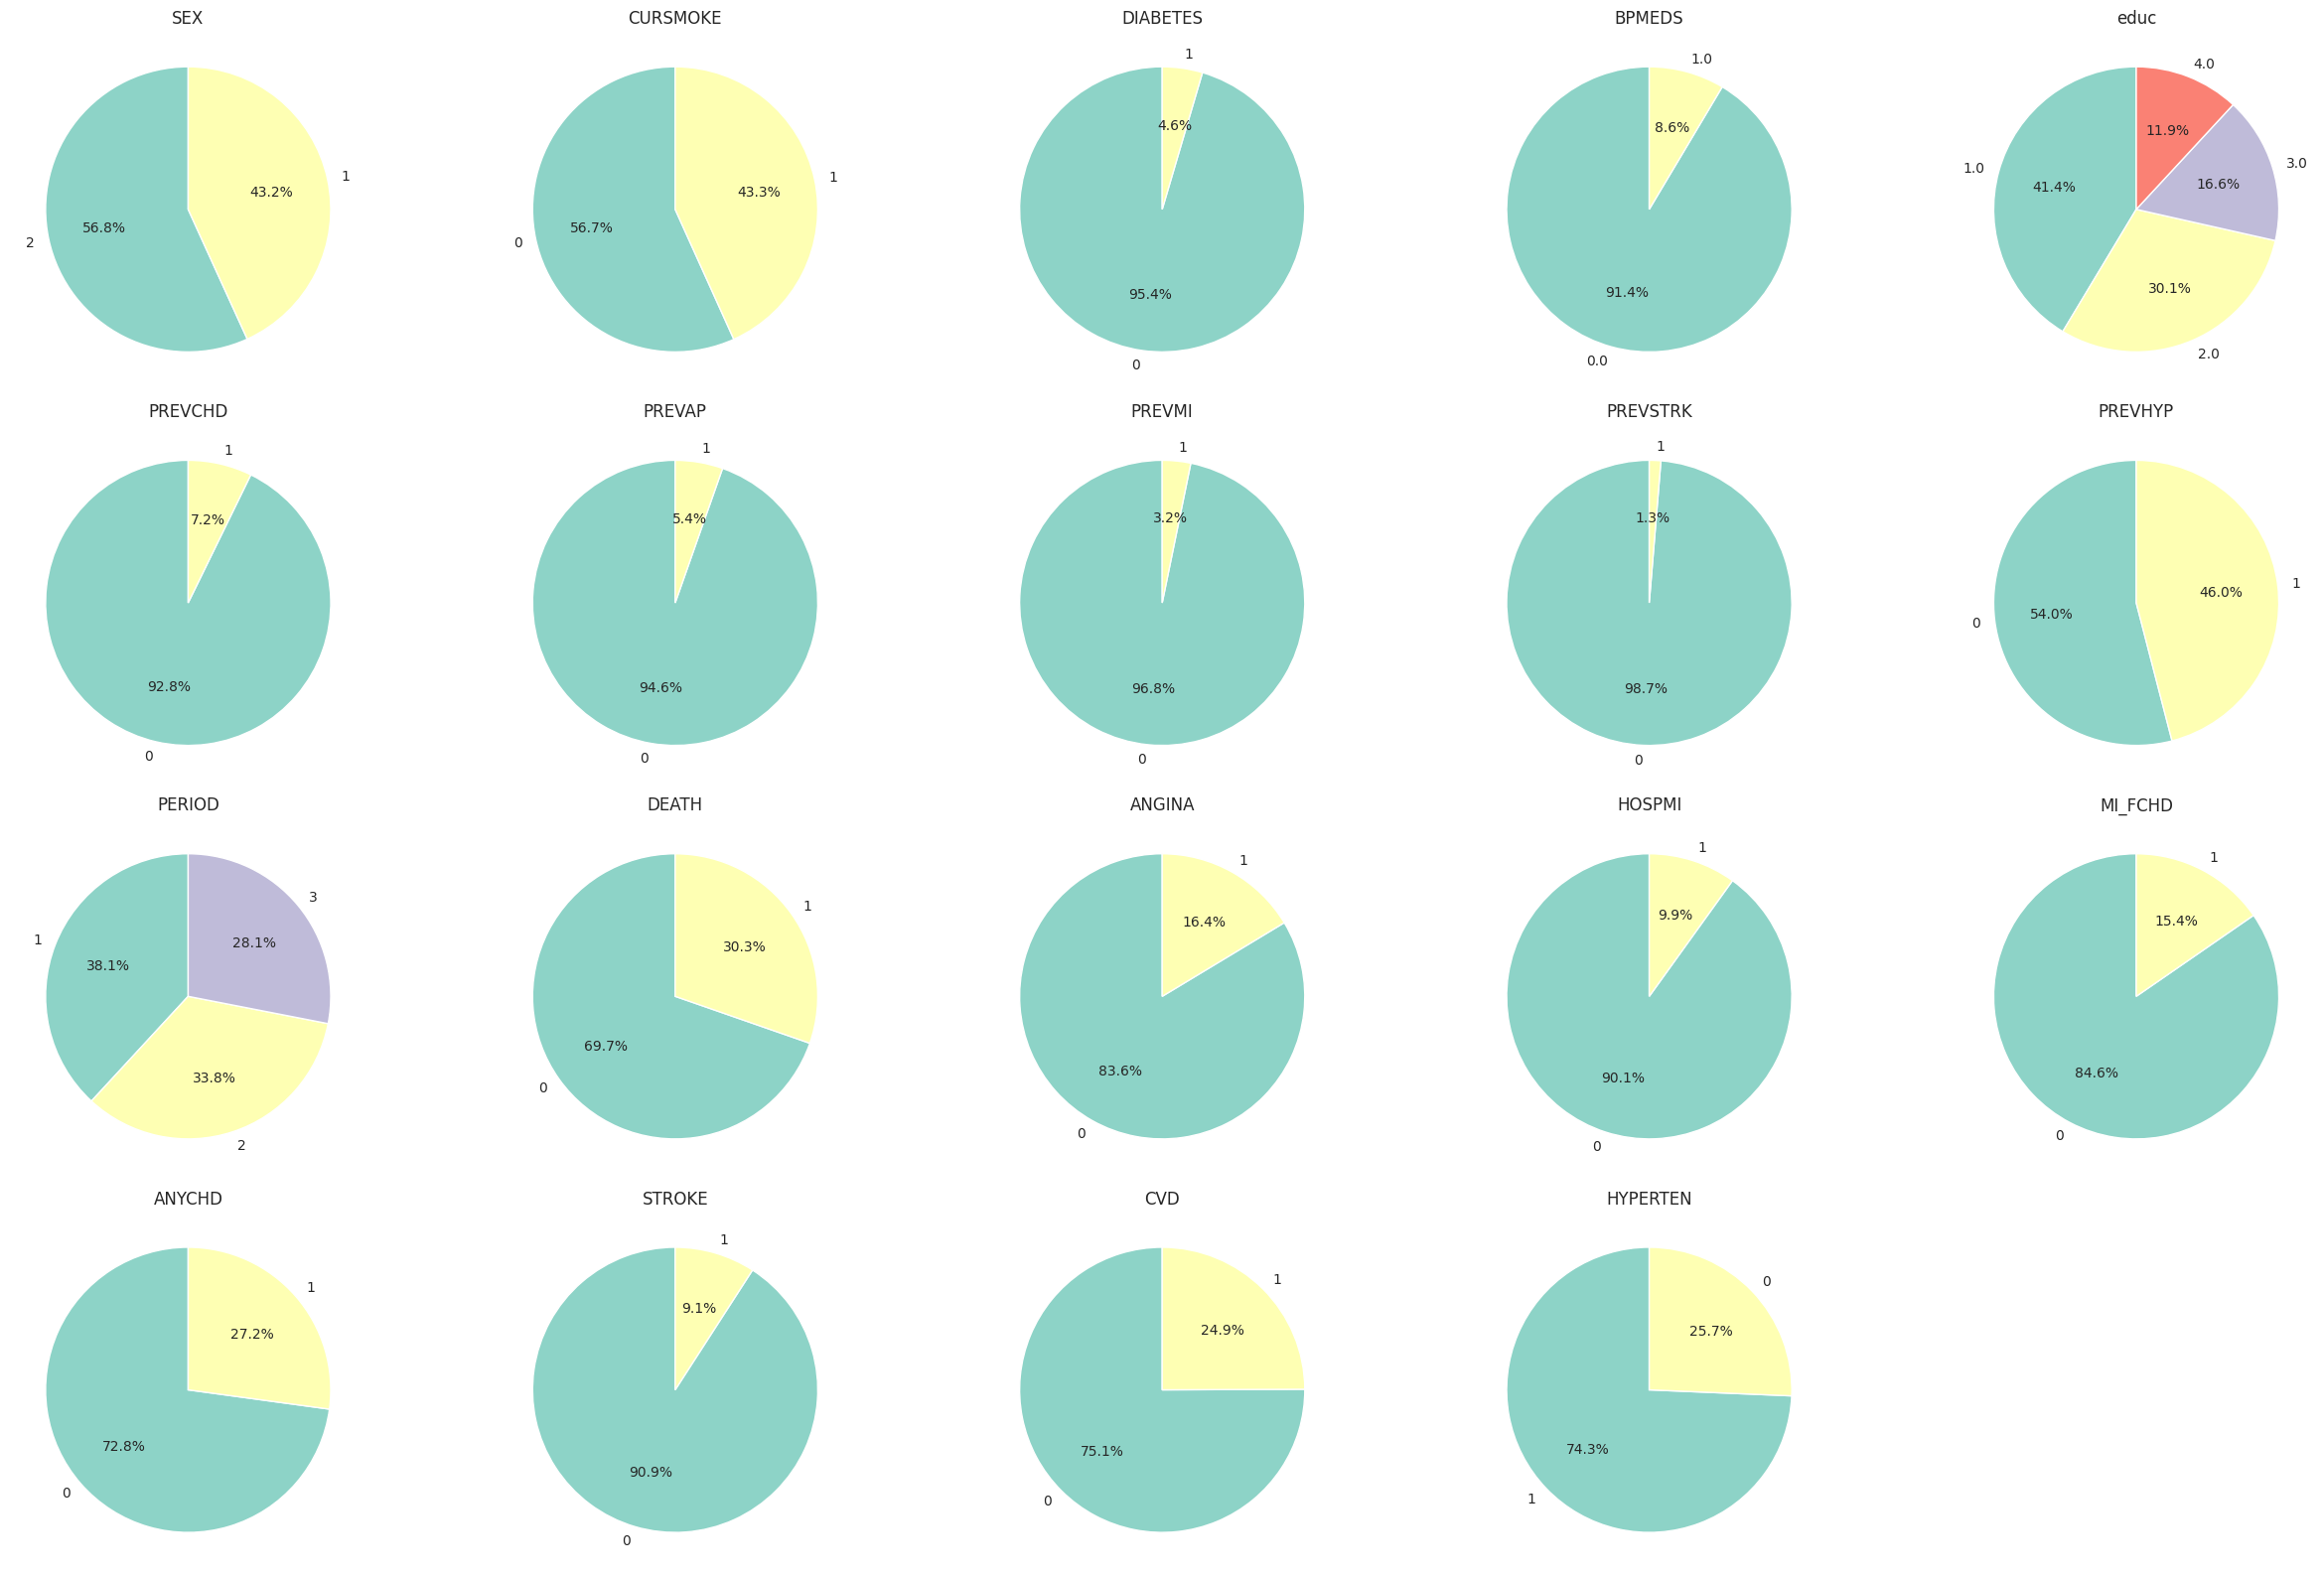

In [16]:
binary_cols = [col for col in data.columns if
               data[col].dropna().isin([0, 1, 2, 3, 4]).all() and len(data[col].dropna().unique()) <= 4]

num_binary = len(binary_cols)
cols = int(np.ceil(np.sqrt(num_binary)))
rows = int(np.ceil(num_binary / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten() if num_binary > 1 else [axes]

for i, col in enumerate(binary_cols):
    value_counts = data[col].value_counts()
    axes[i].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{col}')

for j in range(num_binary, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [17]:
if DoLongCells: distplots(numeric_df.drop(binary_cols, axis=1))

In [18]:
if DoLongCells: sns.pairplot(data, hue='CVD')

### Train-Test Split

In [19]:
CategoryColumn = 'CVD'

X = data.drop(columns=[CategoryColumn])  # all columns except 'stroke'
y = data[CategoryColumn]  # the target column

# Split into train (80%) and test (20%)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=3003)
print("Train predictors shape:", X_train.shape)
print("Test predictors shape:", X_test.shape)
print("Train target shape:", Y_train.shape)
print("Test target shape:", Y_test.shape)

Train predictors shape: (9301, 38)
Test predictors shape: (2326, 38)
Train target shape: (9301,)
Test target shape: (2326,)


### Detecting outliers in the numerical columns

In [20]:
numerical_cols = data.select_dtypes(include=np.number).columns
outlier_indices = {}

for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    indices = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
    if len(indices) > 0:
            outlier_indices[col] = indices.tolist()
            if Prod: print(f'{len(indices)} outliers found in {col} column')
    else:
        pass
        if Prod: print(f"No outlier data found for column {col}")

outlier_values = []
outliers_count = 0
for col, rows in outlier_indices.items():
    outlier_values.append([col, len(rows), (len(rows)*100 / len(data[col]))])
    outliers_count = outliers_count + 1 if len(rows) > 0 else outliers_count

if outliers_count > 0:
    data_outliers = pd.DataFrame(outlier_values)
    data_outliers.columns = ['Variable', 'Outliers', 'Percentage Outliers']
    s = data_outliers.sort_values(by=['Percentage Outliers'], ascending=False).style.bar(subset=['Percentage Outliers'], color='#d65f5f')
    display(s)
else:
    print('No outlier values found in the dataset.')

,Variable,Outliers,Percentage Outliers
19,CVD,2899,24.933345
26,TIMEDTH,1933,16.625097
15,ANGINA,1902,16.358476
17,MI_FCHD,1788,15.377999
24,TIMESTRK,1489,12.806399
21,TIMEMI,1484,12.763396
22,TIMEMIFC,1347,11.585104
16,HOSPMI,1154,9.925174
18,STROKE,1061,9.125312
6,BPMEDS,944,8.119033


### Data imputation

#### Missing check

In [21]:
missing  = 0
misVariables = []
for variable in ["X_train", "X_test"]:
    print(f"Checking {str(variable)}")
    if variable == "X_train": variable = X_train
    else: variable = X_test

    CheckNull = variable.isnull().sum()

    if "numpy.int64" in str(type(CheckNull)): print('Dataset is complete with no blanks.')

    else:
        for var in range(0, len(CheckNull)):
            misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])
            missing = missing + 1

        if missing == 0:
            print('Dataset is complete with no blanks.')
        else:
            data_misVariables = pd.DataFrame.from_records(misVariables)
            data_misVariables.columns = ['Variable', 'Missing', 'Percentage missing']
            s = data_misVariables.sort_values(by=['Percentage missing'], ascending=False).style.bar(subset=['Percentage missing'], color='#d65f5f')
            display(s)

Checking X_train


/tmp/ipykernel_9753/3413476200.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])


,Variable,Missing,Percentage missing
22,LDLC,6888,59.241000
21,HDLC,6887,59.233000
12,GLUCOSE,1181,10.157000
10,BPMEDS,472,4.060000
2,TOTCHOL,331,2.847000
13,educ,234,2.013000
7,CIGPDAY,67,0.576000
8,BMI,42,0.361000
11,HEARTRTE,6,0.052000
5,DIABP,0,0.000000


Checking X_test


/tmp/ipykernel_9753/3413476200.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])


,Variable,Missing,Percentage missing
22,LDLC,6888,59.241000
21,HDLC,6887,59.233000
59,HDLC,1713,14.733000
60,LDLC,1713,14.733000
12,GLUCOSE,1181,10.157000
10,BPMEDS,472,4.060000
2,TOTCHOL,331,2.847000
50,GLUCOSE,259,2.228000
13,educ,234,2.013000
48,BPMEDS,121,1.041000


Imputation will be done by:
- Dropping columns with more than 50% missing data
- Using KNN Classifier or Regressor (based on data category) on columns between 2% and 50%
- Using measures of central tendency on columns where <2% of data is missing

#### Imputation on X_Train and X_Test

In [22]:
# 1. Drop columns with more than 50% missing data (> 50% missing in Train)
threshold = 0.50
train_missing_pct = X_train.isnull().mean()
cols_to_drop = train_missing_pct[train_missing_pct > threshold].index.tolist()

print(f"Dropping columns with > {threshold:.0%} missing in Train: {cols_to_drop}")
X_train_imp = X_train.drop(columns=cols_to_drop)
X_test_imp = X_test.drop(columns=cols_to_drop)

# 2. Simple Imputation
range_thresh = (0.02, 0.50)

simple_impute_cols = train_missing_pct[(train_missing_pct > 0) & (train_missing_pct < range_thresh[0])].index.tolist()
# Filter out dropped columns just in case
simple_impute_cols = [c for c in simple_impute_cols if c not in cols_to_drop]

knn_impute_cols = train_missing_pct[
    (train_missing_pct >= range_thresh[0]) & (train_missing_pct <= range_thresh[1])].index.tolist()
knn_impute_cols = [c for c in knn_impute_cols if c not in cols_to_drop]

print(f"Simple Imputation Cols (<2%): {simple_impute_cols}")
print(f"KNN Imputation Cols (2-50%): {knn_impute_cols}")

# Apply Simple Imputation (Learn from Train, Apply to Train & Test)
for col in simple_impute_cols:
    if pd.api.types.is_numeric_dtype(X_train_imp[col]):
        fill_val = X_train_imp[col].median()
    else:
        fill_val = X_train_imp[col].mode()[0]

    X_train_imp[col] = X_train_imp[col].fillna(fill_val)
    X_test_imp[col] = X_test_imp[col].fillna(fill_val)

# Apply KNN Imputation
# We need to handle encoding for KNN to work on categorical features
categorical_cols = [col for col in X_train_imp.columns if X_train_imp[col].dtype == 'object']
numerical_cols = [col for col in X_train_imp.columns if X_train_imp[col].dtype != 'object']

# Encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
if categorical_cols:
    # Fit on Train
    encoder.fit(X_train_imp[categorical_cols])

    # Transform Train
    encoded_train = pd.DataFrame(encoder.transform(X_train_imp[categorical_cols]),
                                 columns=encoder.get_feature_names_out(categorical_cols),
                                 index=X_train_imp.index)
    X_train_encoded = X_train_imp.drop(columns=categorical_cols).join(encoded_train)

    # Transform Test
    encoded_test = pd.DataFrame(encoder.transform(X_test_imp[categorical_cols]),
                                columns=encoder.get_feature_names_out(categorical_cols),
                                index=X_test_imp.index)
    X_test_encoded = X_test_imp.drop(columns=categorical_cols).join(encoded_test)
else:
    X_train_encoded = X_train_imp.copy()
    X_test_encoded = X_test_imp.copy()

# Fill temporary NaNs in features with Train Mean for the KNN regressors/classifiers
train_means = X_train_encoded.mean()
X_train_filled_features = X_train_encoded.fillna(train_means)
# Note: For X_test prediction, we should use X_test features filled with TRAIN means (or test means? Standard is Train means to avoid leakage)
X_test_filled_features = X_test_encoded.fillna(train_means)

n_neighbors = 5

for col in knn_impute_cols:
    is_categorical = col in categorical_cols

    if col in categorical_cols:
        col_encoded_names = [c for c in X_train_encoded.columns if c.startswith(f"{col}_") or c == col]
        cols_to_exclude = col_encoded_names
    else:
        cols_to_exclude = [col]

    feature_cols = [c for c in X_train_encoded.columns if c not in cols_to_exclude]

    train_indices = X_train_imp[col].notnull()
    X_train_features = X_train_filled_features.loc[train_indices, feature_cols]
    y_train_target = X_train_imp.loc[train_indices, col]

    predict_train_indices = X_train_imp[col].isnull()
    X_predict_train = X_train_filled_features.loc[predict_train_indices, feature_cols]

    predict_test_indices = X_test_imp[col].isnull()
    X_predict_test = X_test_filled_features.loc[predict_test_indices, feature_cols]

    if len(X_predict_train) == 0 and len(X_predict_test) == 0:
        continue

    if is_categorical or X_train_imp[col].nunique() <= 2:
        model = KNeighborsClassifier(n_neighbors=n_neighbors)
    else:
        model = KNeighborsRegressor(n_neighbors=n_neighbors)

    model.fit(X_train_features, y_train_target)

    if len(X_predict_train) > 0:
        X_train_imp.loc[predict_train_indices, col] = model.predict(X_predict_train)

    if len(X_predict_test) > 0:
        X_test_imp.loc[predict_test_indices, col] = model.predict(X_predict_test)

    print(f"KNN Imputed '{col}': {len(X_predict_train)} in Train, {len(X_predict_test)} in Test")

Dropping columns with > 50% missing in Train: ['HDLC', 'LDLC']
Simple Imputation Cols (<2%): ['CIGPDAY', 'BMI', 'HEARTRTE']
KNN Imputation Cols (2-50%): ['TOTCHOL', 'BPMEDS', 'GLUCOSE', 'educ']
KNN Imputed 'TOTCHOL': 331 in Train, 78 in Test
KNN Imputed 'BPMEDS': 472 in Train, 121 in Test
KNN Imputed 'GLUCOSE': 1181 in Train, 259 in Test
KNN Imputed 'educ': 234 in Train, 61 in Test


#### Post-imputation missing check

In [23]:
missing  = 0
misVariables = []
for variable in ["X_train_imp", "X_test_imp"]:
    print(f"Checking {str(variable)}")
    if variable == "X_train_imp": variable = X_train_imp
    else: variable = X_test_imp

    CheckNull = variable.isnull().sum()

    if "numpy.int64" in str(type(CheckNull)): print('Dataset is complete with no blanks.')

    else:
        for var in range(0, len(CheckNull)):
            misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])
            missing = missing + 1

        if missing == 0:
            print('Dataset is complete with no blanks.')
        else:
            data_misVariables = pd.DataFrame.from_records(misVariables)
            data_misVariables.columns = ['Variable', 'Missing', 'Percentage missing']
            s = data_misVariables.sort_values(by=['Percentage missing'], ascending=False).style.bar(subset=['Percentage missing'], color='#d65f5f')
            display(s)

Checking X_train_imp


/tmp/ipykernel_9753/254448156.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])
/home/kuba/rocm_master/lib/python3.12/site-packages/pandas/io/formats/style.py:4040: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,Variable,Missing,Percentage missing
0,RANDID,0,0.000000
1,SEX,0,0.000000
2,TOTCHOL,0,0.000000
3,AGE,0,0.000000
4,SYSBP,0,0.000000
5,DIABP,0,0.000000
6,CURSMOKE,0,0.000000
7,CIGPDAY,0,0.000000
8,BMI,0,0.000000
9,DIABETES,0,0.000000


Checking X_test_imp


/tmp/ipykernel_9753/254448156.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  misVariables.append([data.columns[var], CheckNull[var], round(CheckNull[var]*100/len(data),3)])
/home/kuba/rocm_master/lib/python3.12/site-packages/pandas/io/formats/style.py:4040: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,Variable,Missing,Percentage missing
0,RANDID,0,0.000000
1,SEX,0,0.000000
2,TOTCHOL,0,0.000000
3,AGE,0,0.000000
4,SYSBP,0,0.000000
5,DIABP,0,0.000000
6,CURSMOKE,0,0.000000
7,CIGPDAY,0,0.000000
8,BMI,0,0.000000
9,DIABETES,0,0.000000


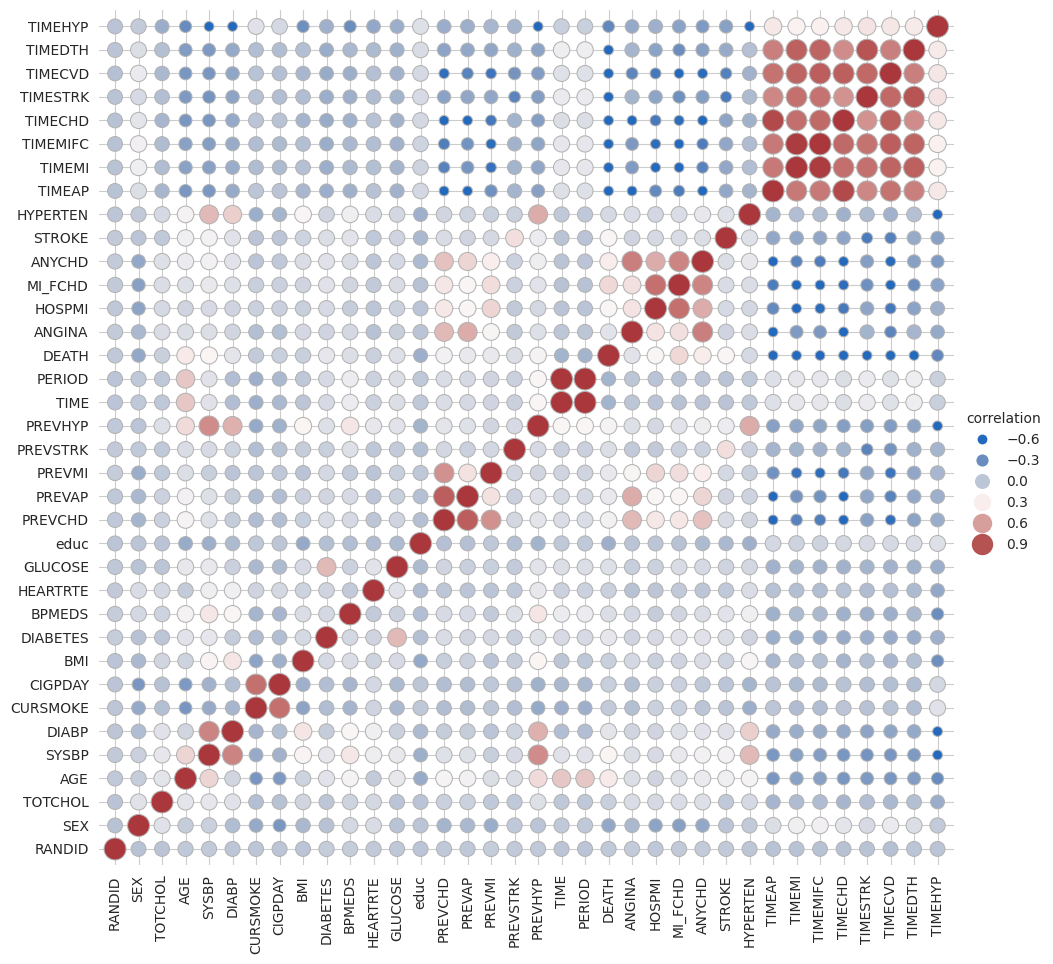

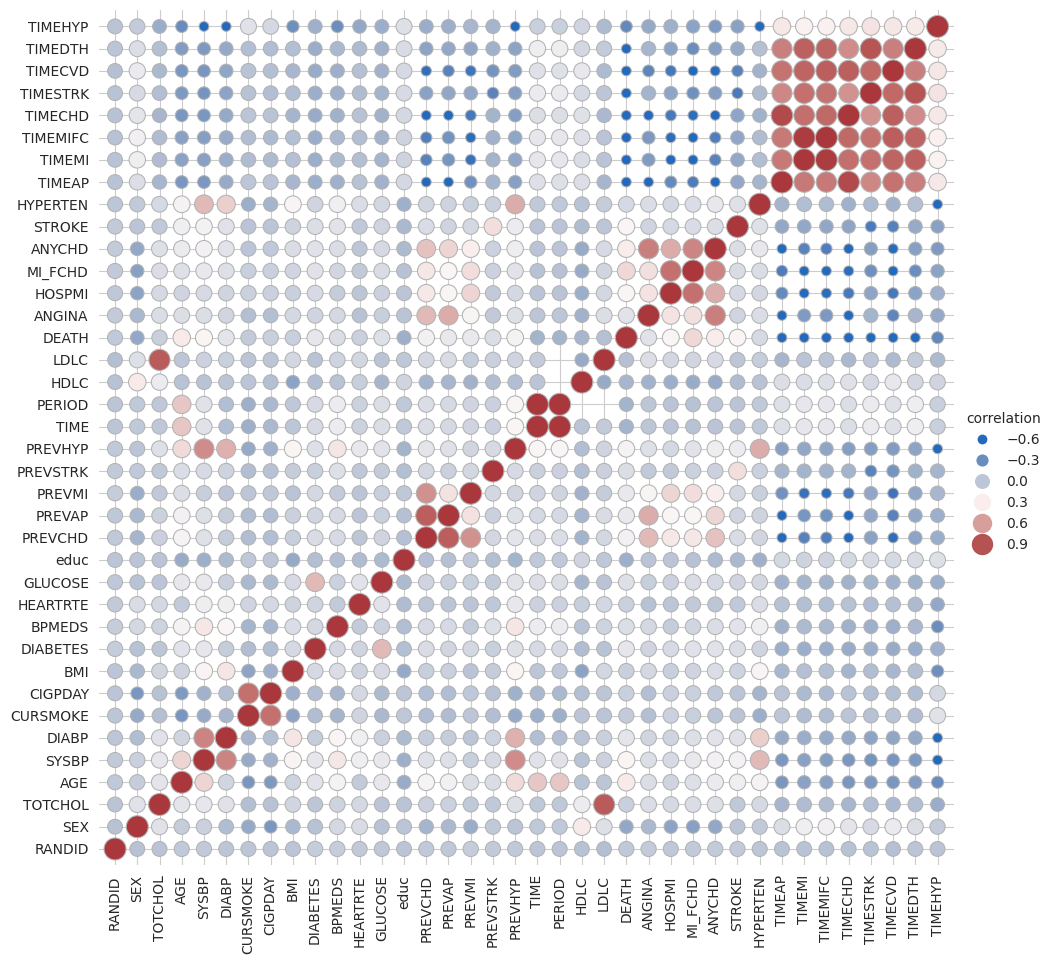

In [24]:
corr_plot(X_train.drop(columns=['HDLC','LDLC']))
corr_plot(X_train)

Checking         RANDID  SEX  TOTCHOL  AGE  SYSBP  DIABP  CURSMOKE  CIGPDAY    BMI  \
9733   8423619    2    265.0   55  154.0   87.0         1      9.0  20.92   
972     825139    2    239.0   60  129.0   74.0         0      0.0  26.69   
5083   4360095    2    243.0   56  123.0   78.0         1     30.0  23.18   
10266  8891825    2    206.0   72  165.0   94.0         0      0.0  22.37   
1079    923590    1    258.0   53  112.5   69.0         0      0.0  25.27   
...        ...  ...      ...  ...    ...    ...       ...      ...    ...   
11527  9911212    2    236.0   42  160.5  100.0         0      0.0  27.01   
1334   1098348    1    340.0   56  134.0   89.5         1     20.0  21.91   
4888   4205603    2    176.0   45  108.0   66.0         1      1.0  20.98   
1380   1137973    2    235.0   53  132.0   84.0         0      0.0  30.10   
11070  9483124    2    197.0   68  140.0   80.0         0      0.0  28.30   

       DIABETES  ...  STROKE  HYPERTEN  TIMEAP  TIMEMI  TIMEMIFC  

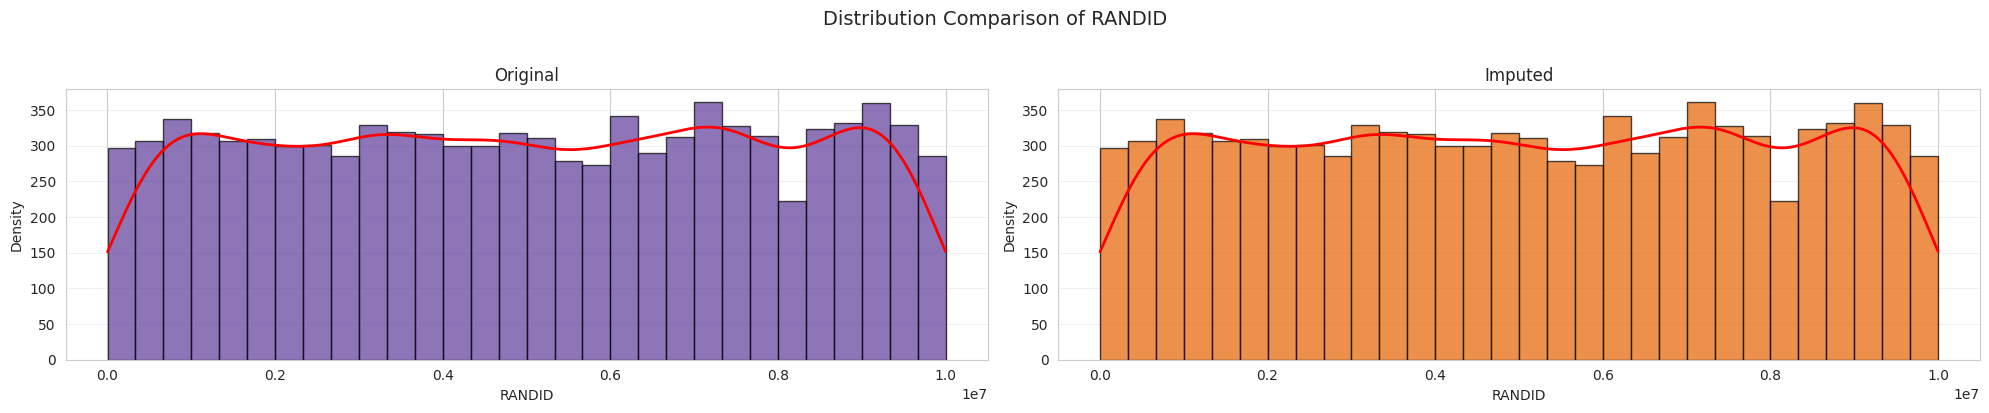

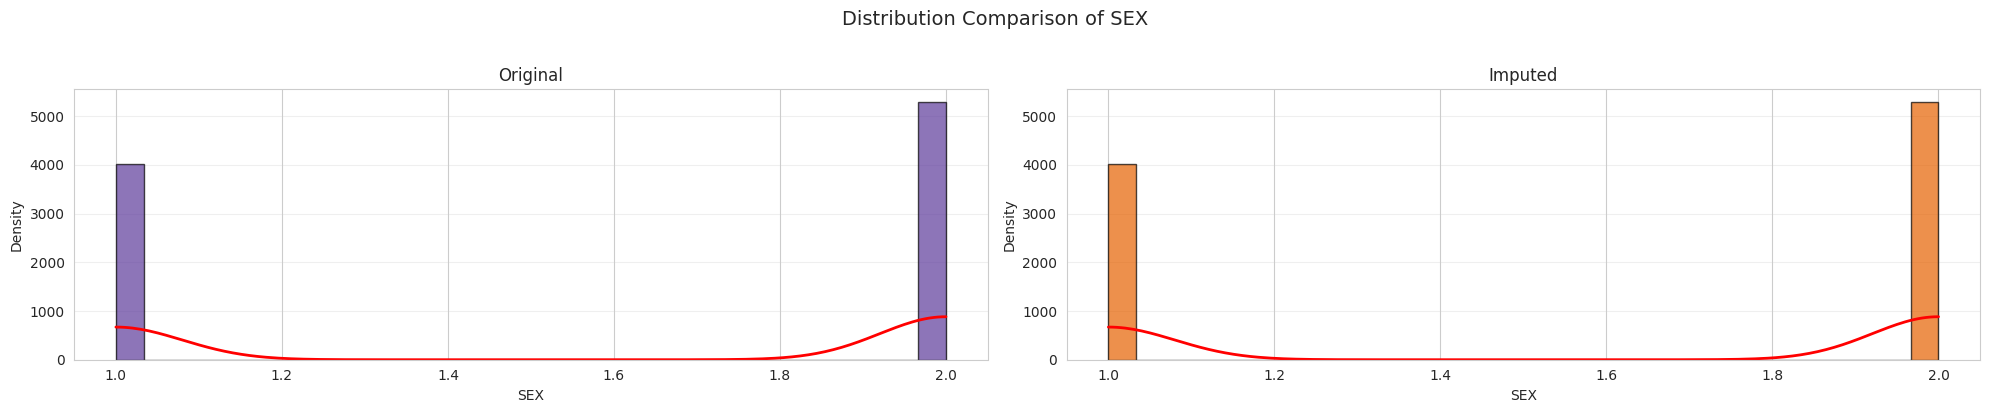

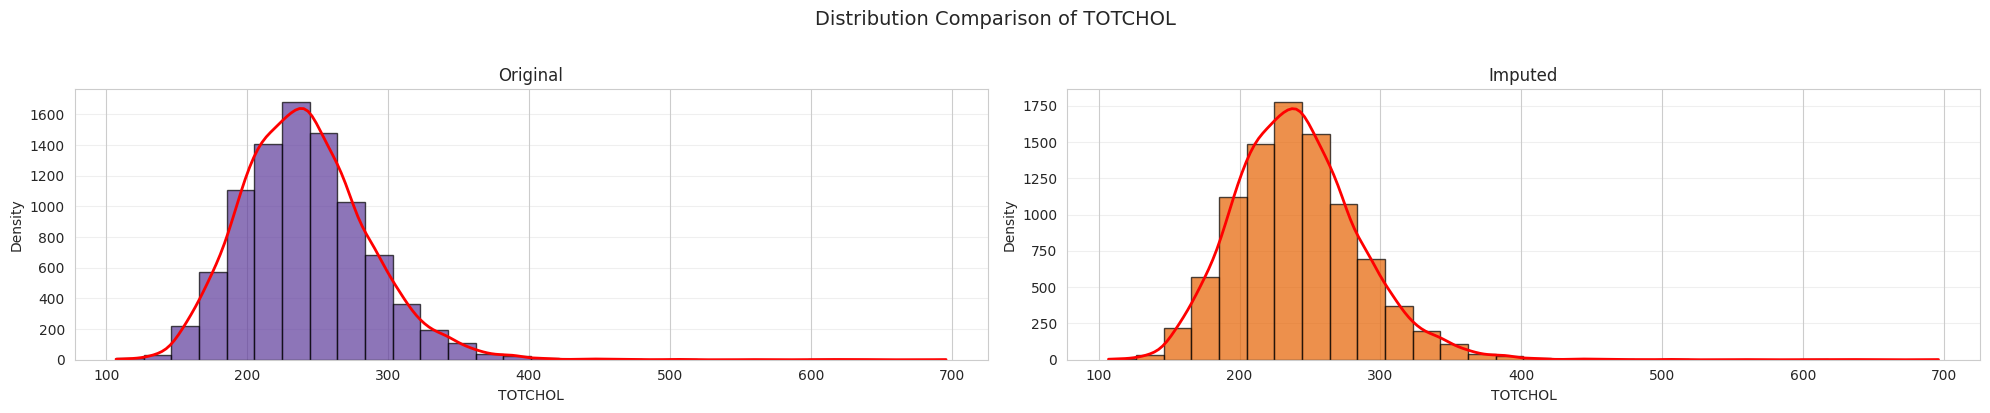

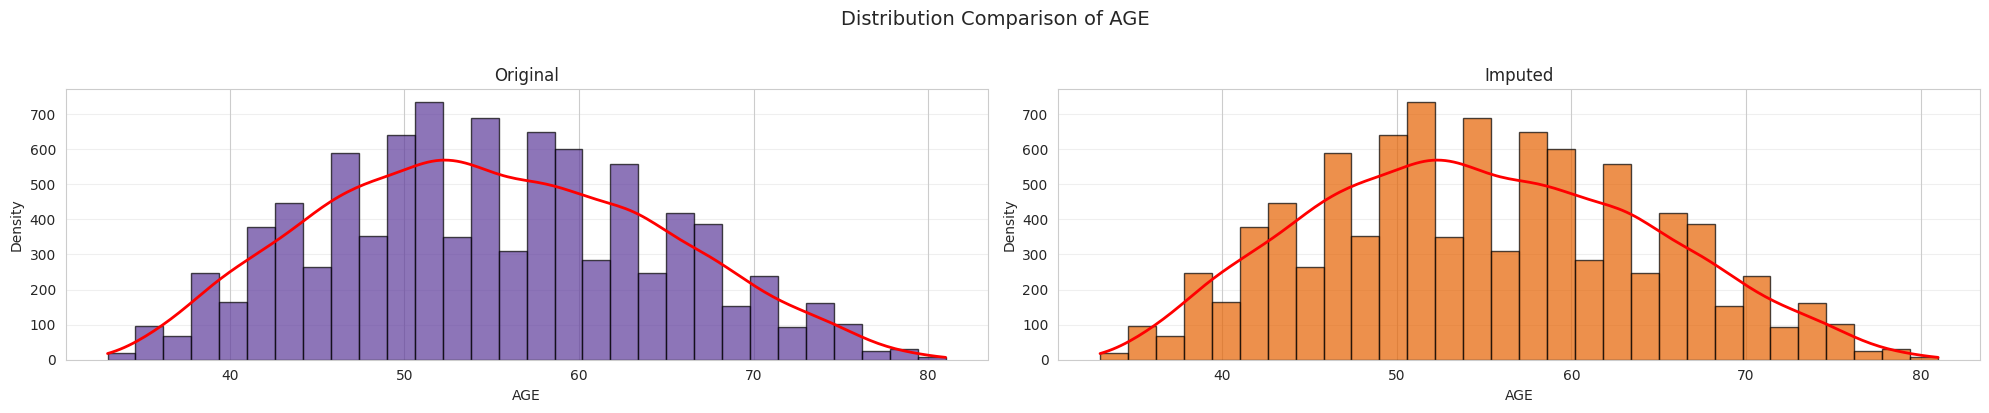

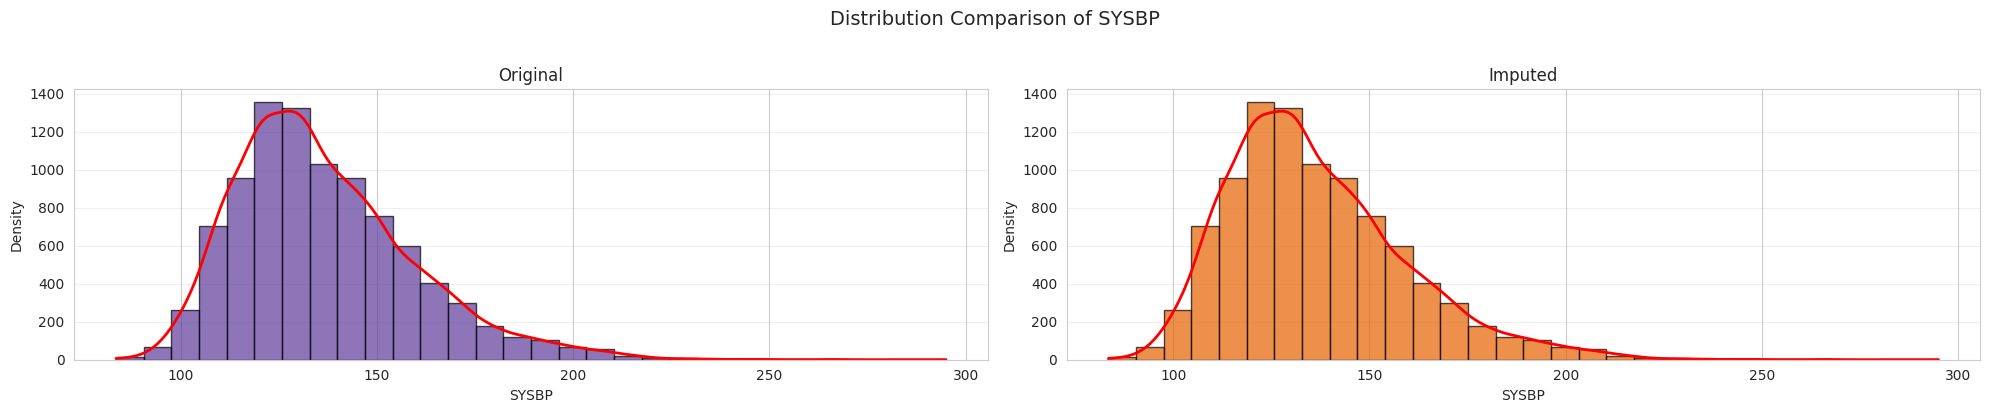

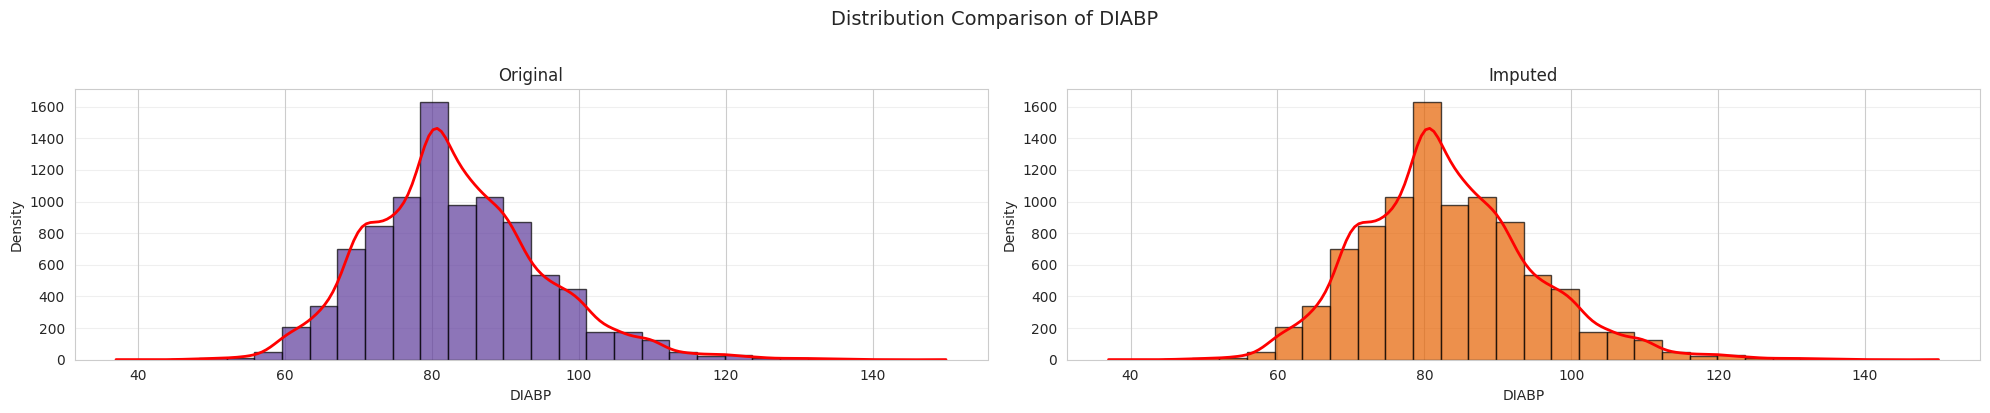

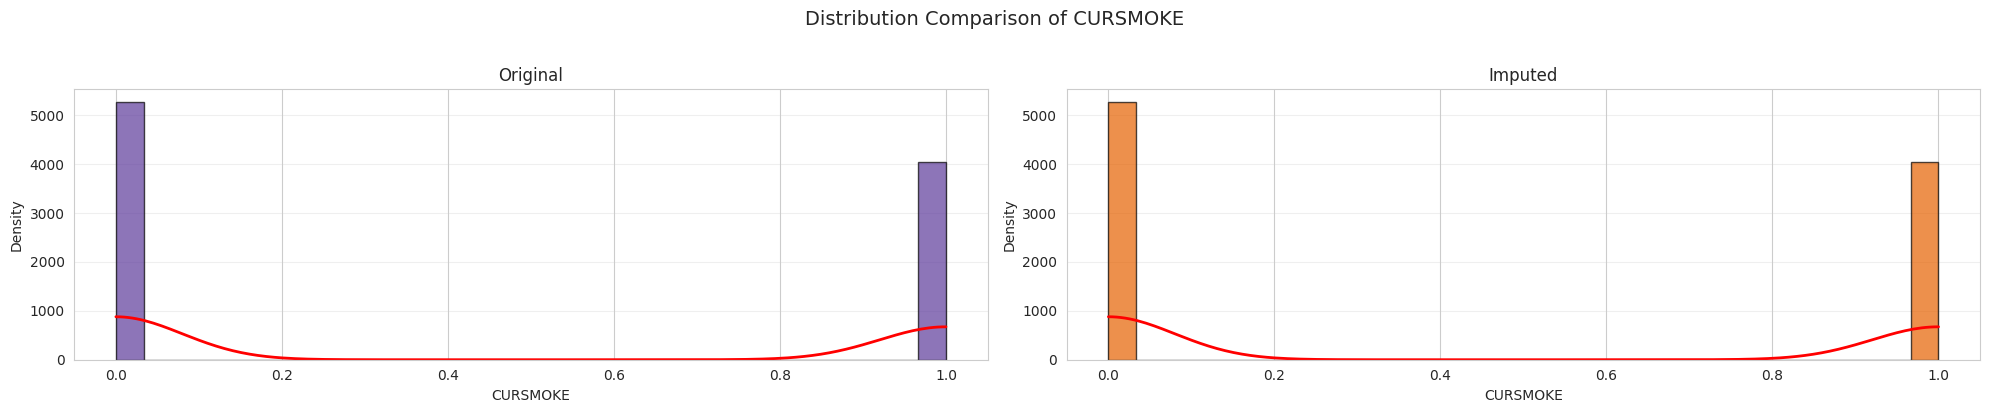

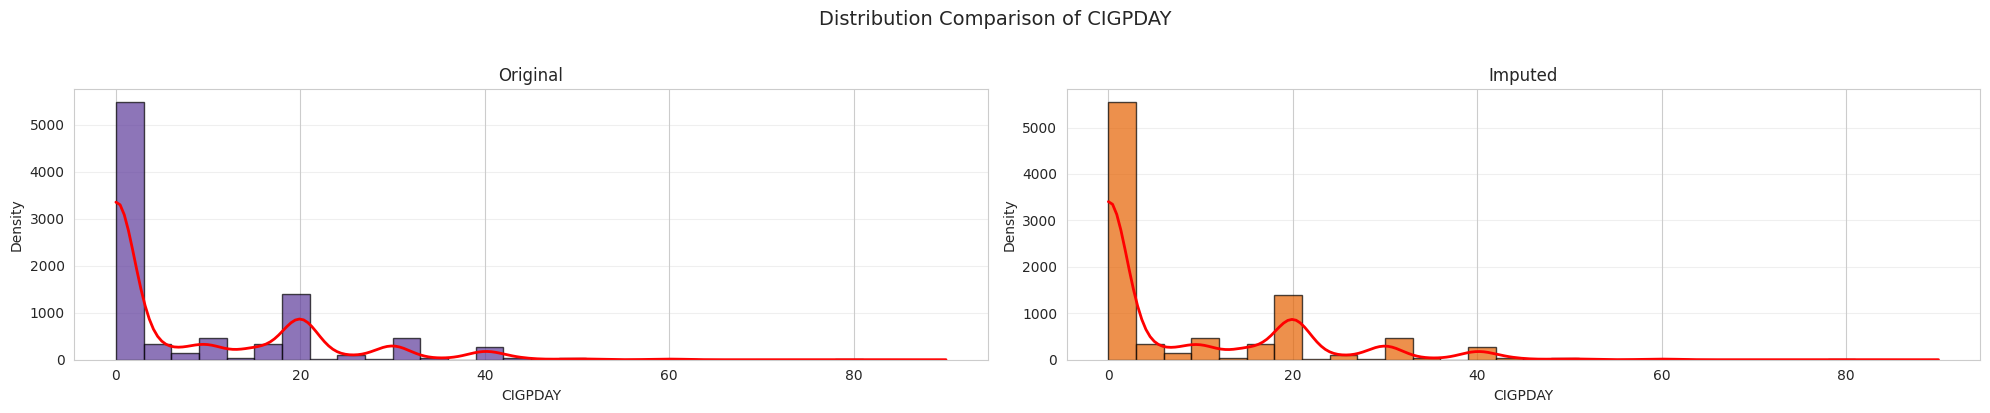

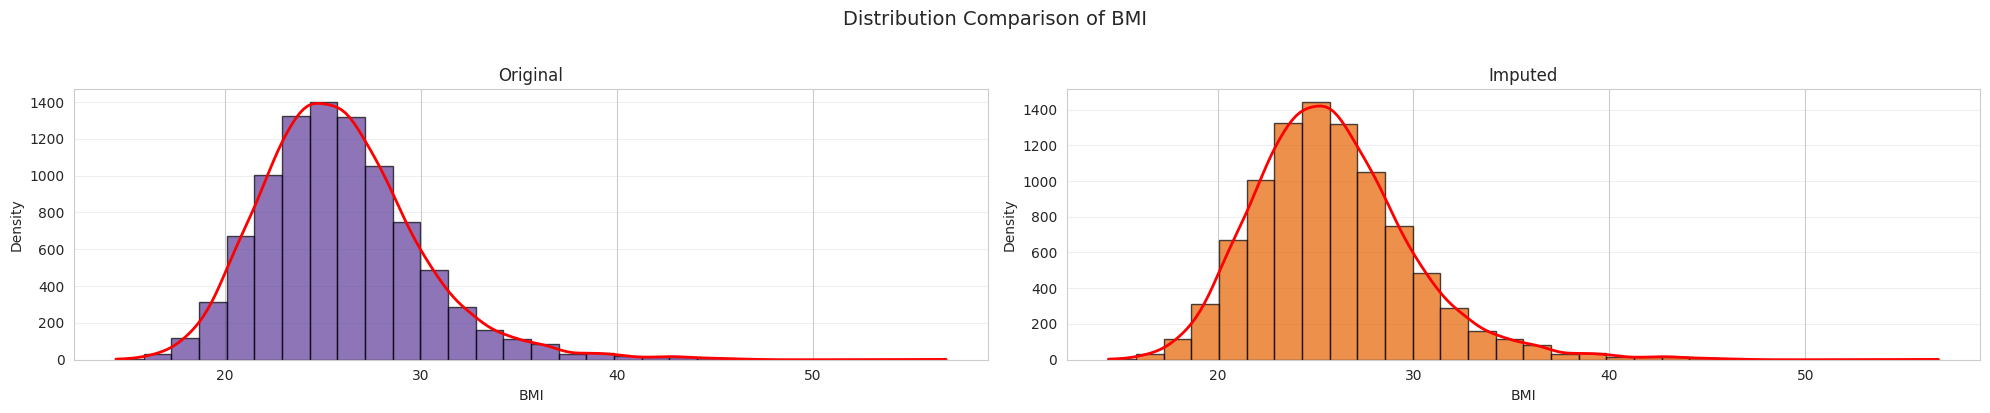

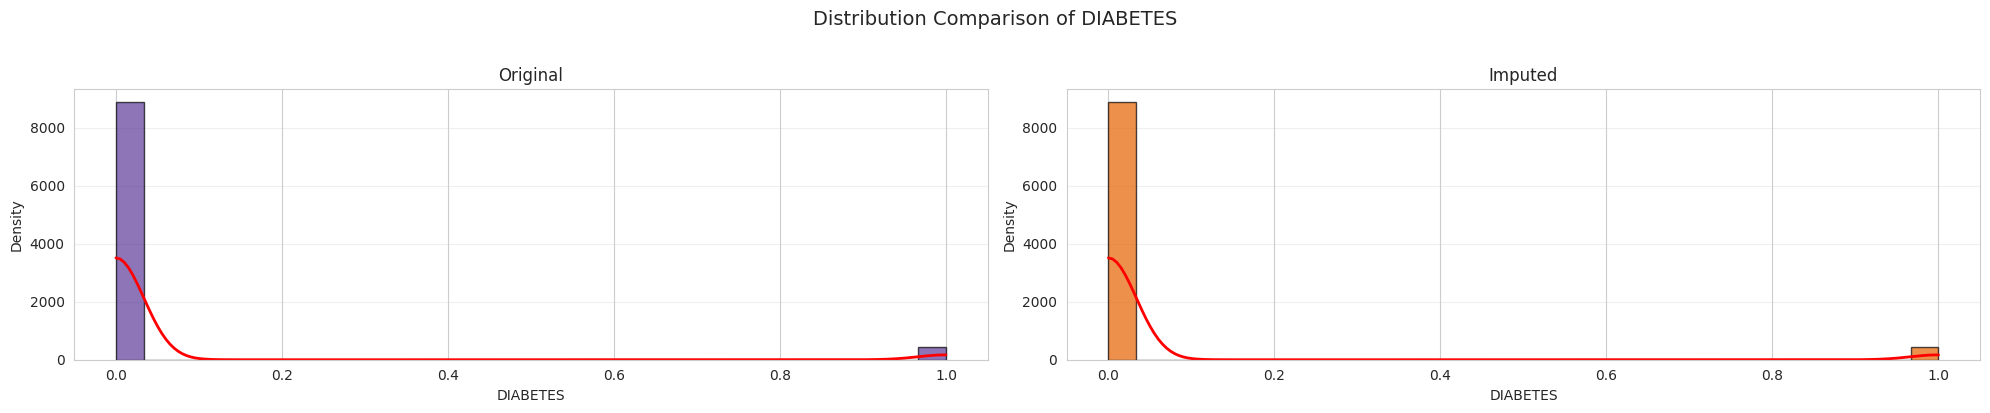

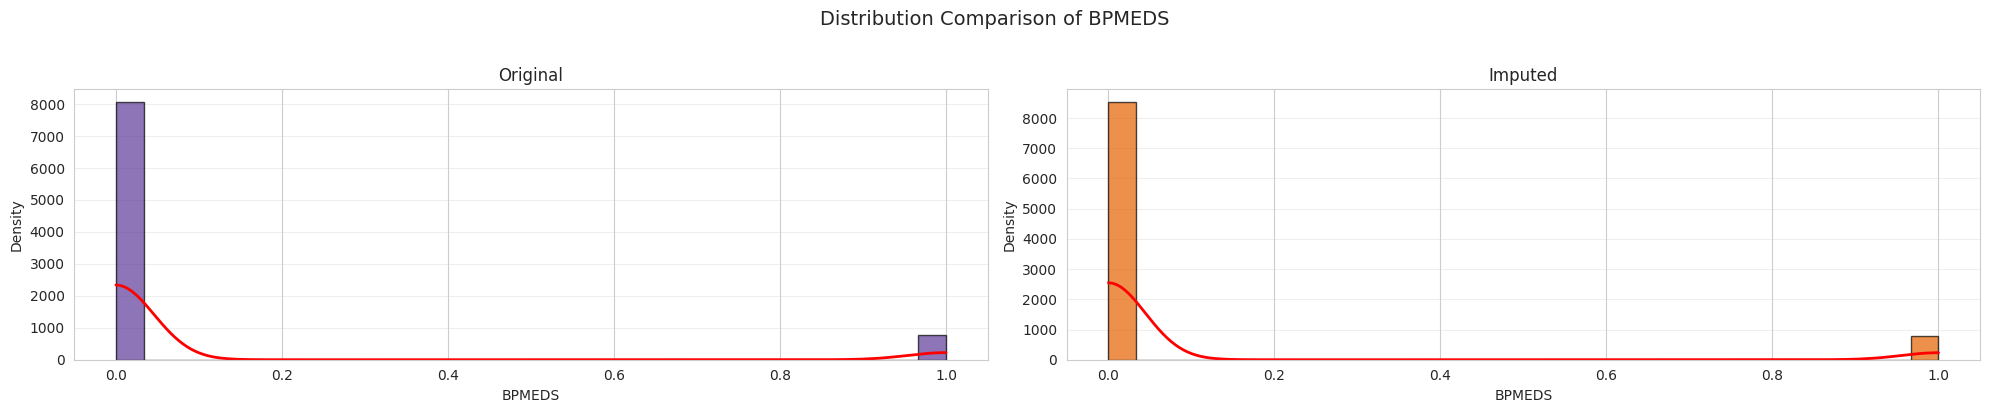

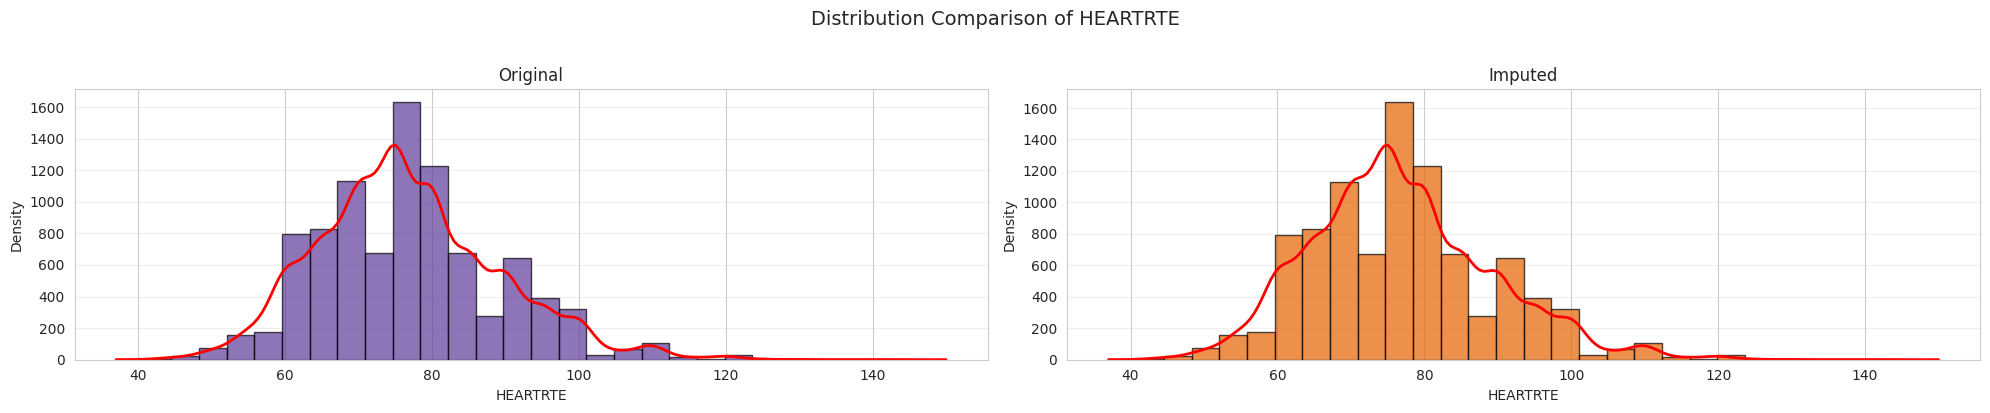

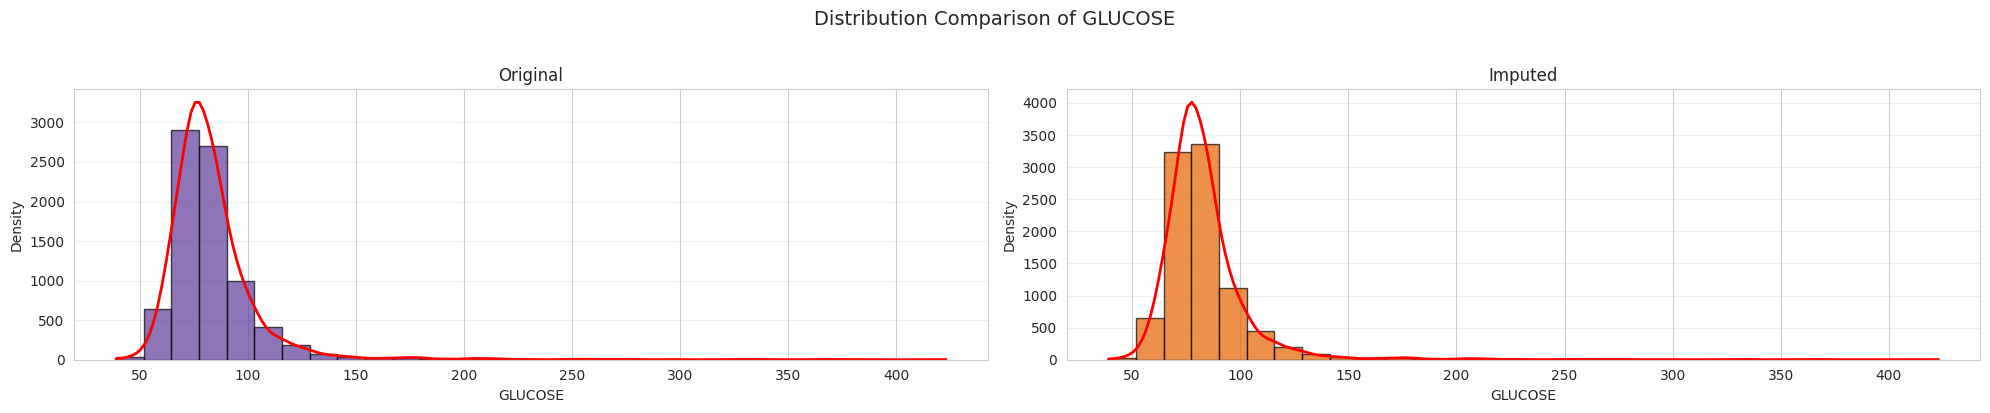

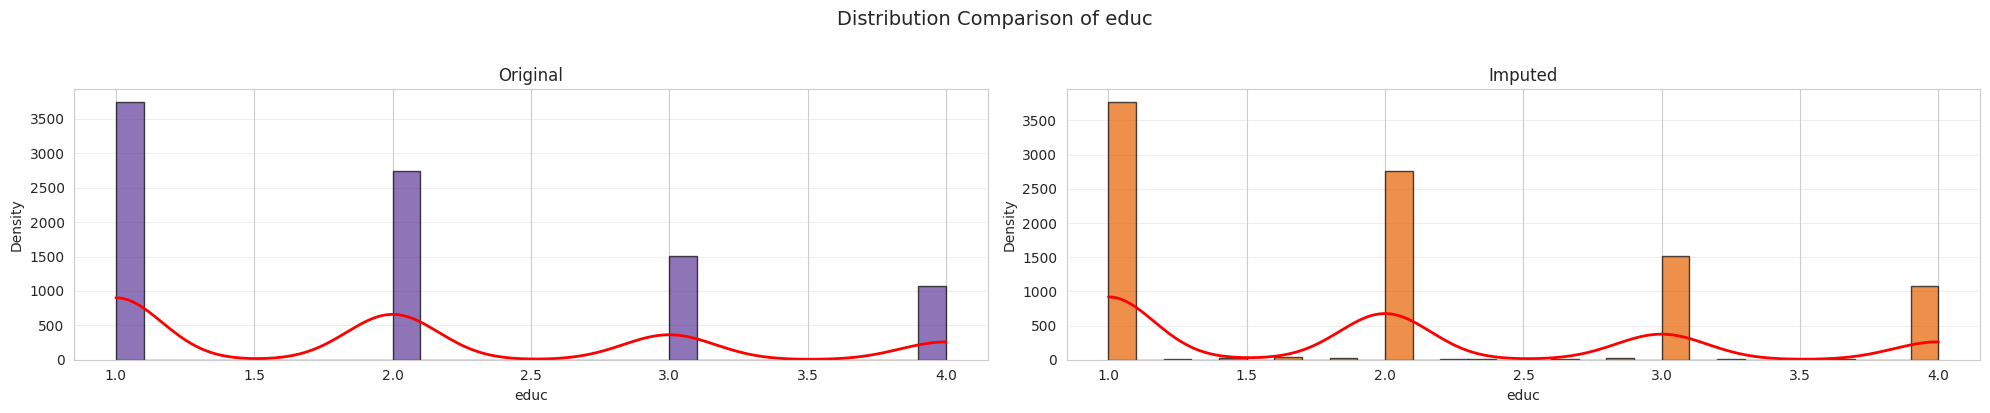

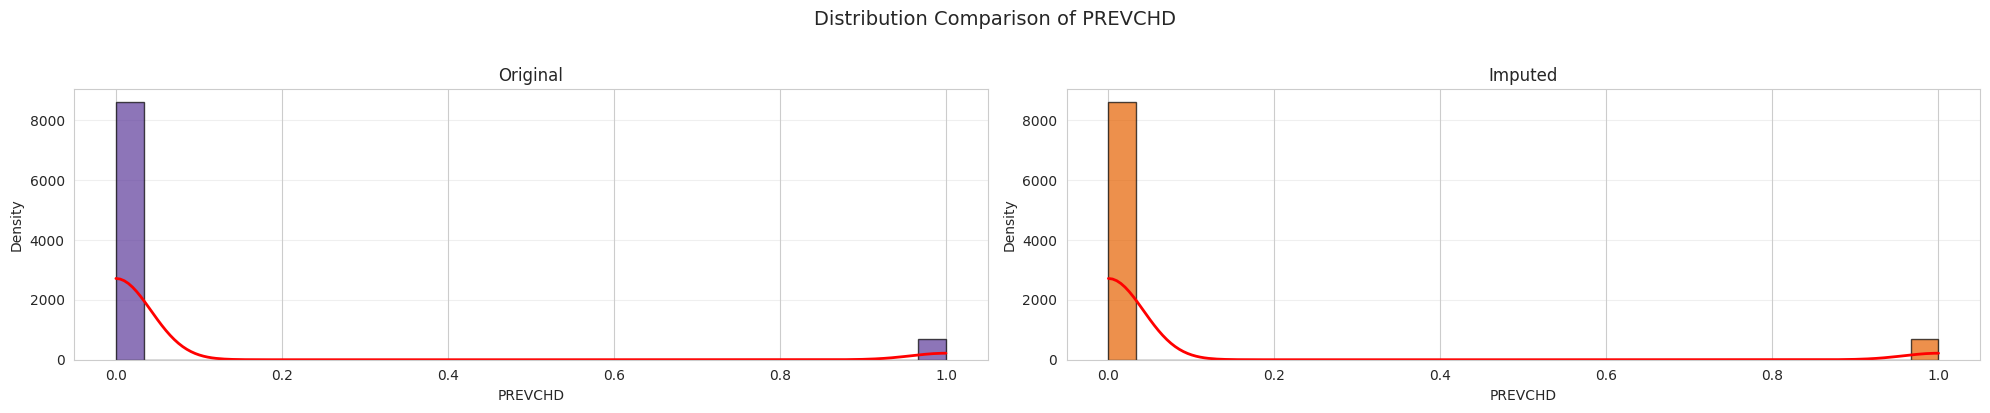

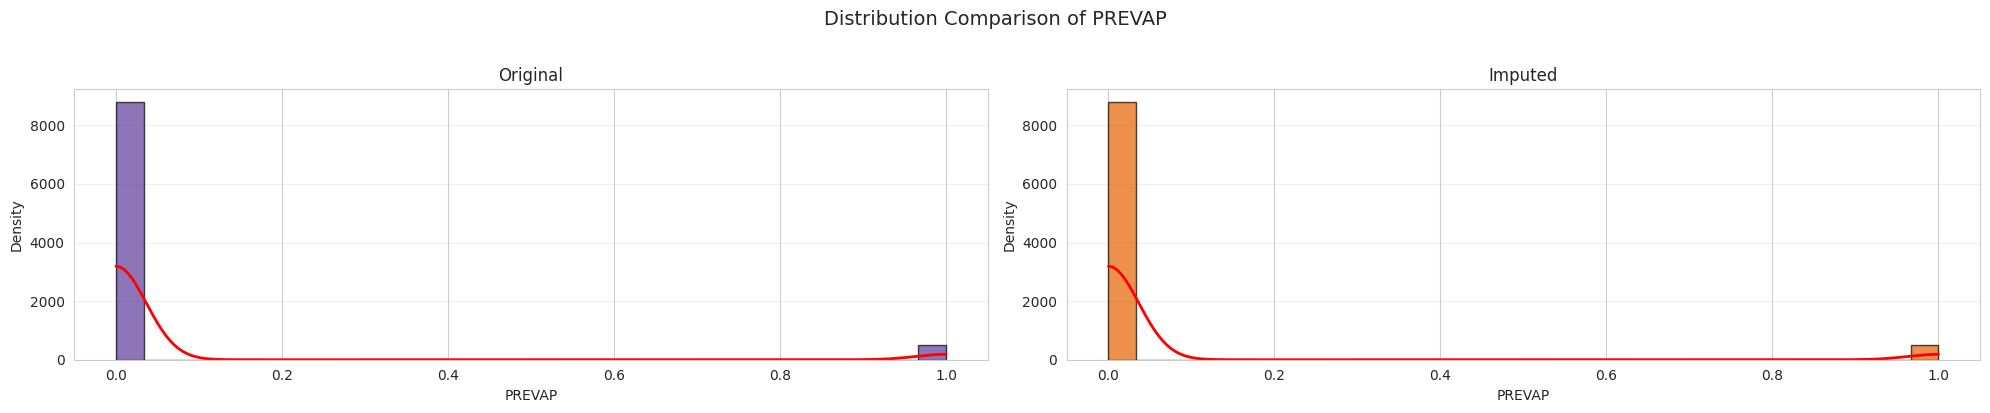

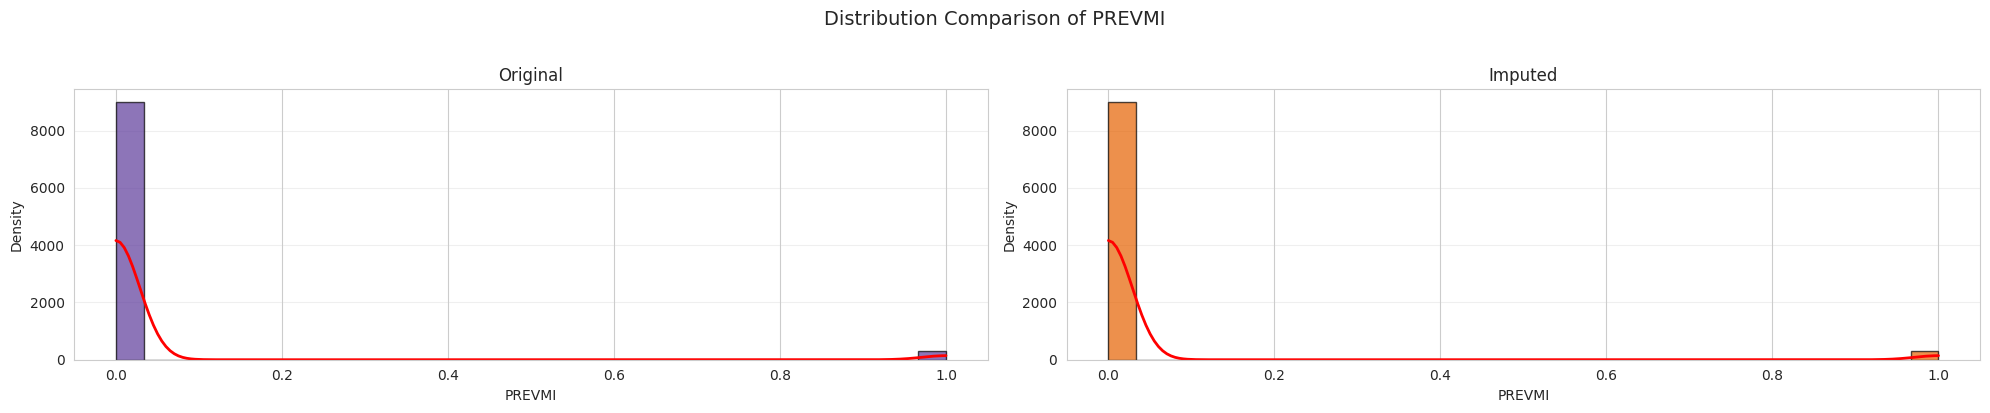

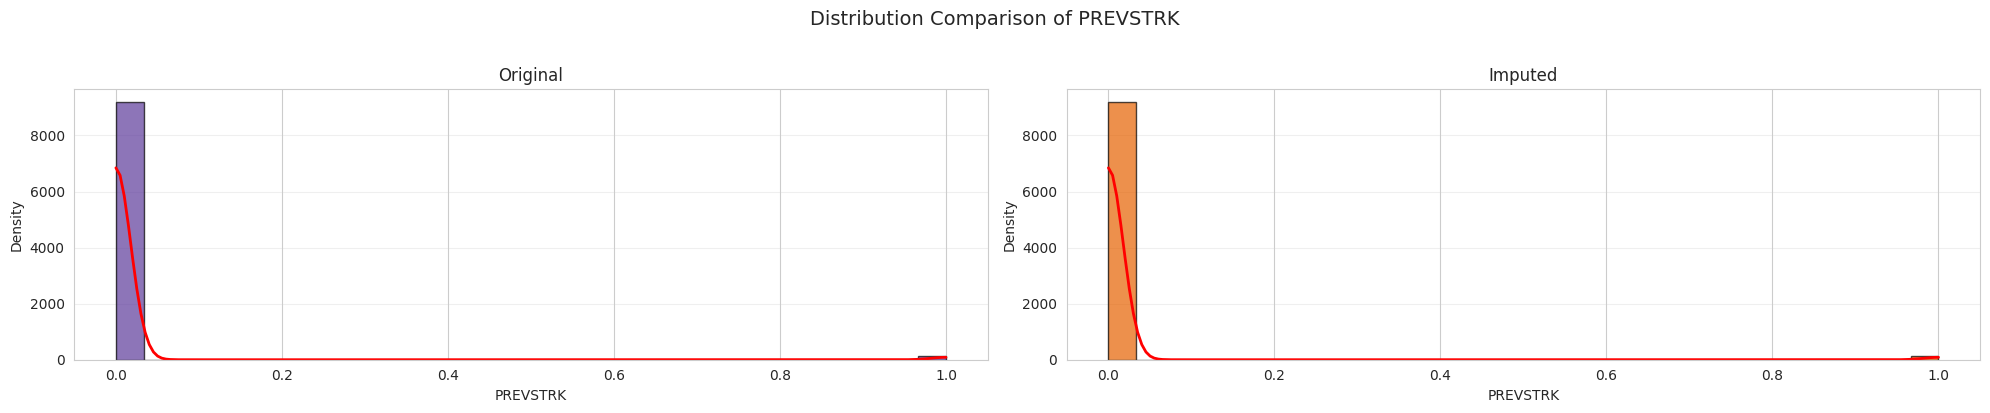

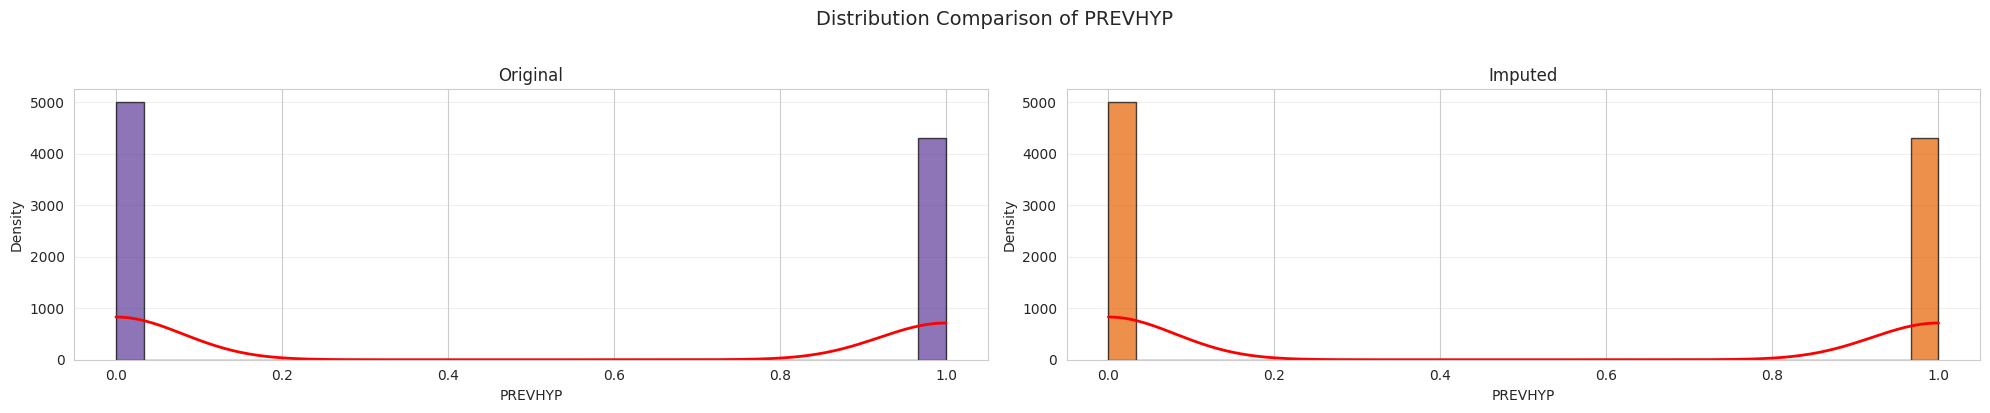

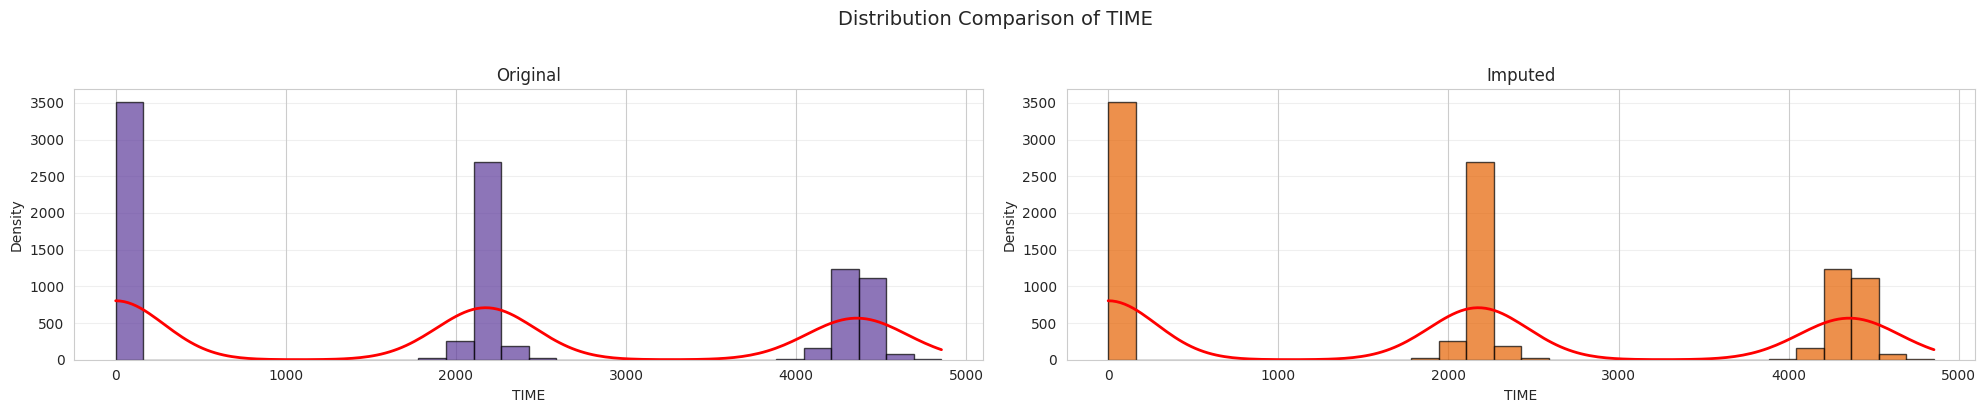

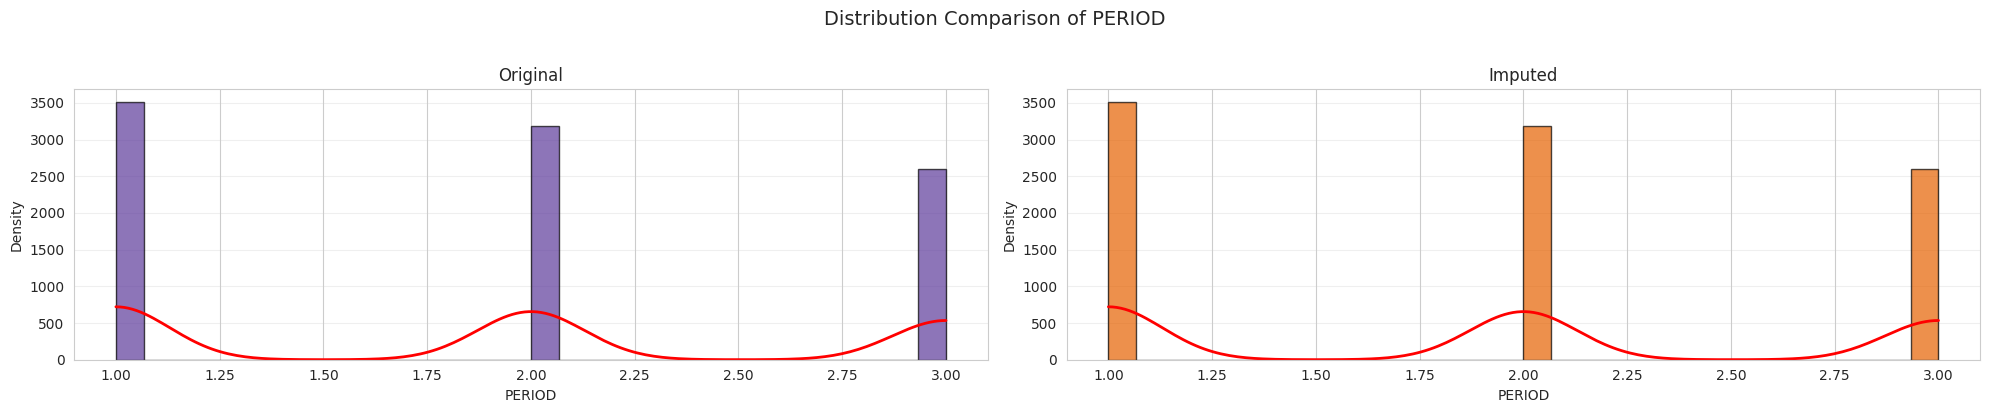

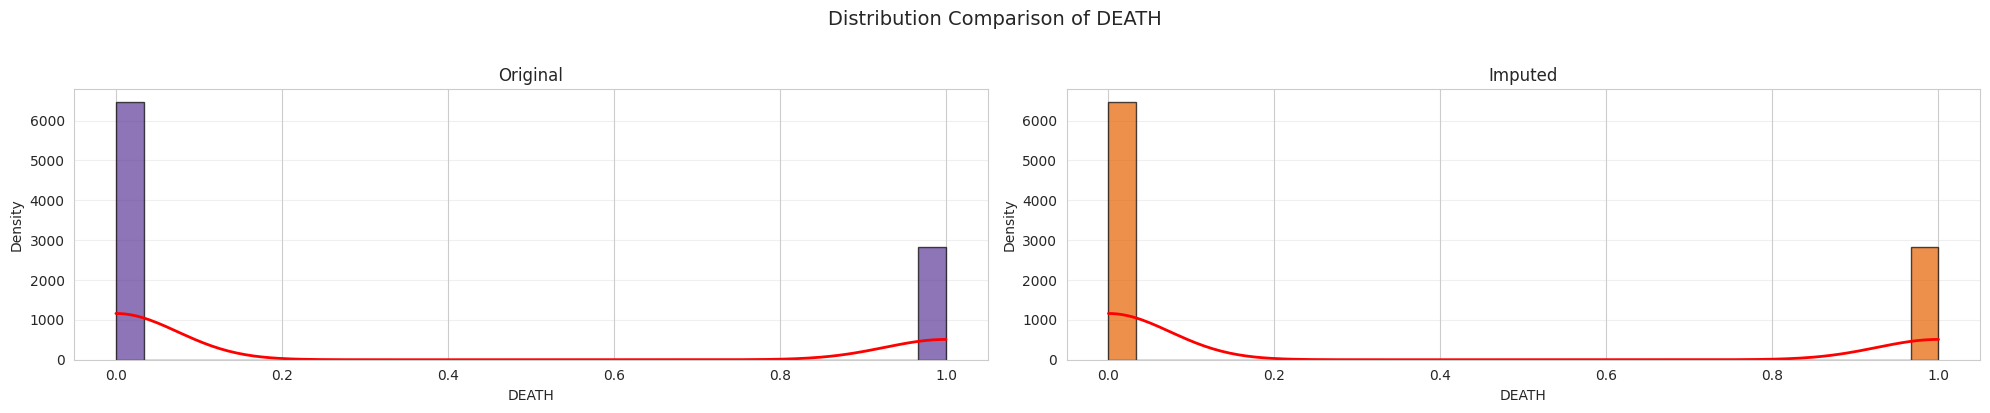

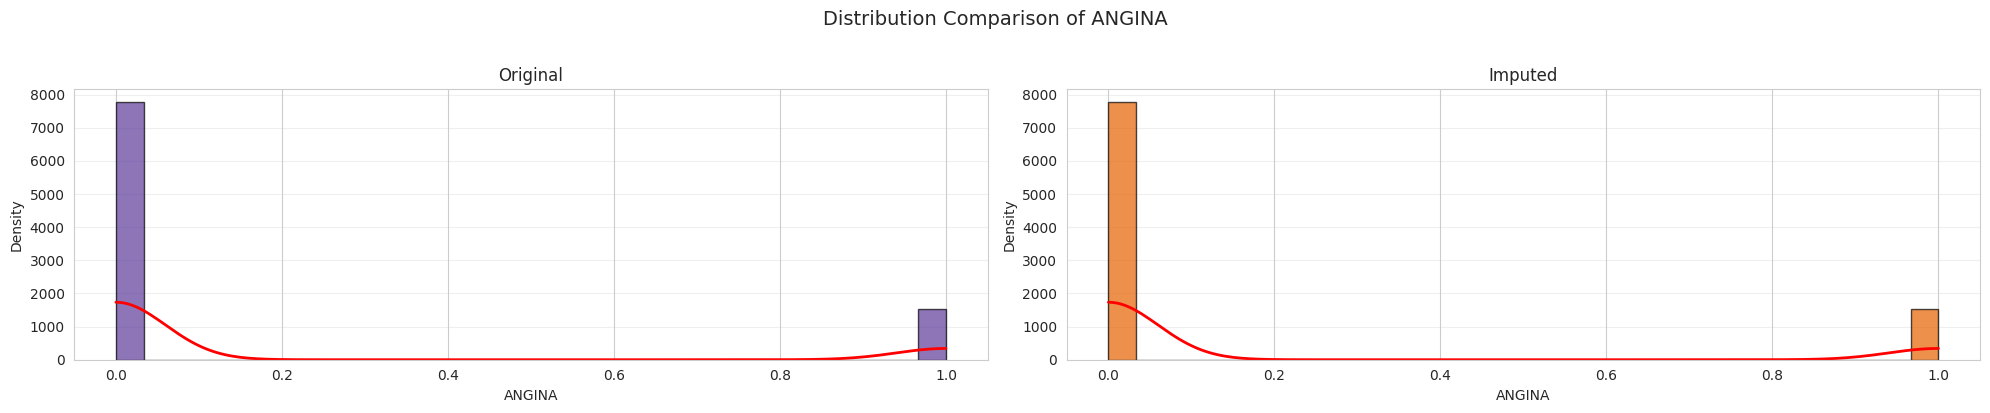

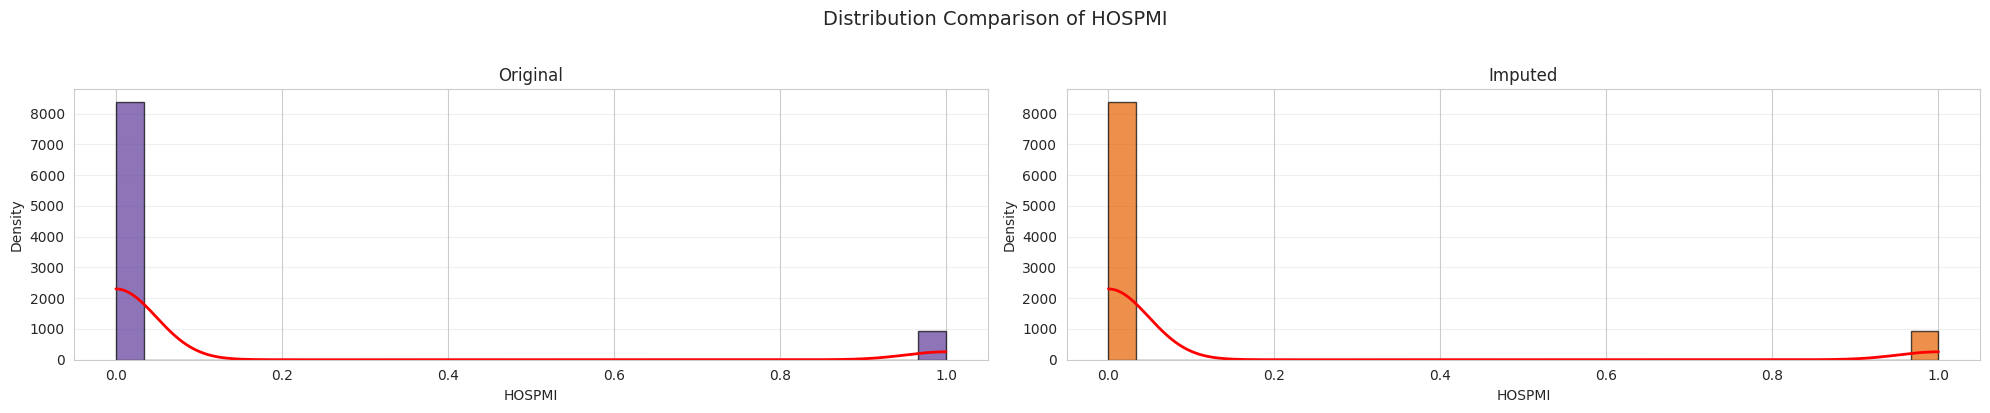

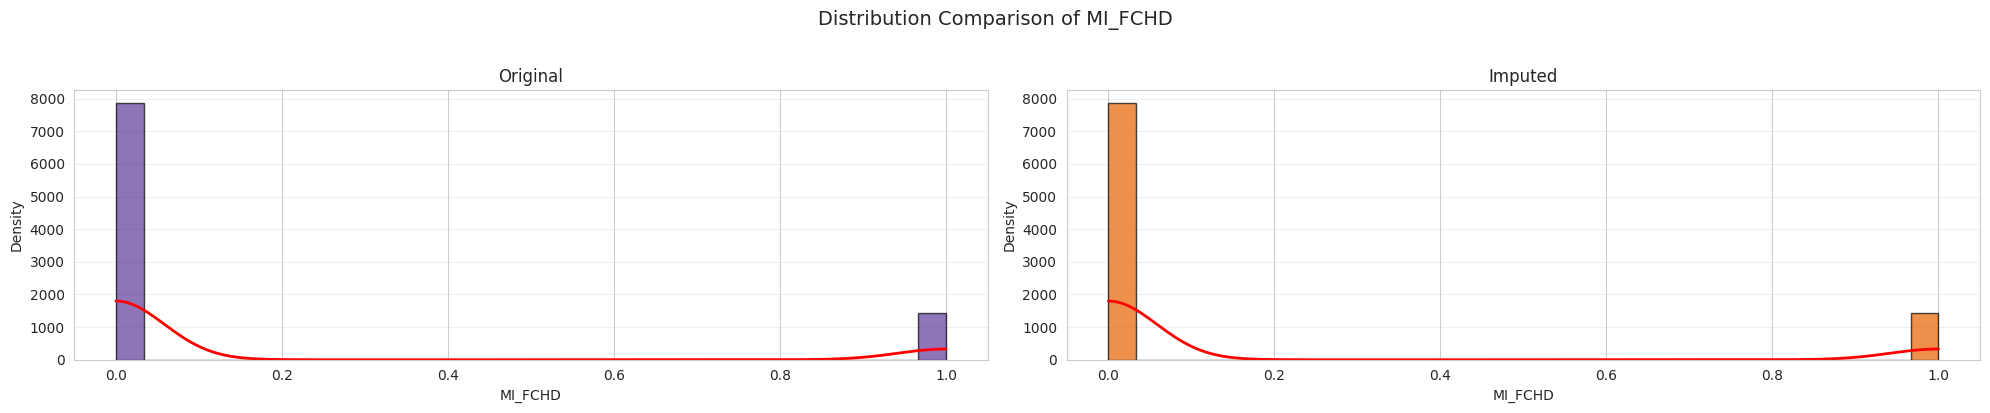

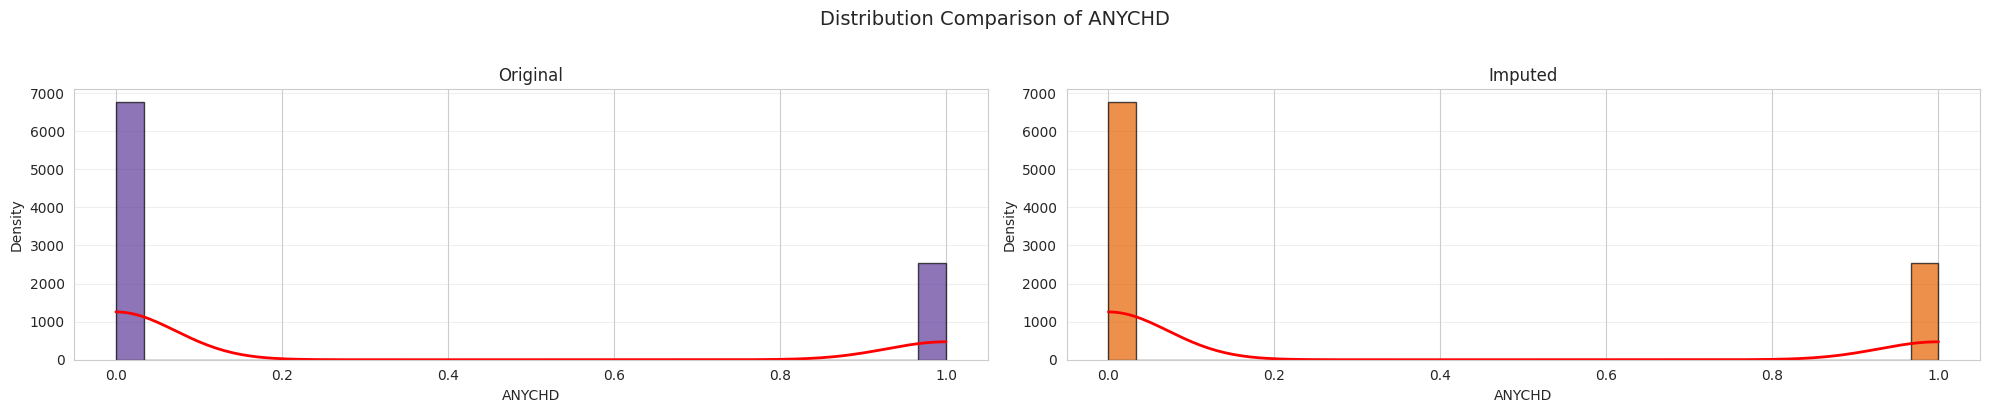

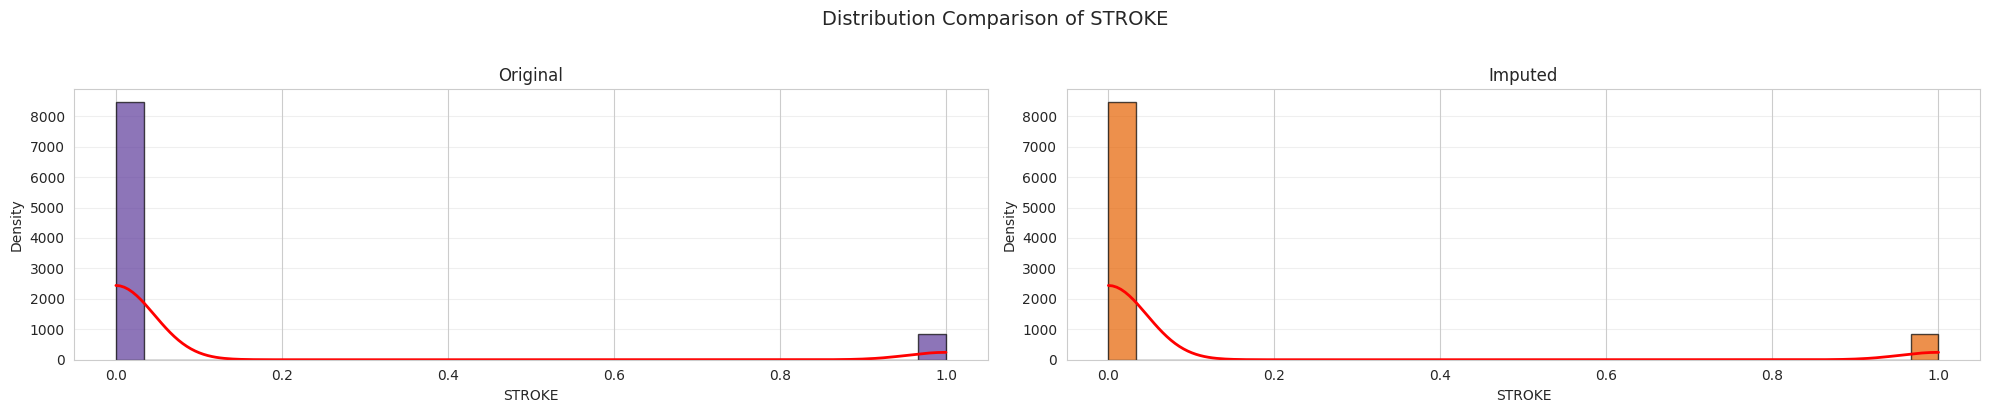

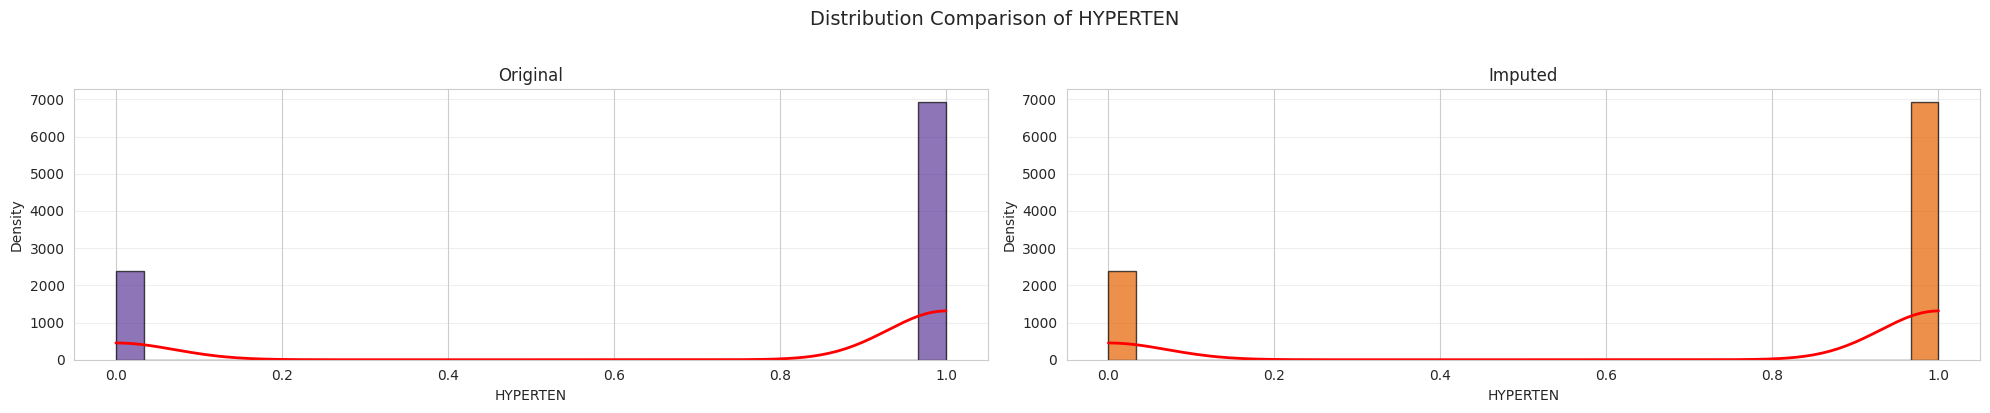

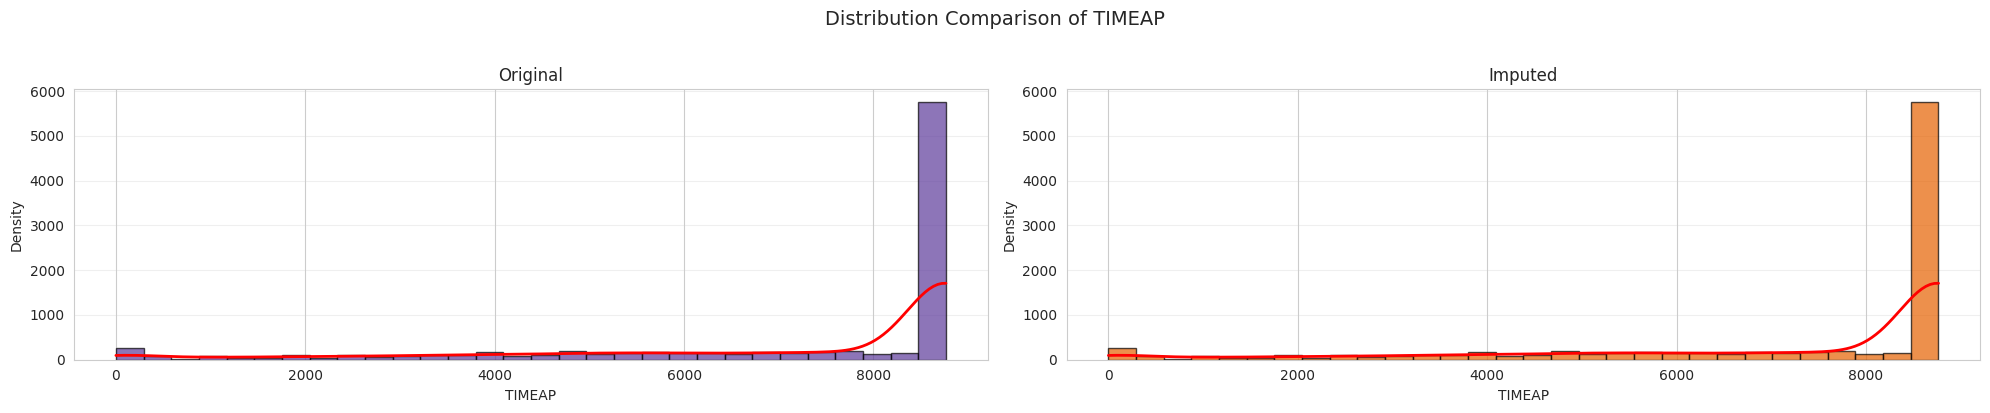

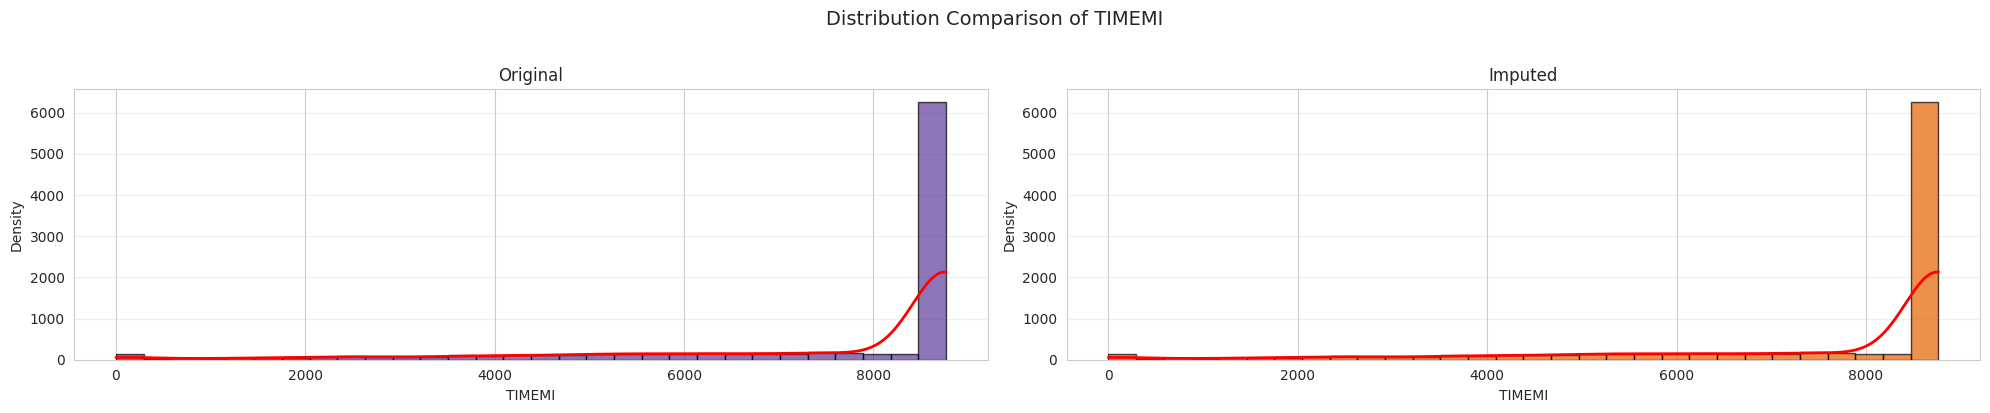

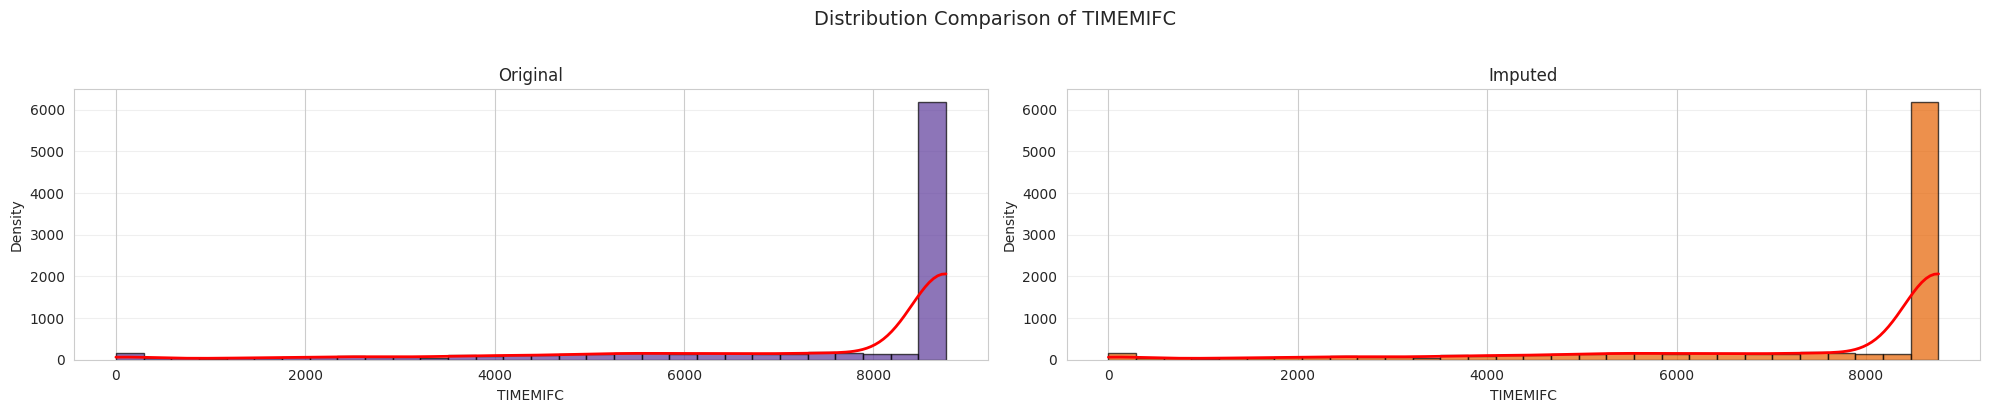

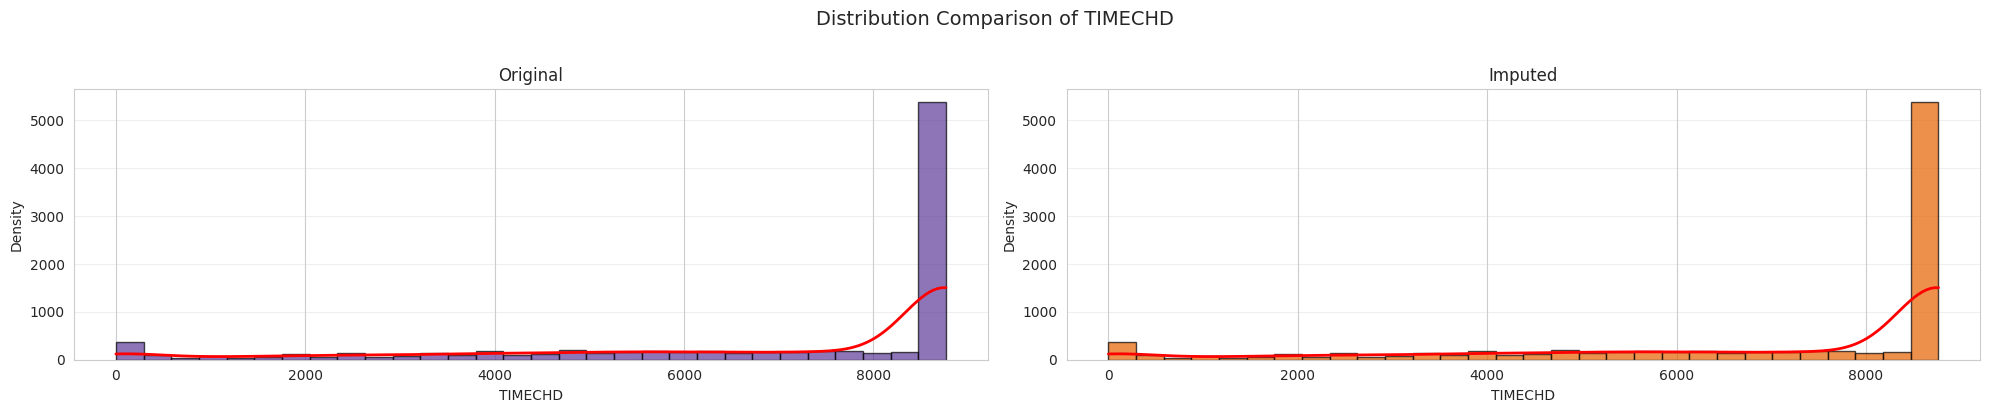

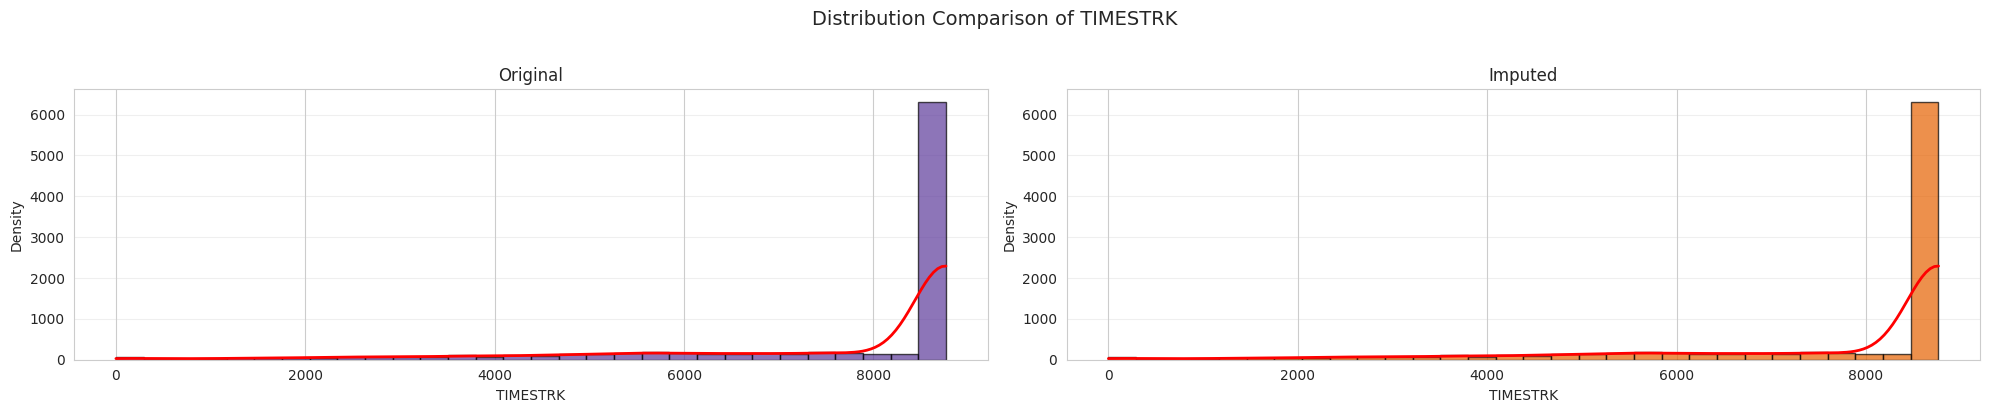

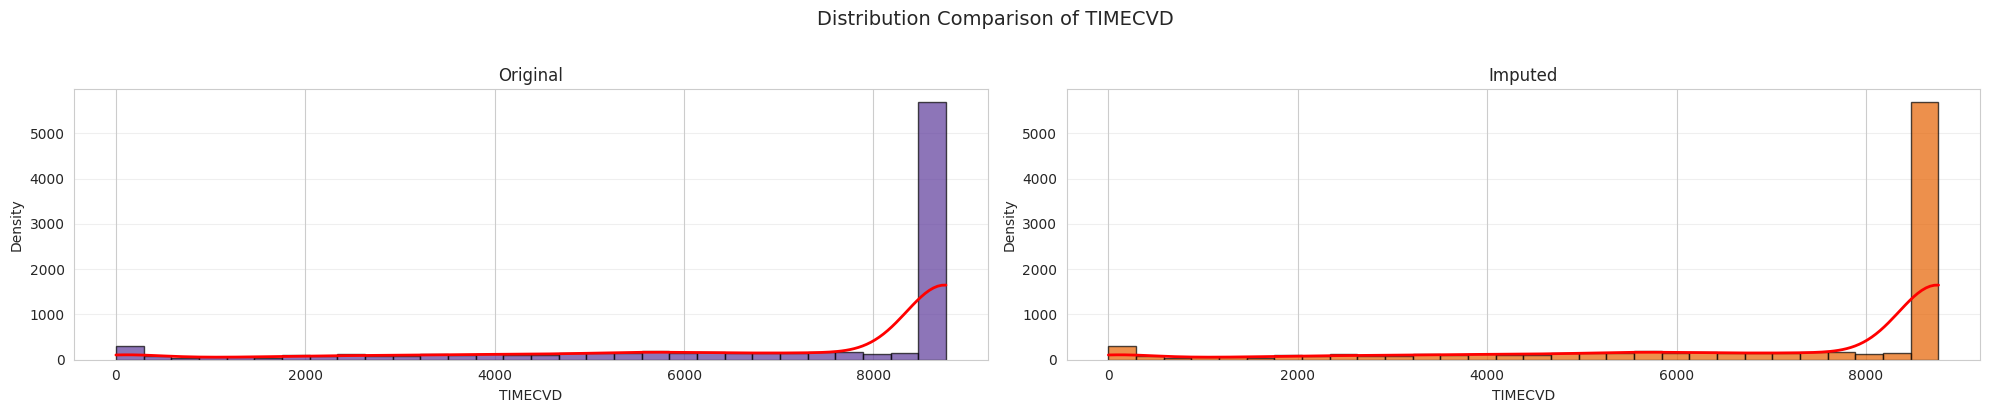

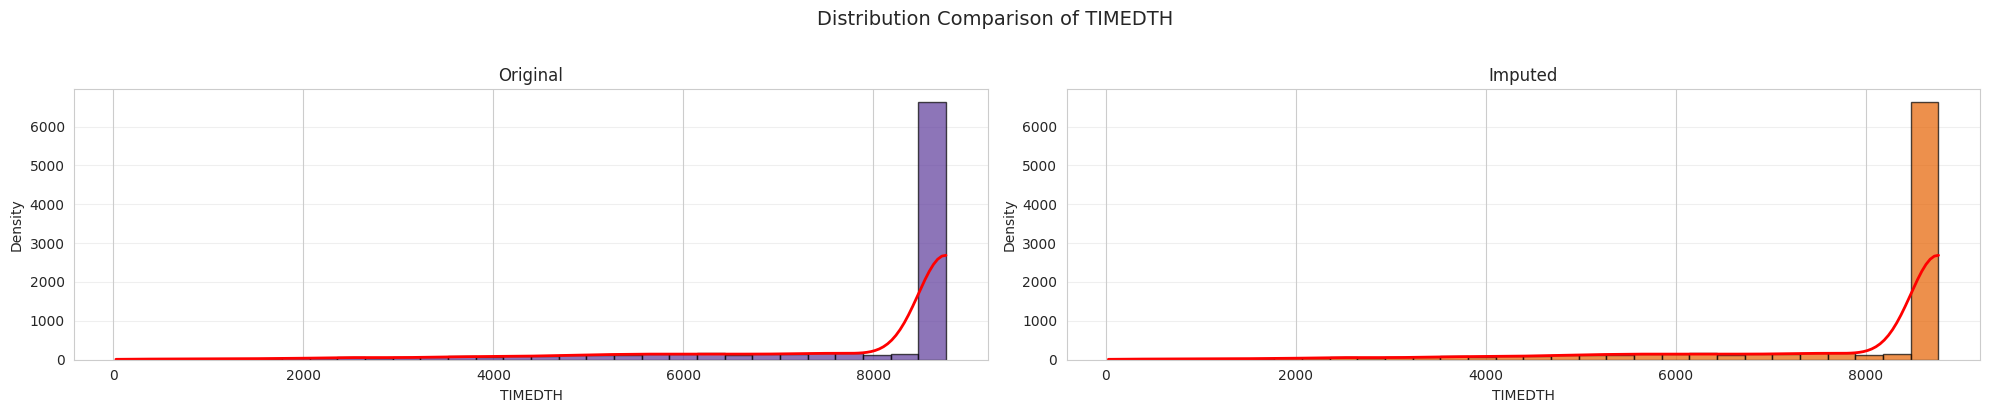

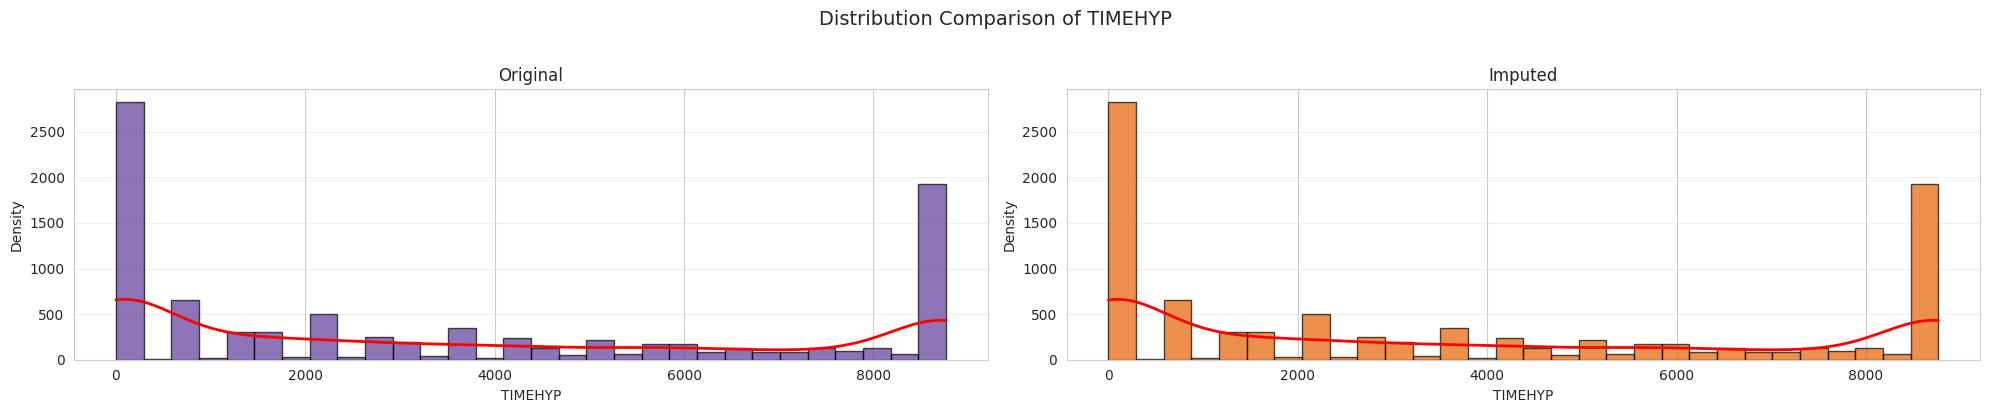

Checking         RANDID  SEX  TOTCHOL  AGE  SYSBP  DIABP  CURSMOKE  CIGPDAY    BMI  \
9733   8423619    2    265.0   55  154.0   87.0         1      9.0  20.92   
972     825139    2    239.0   60  129.0   74.0         0      0.0  26.69   
5083   4360095    2    243.0   56  123.0   78.0         1     30.0  23.18   
10266  8891825    2    206.0   72  165.0   94.0         0      0.0  22.37   
1079    923590    1    258.0   53  112.5   69.0         0      0.0  25.27   
...        ...  ...      ...  ...    ...    ...       ...      ...    ...   
11527  9911212    2    236.0   42  160.5  100.0         0      0.0  27.01   
1334   1098348    1    340.0   56  134.0   89.5         1     20.0  21.91   
4888   4205603    2    176.0   45  108.0   66.0         1      1.0  20.98   
1380   1137973    2    235.0   53  132.0   84.0         0      0.0  30.10   
11070  9483124    2    197.0   68  140.0   80.0         0      0.0  28.30   

       DIABETES  ...  STROKE  HYPERTEN  TIMEAP  TIMEMI  TIMEMIFC  

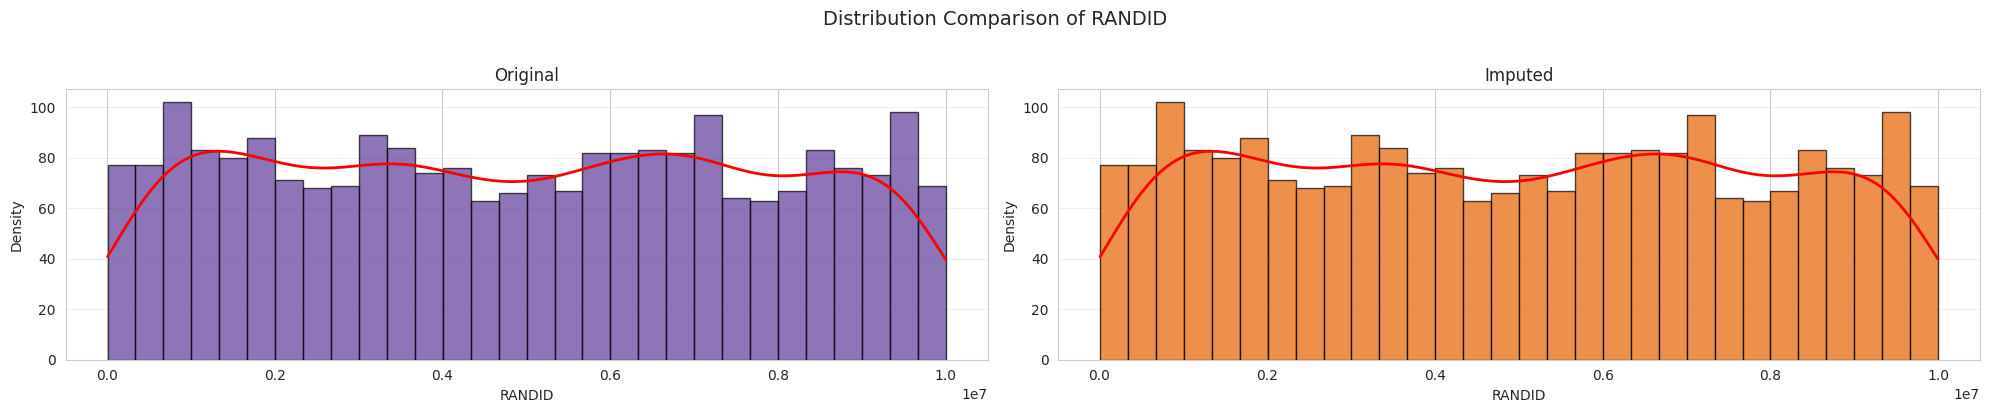

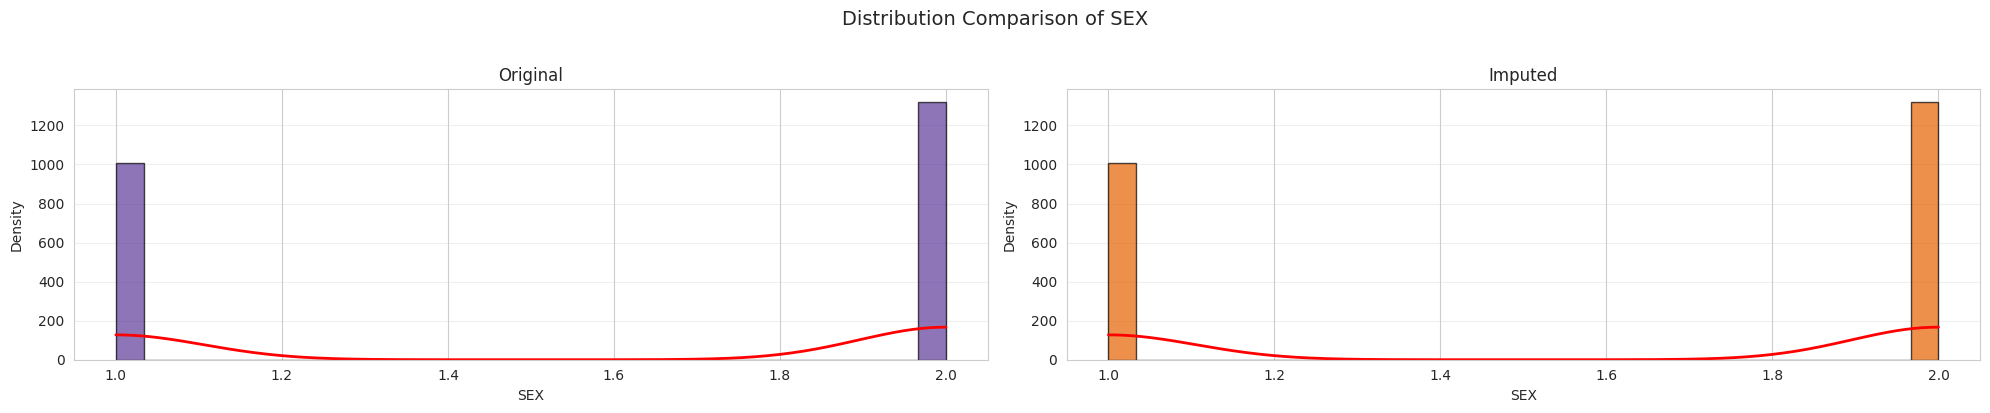

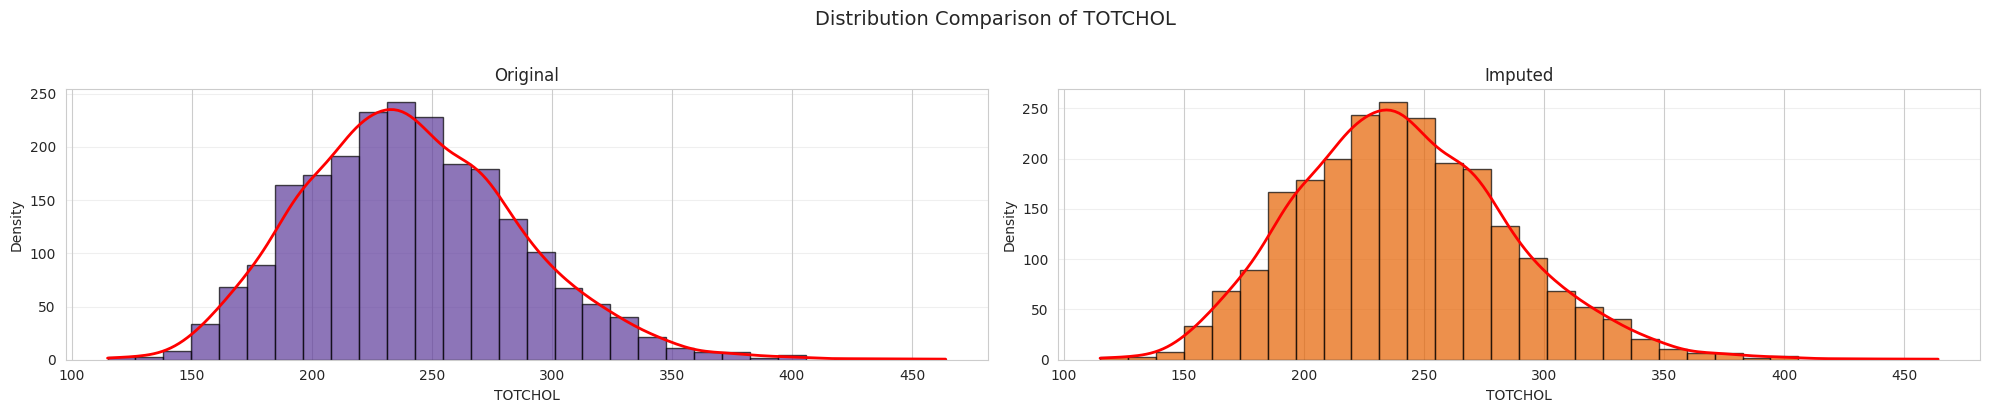

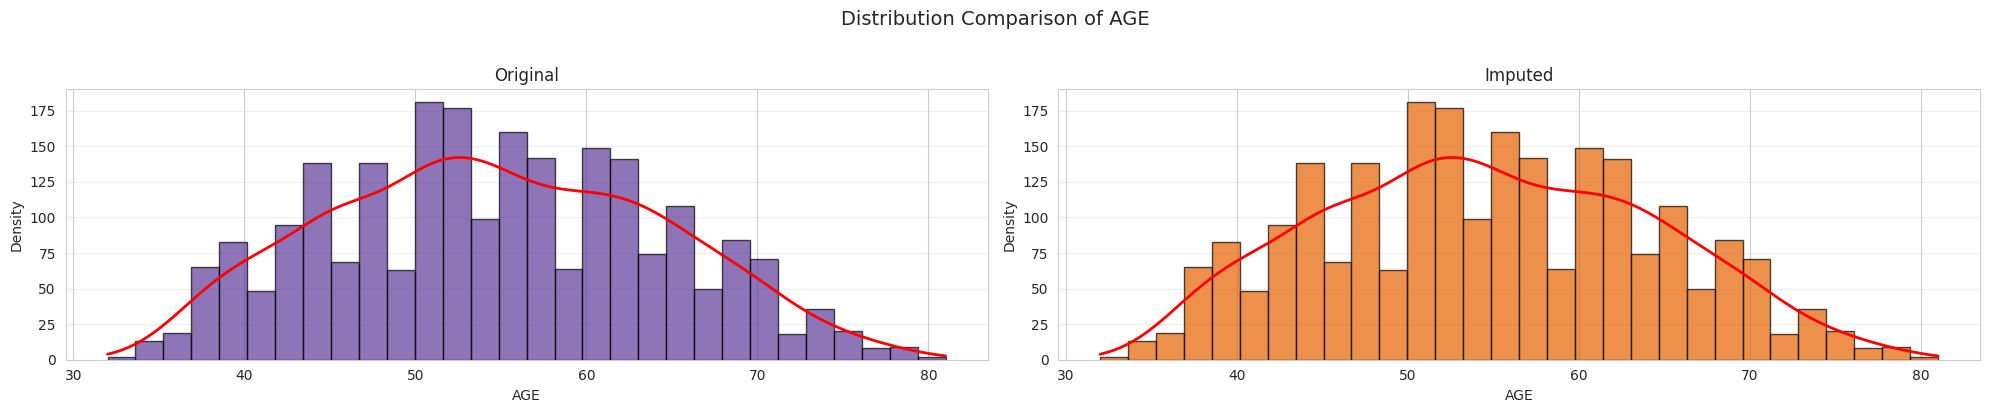

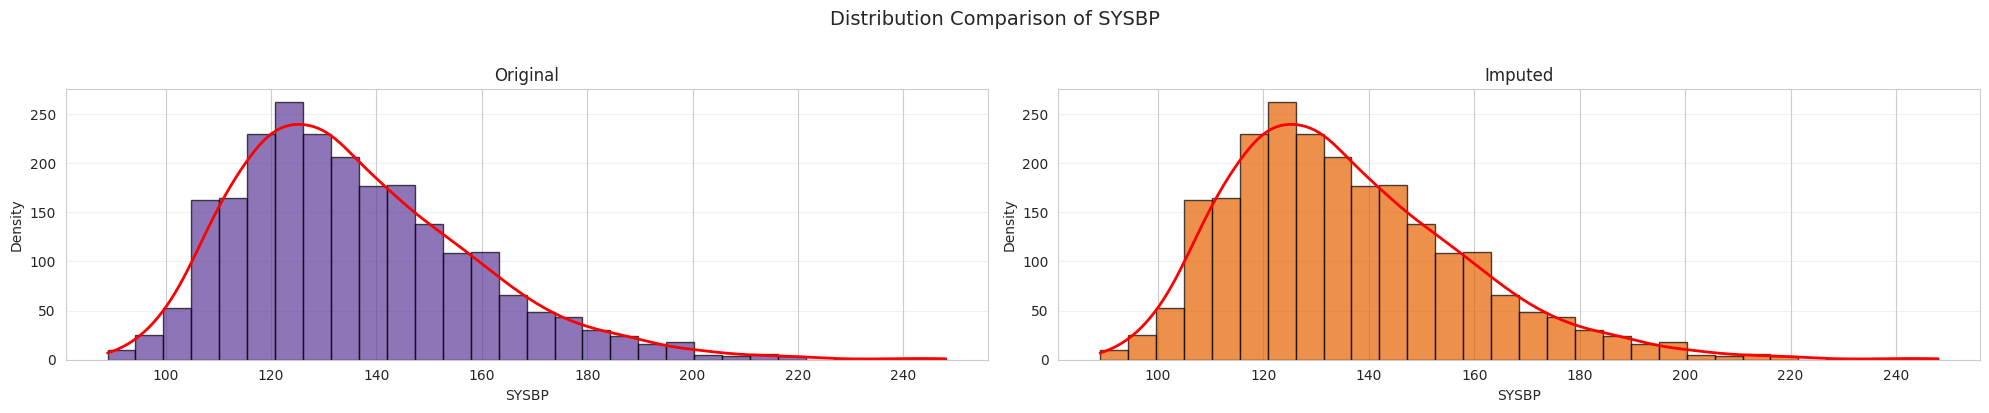

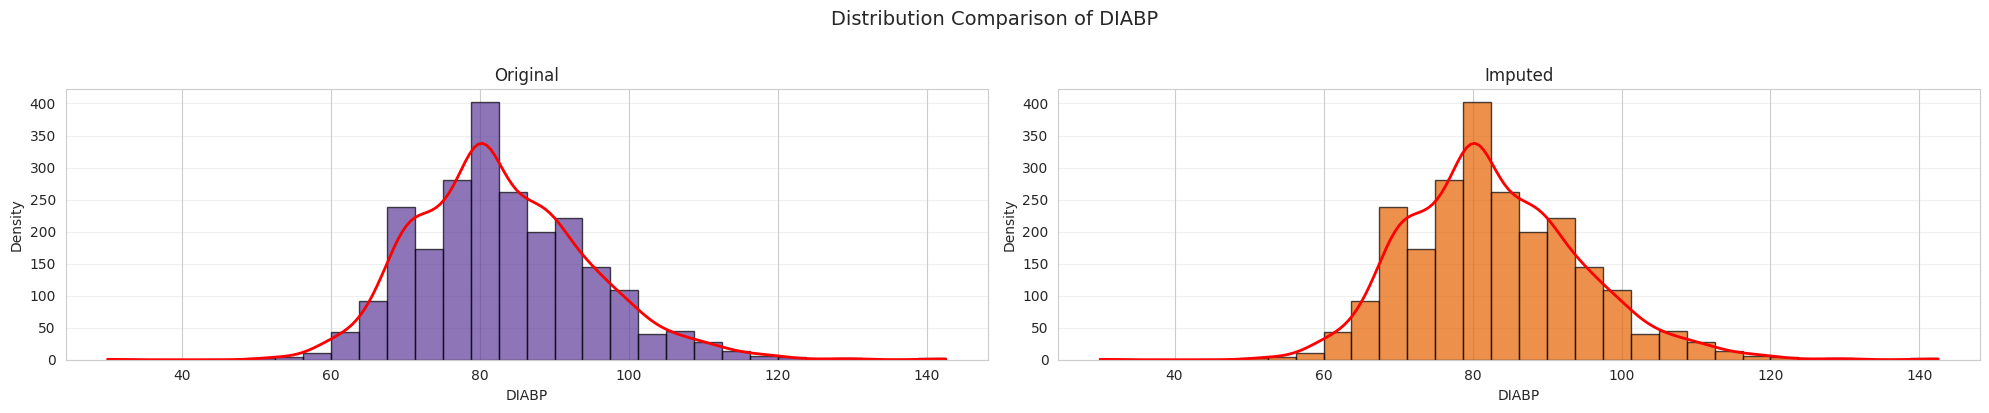

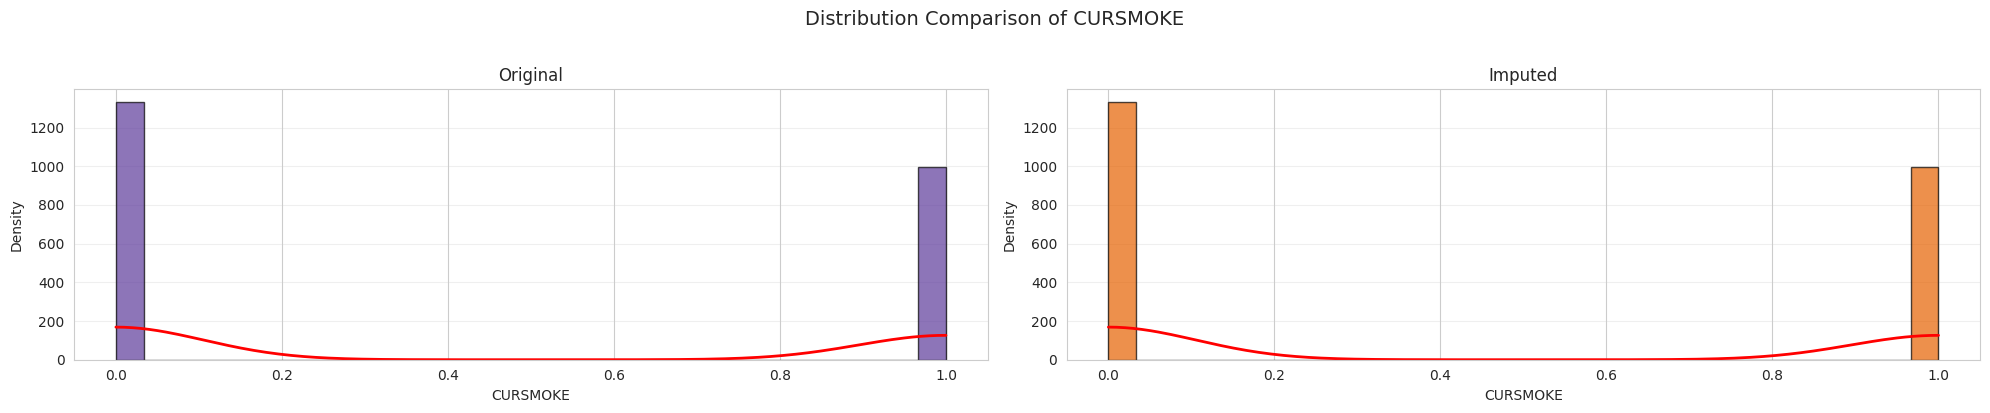

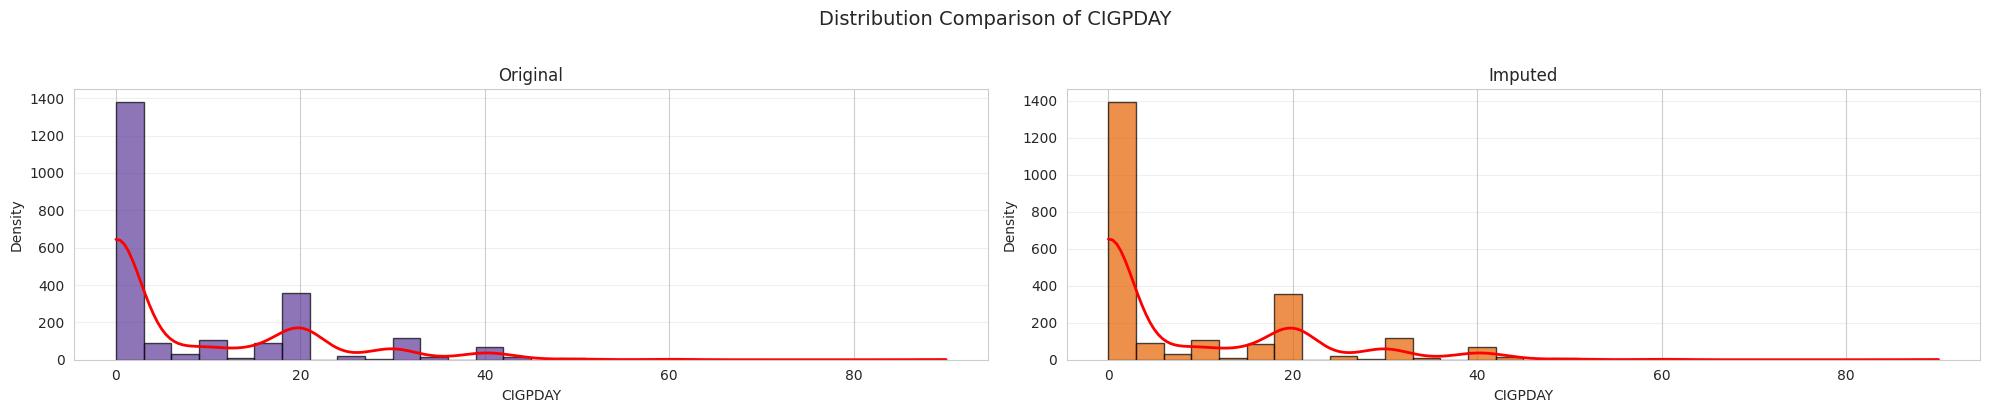

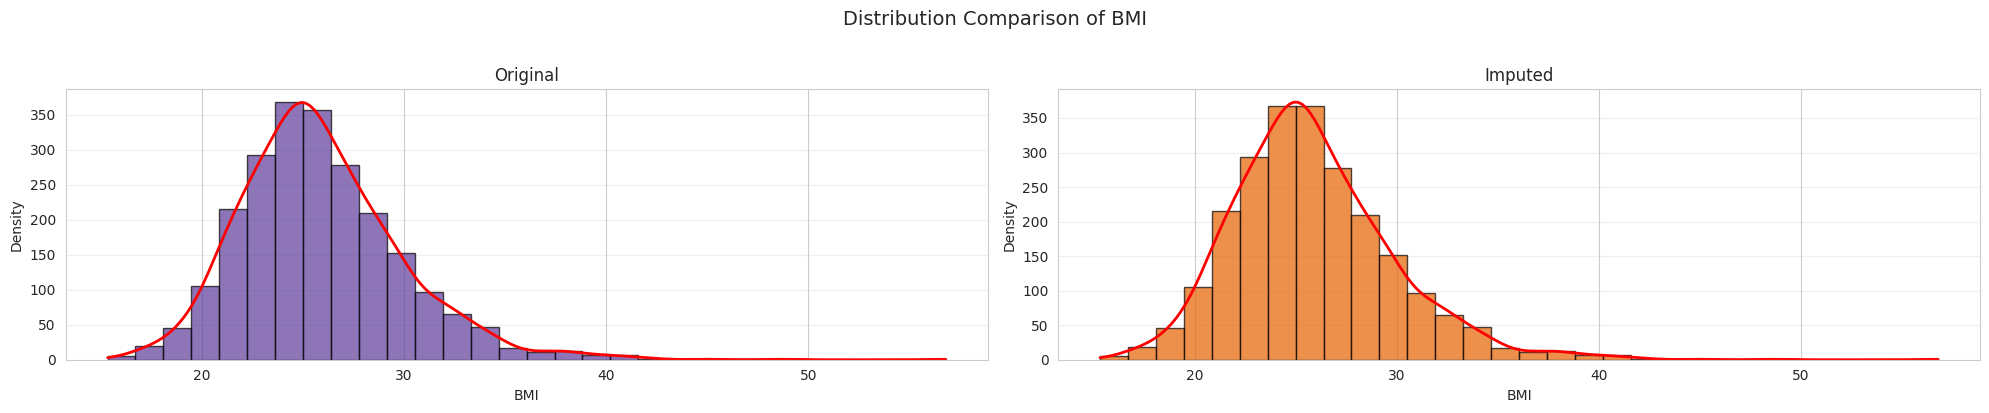

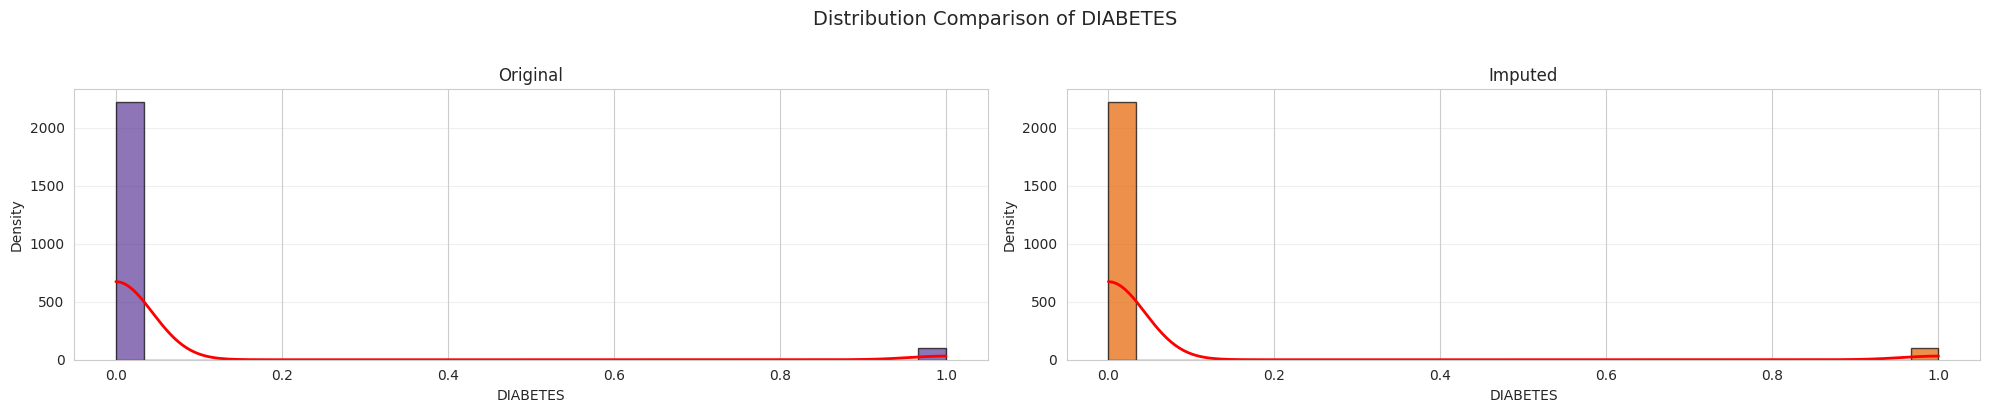

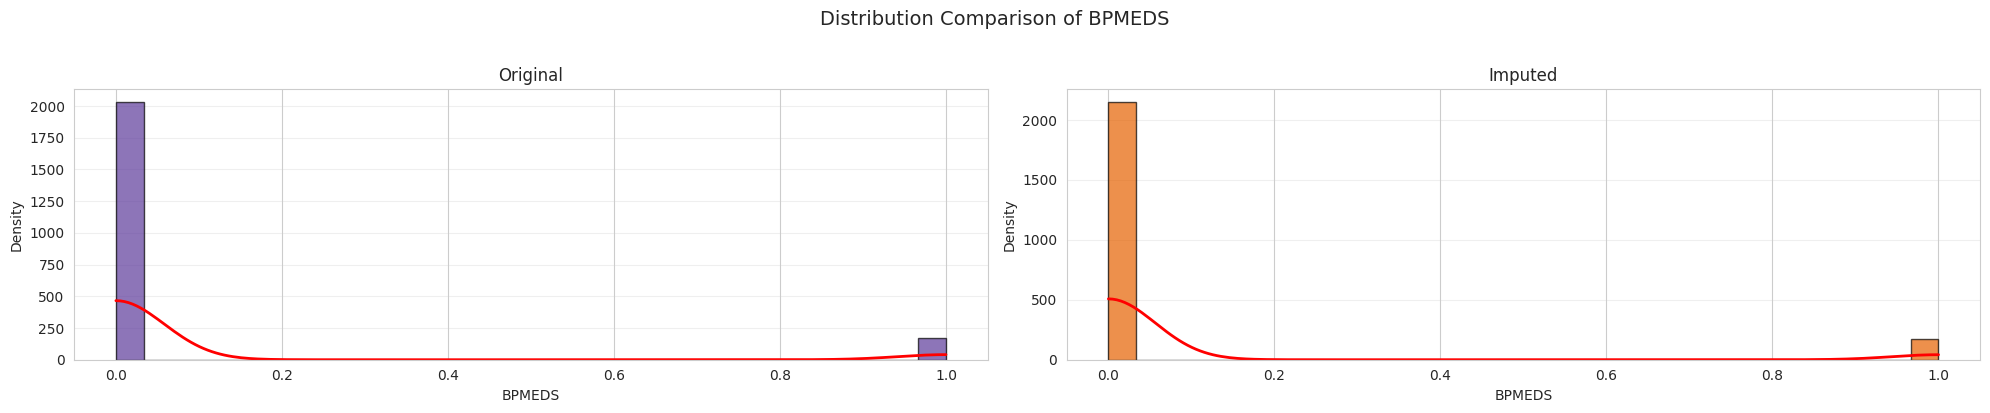

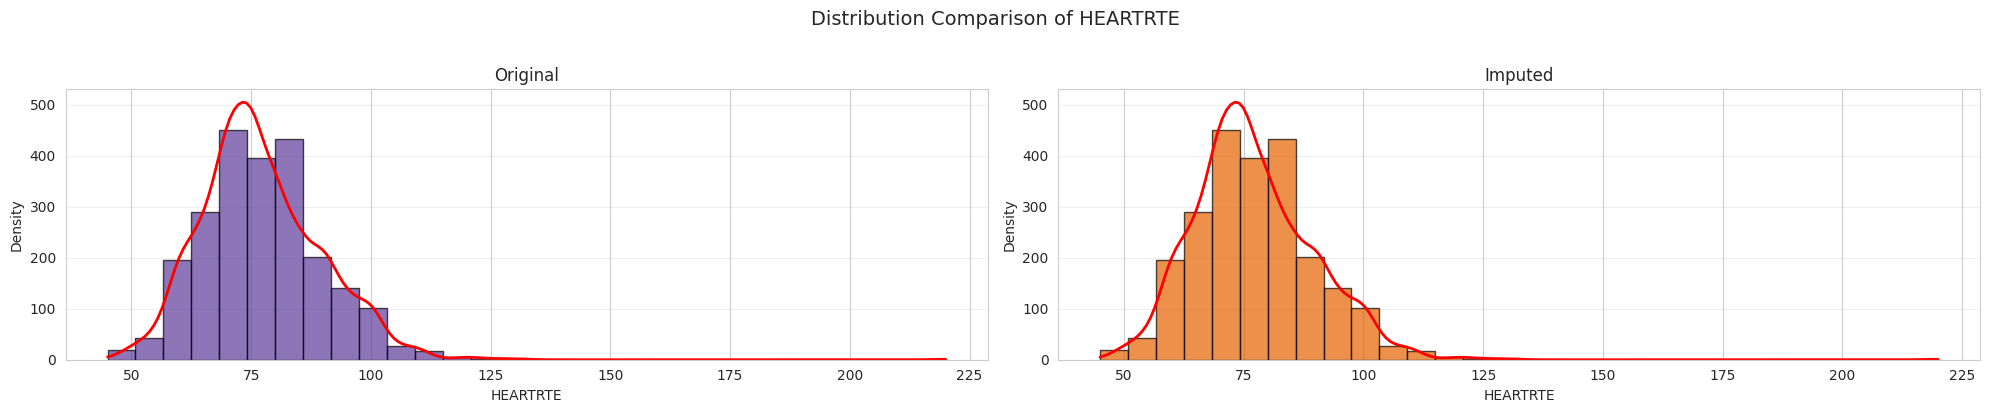

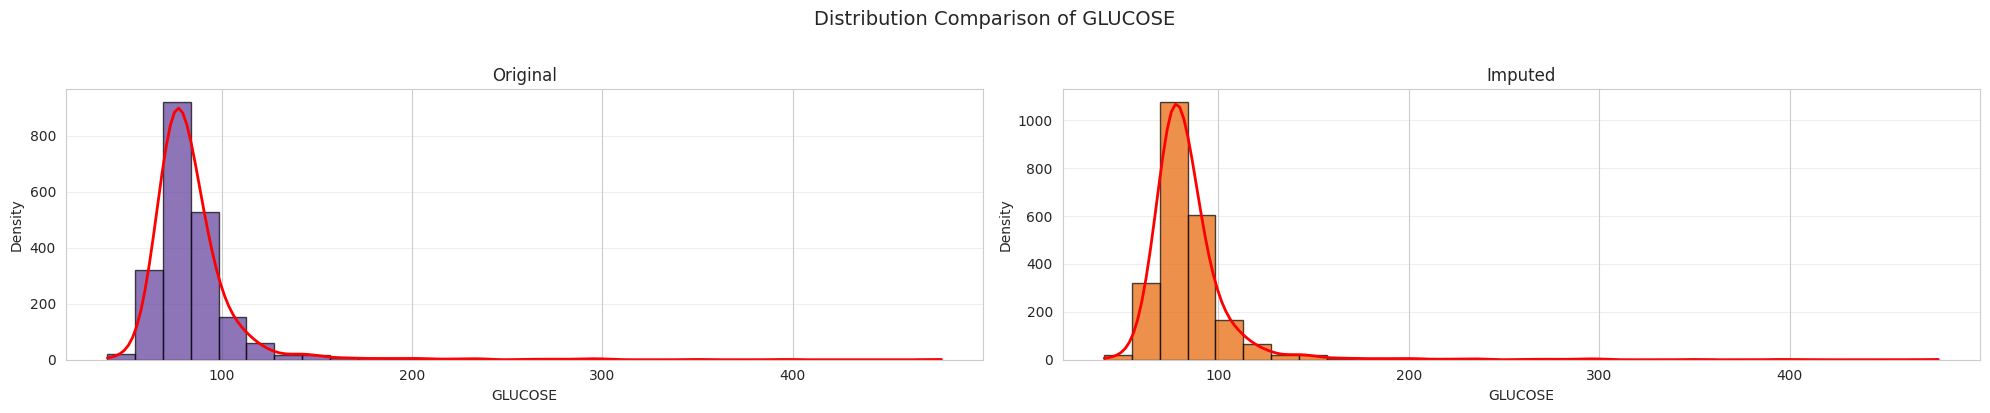

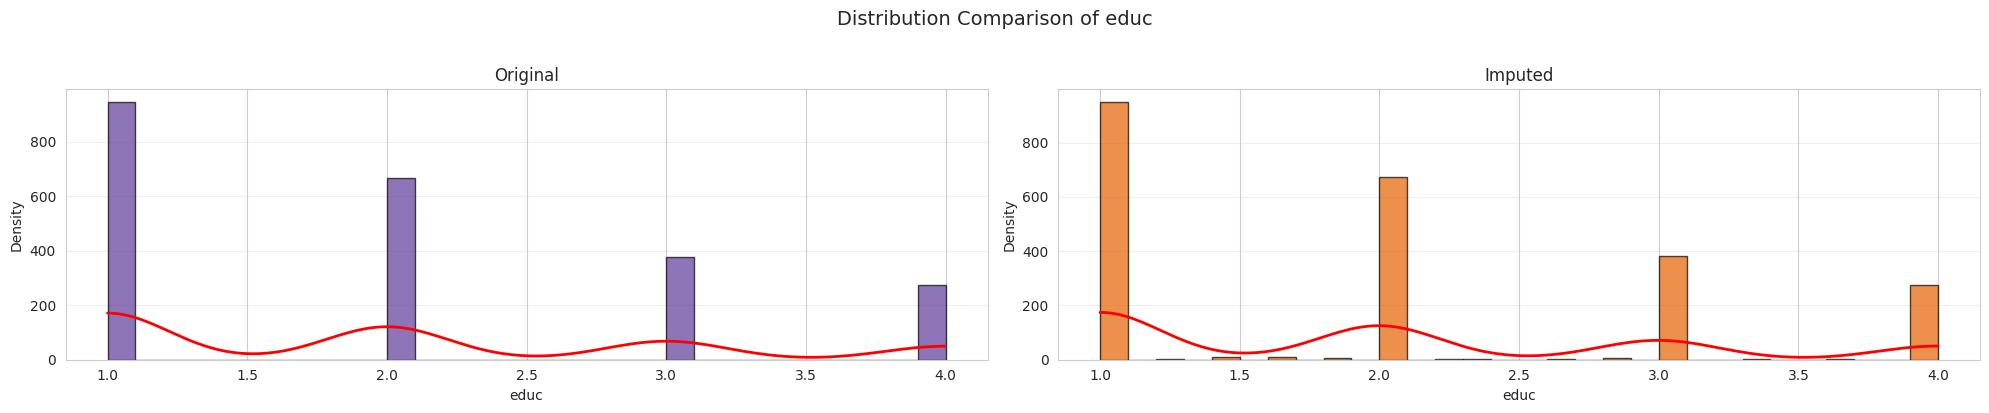

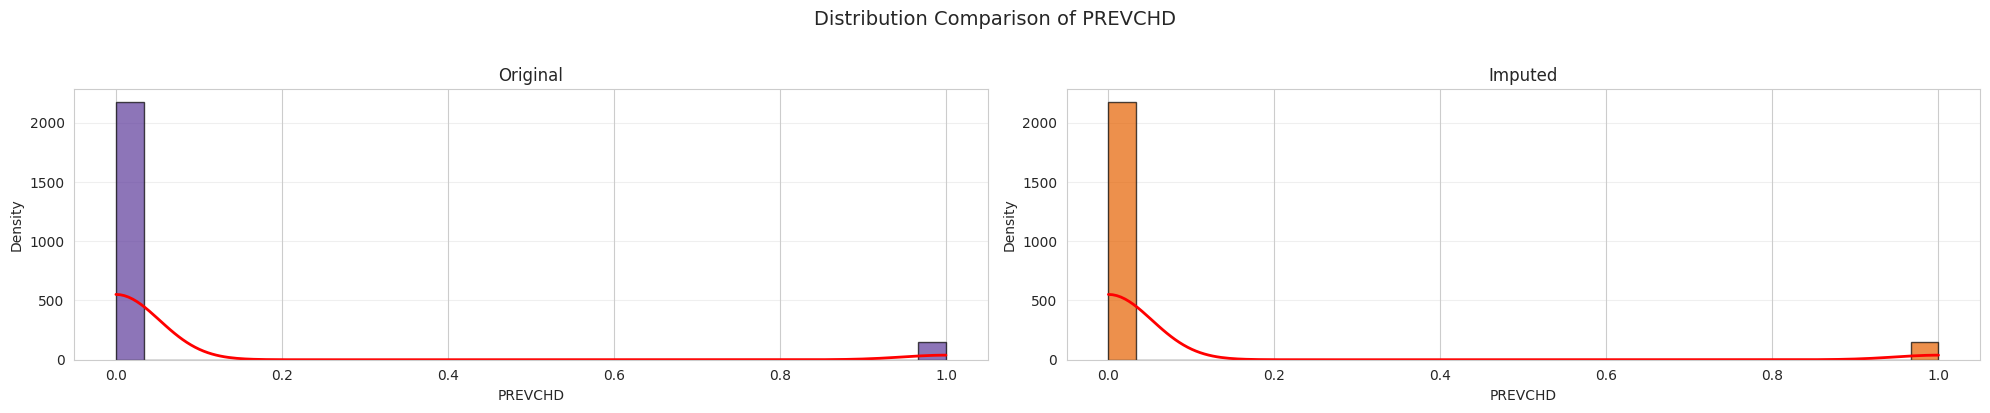

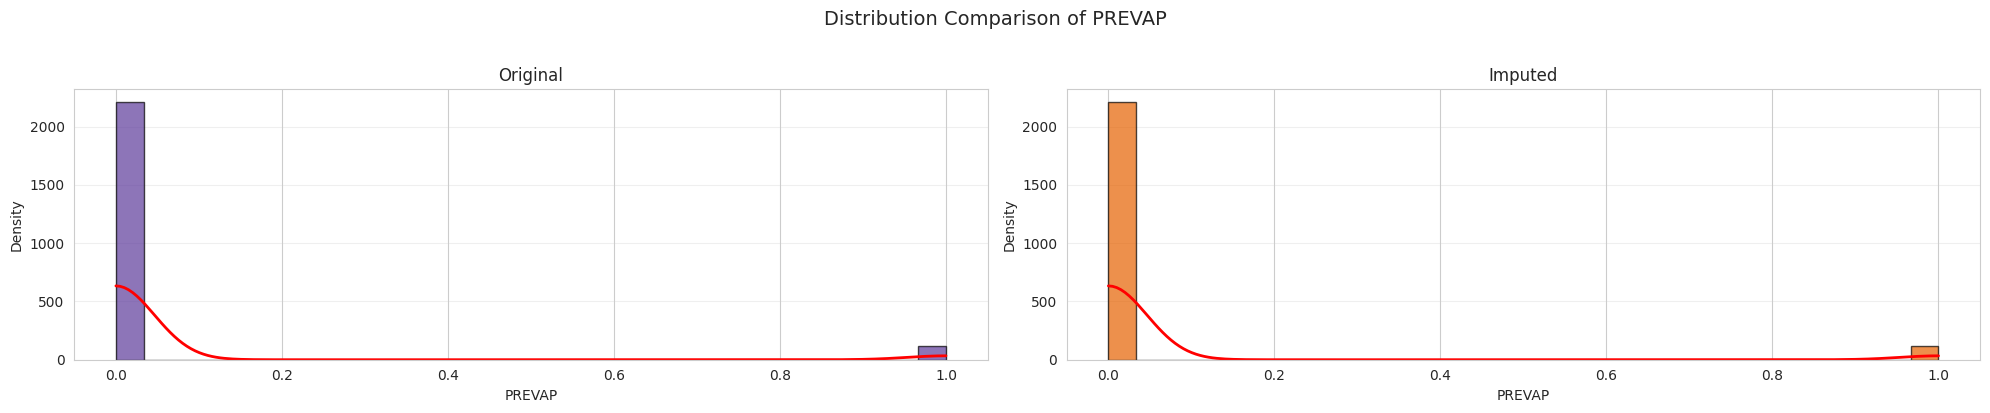

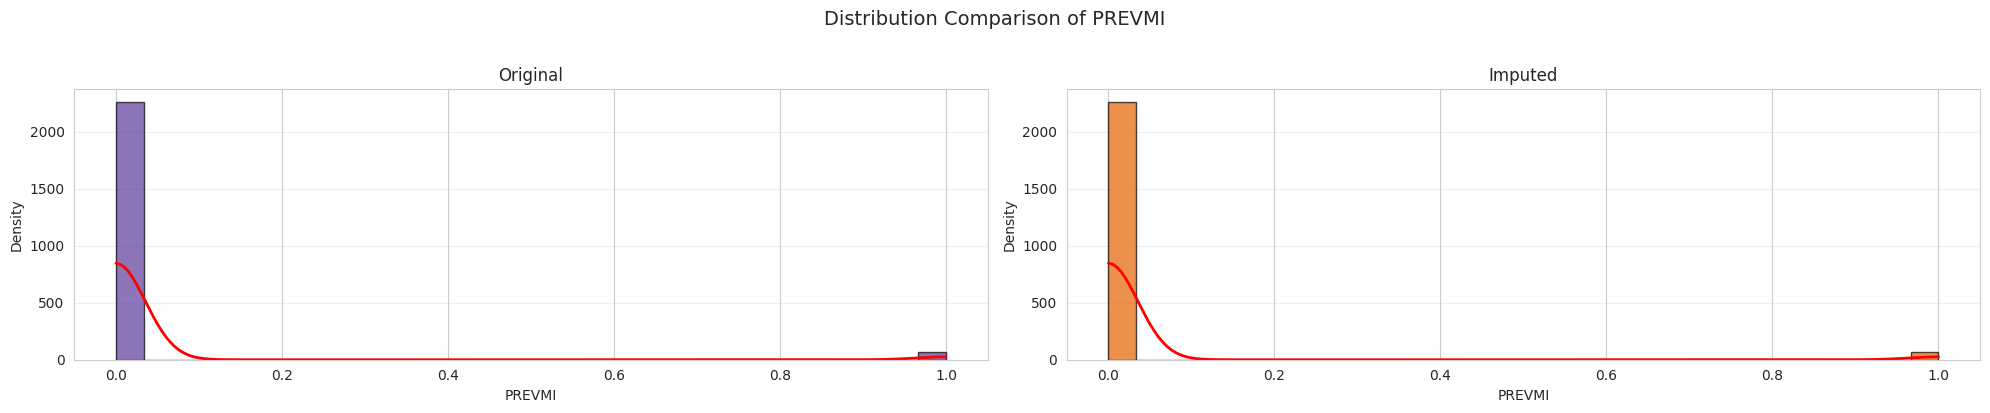

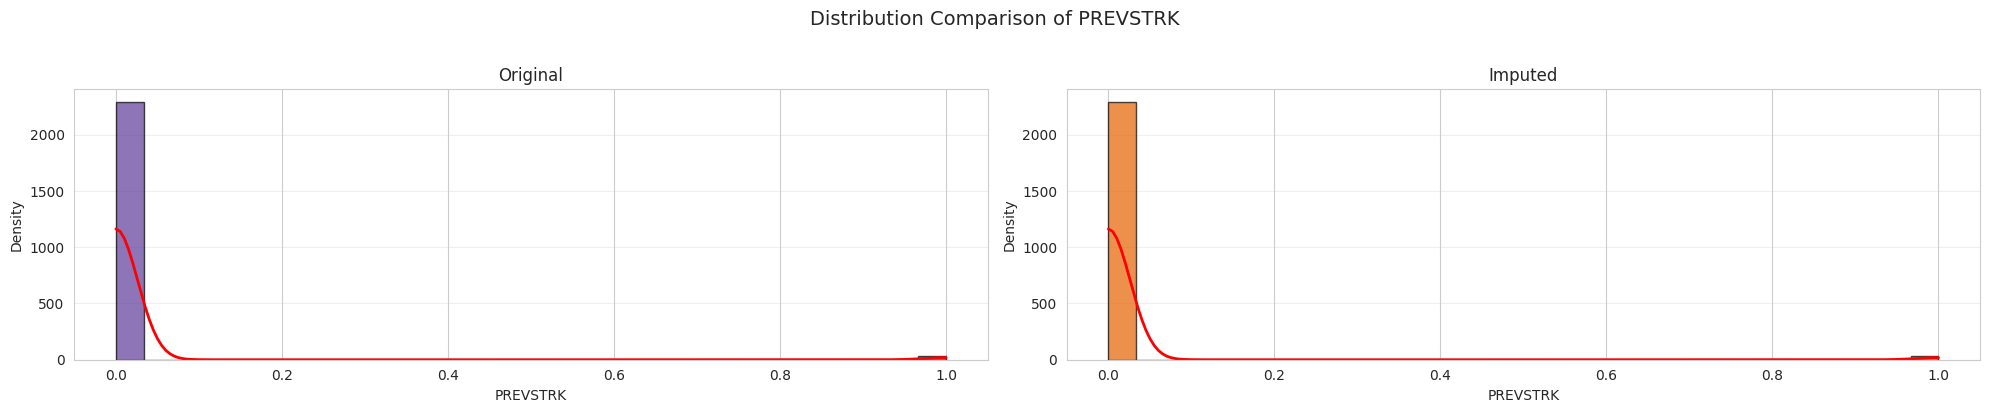

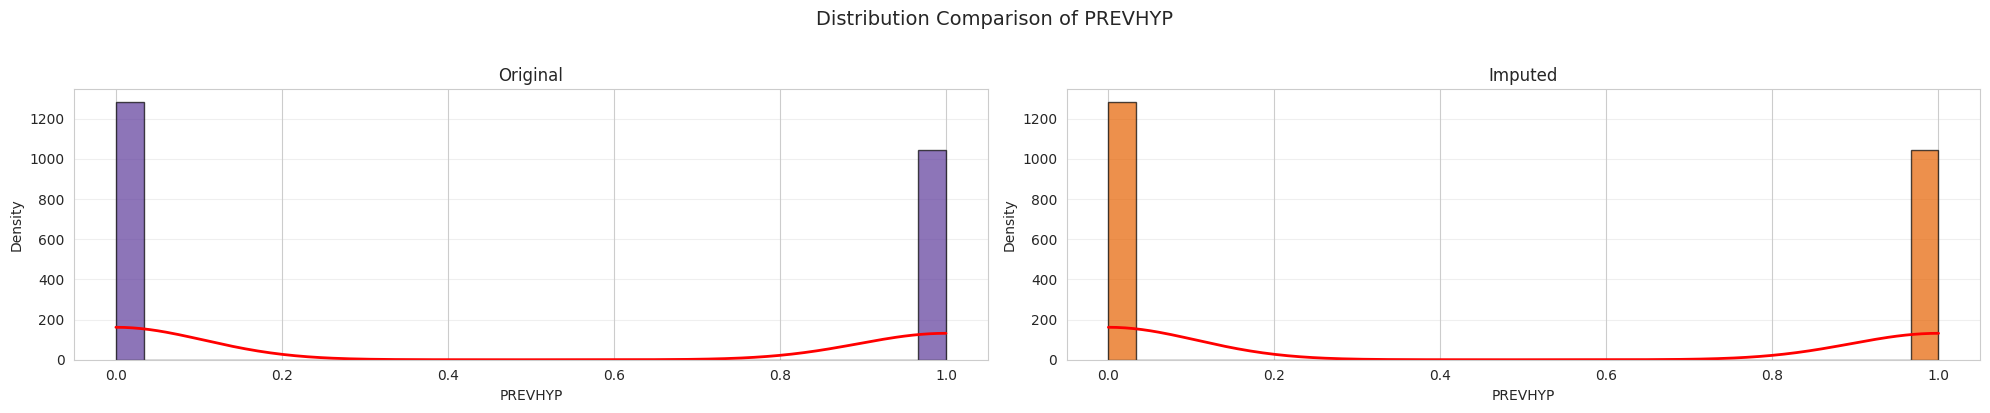

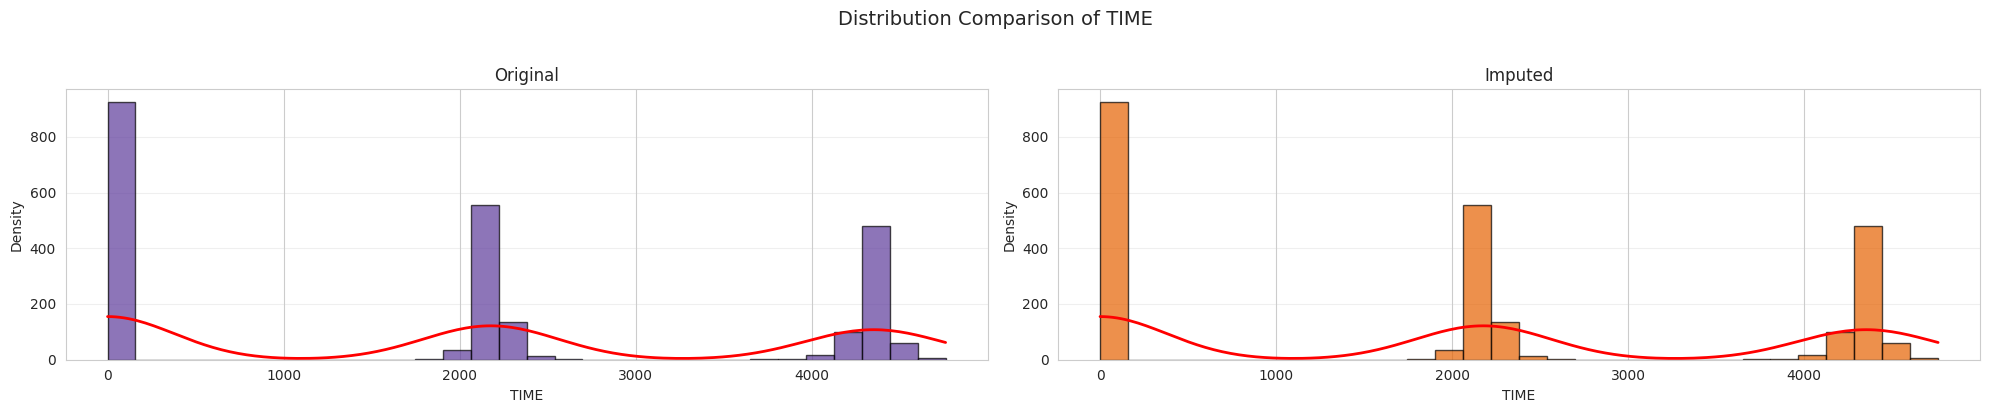

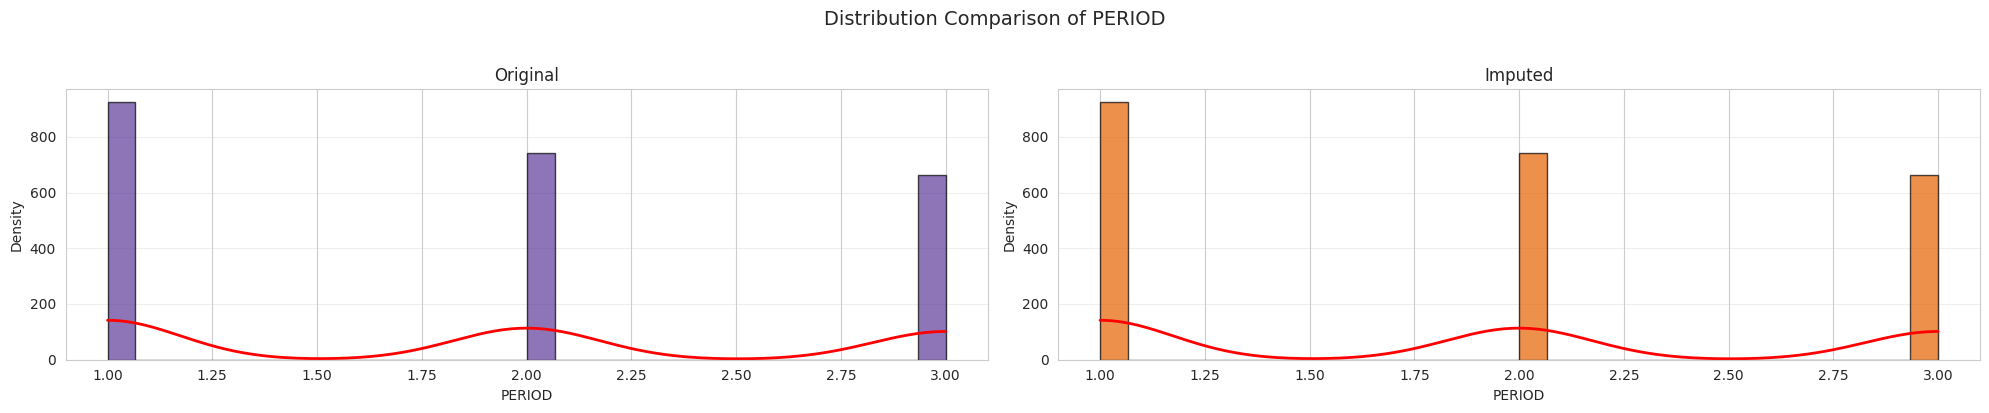

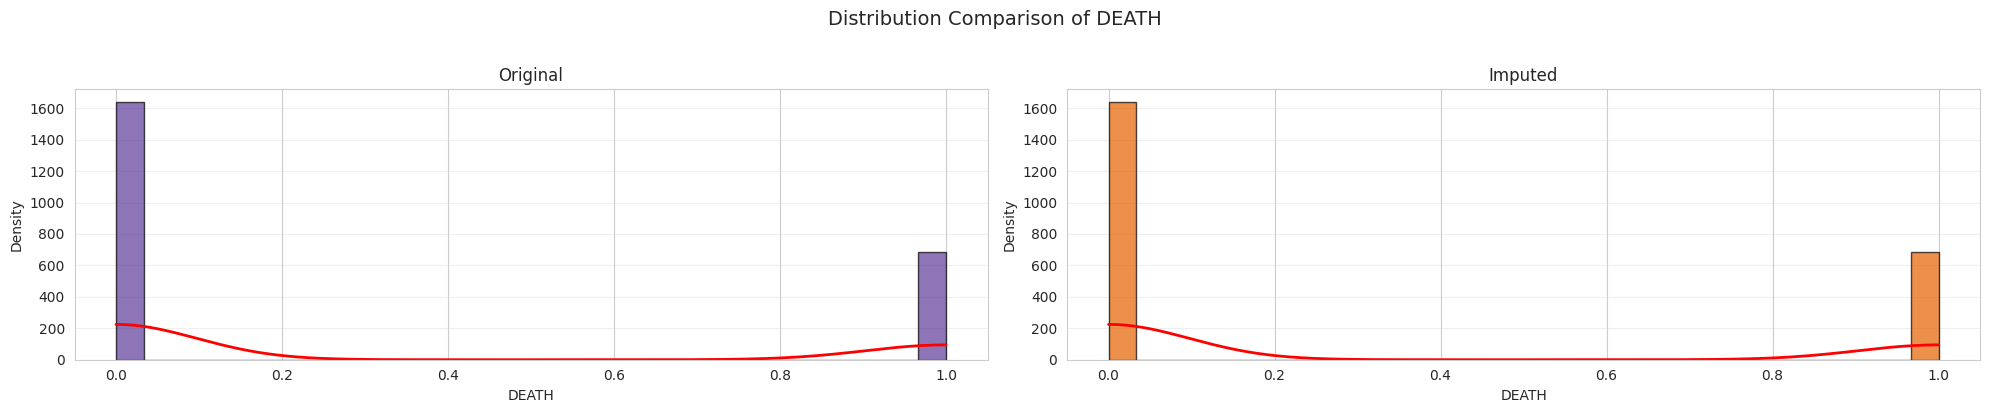

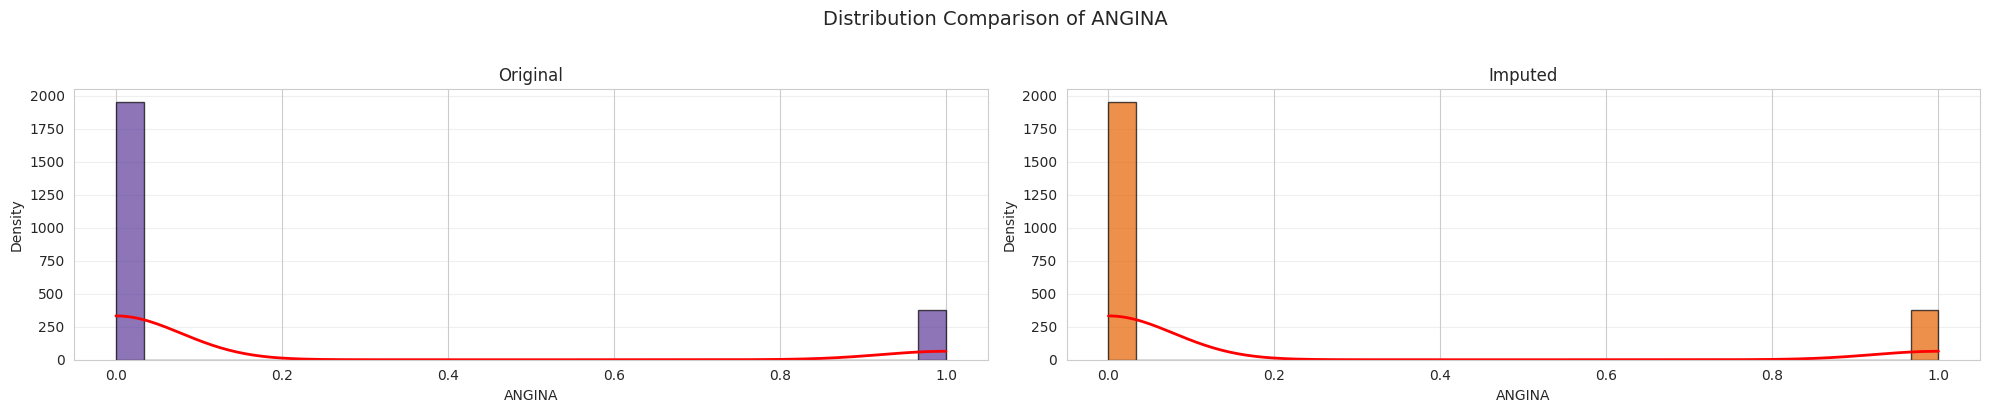

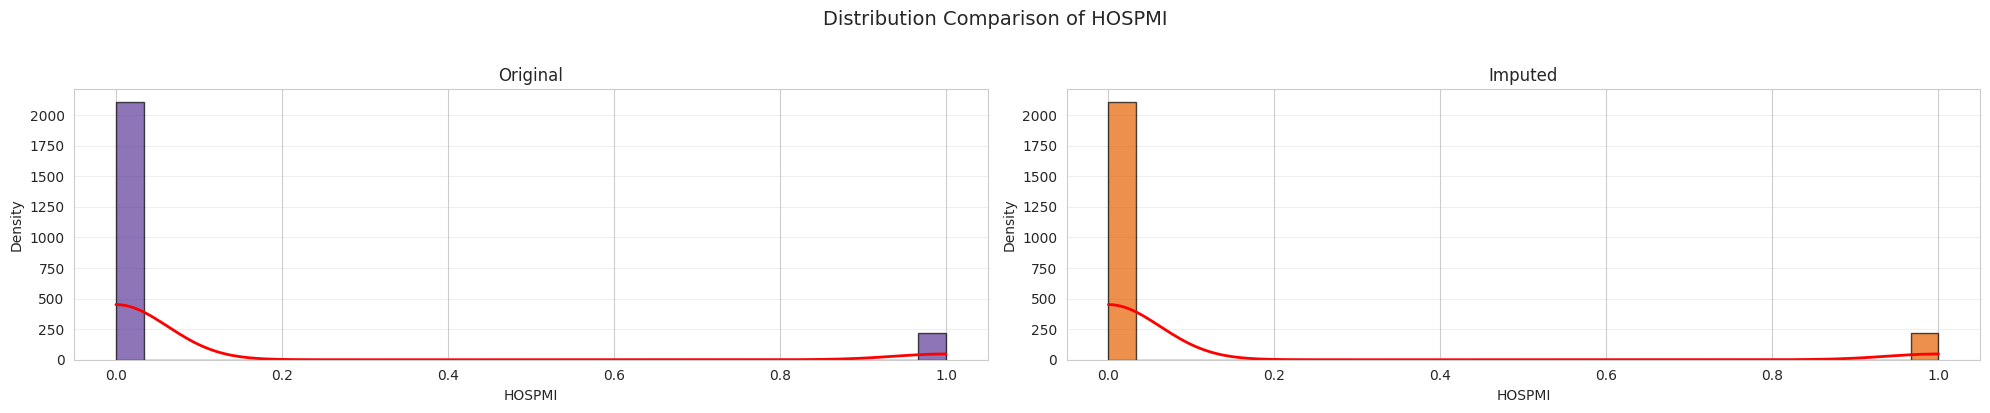

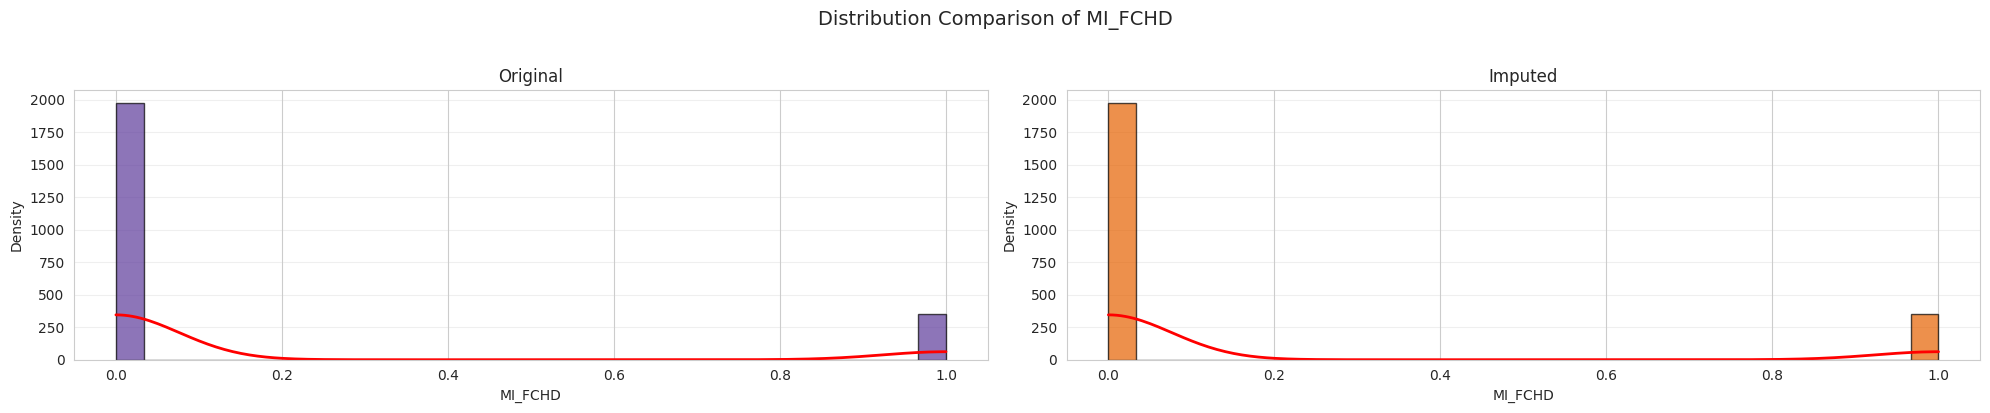

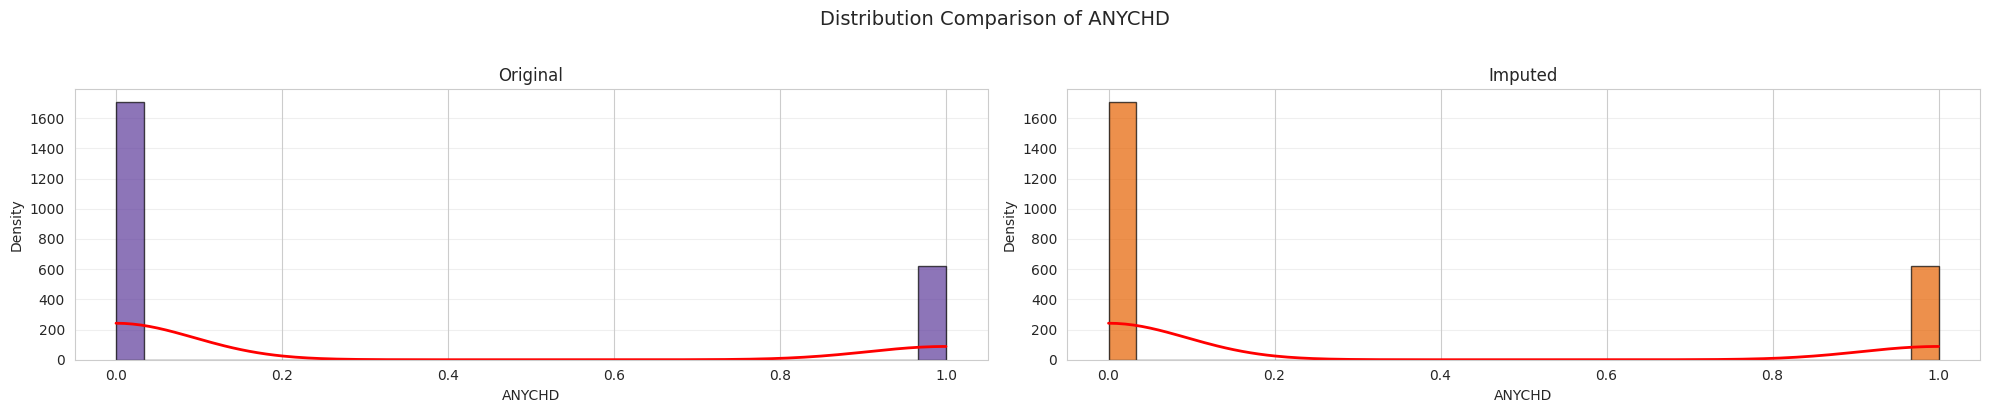

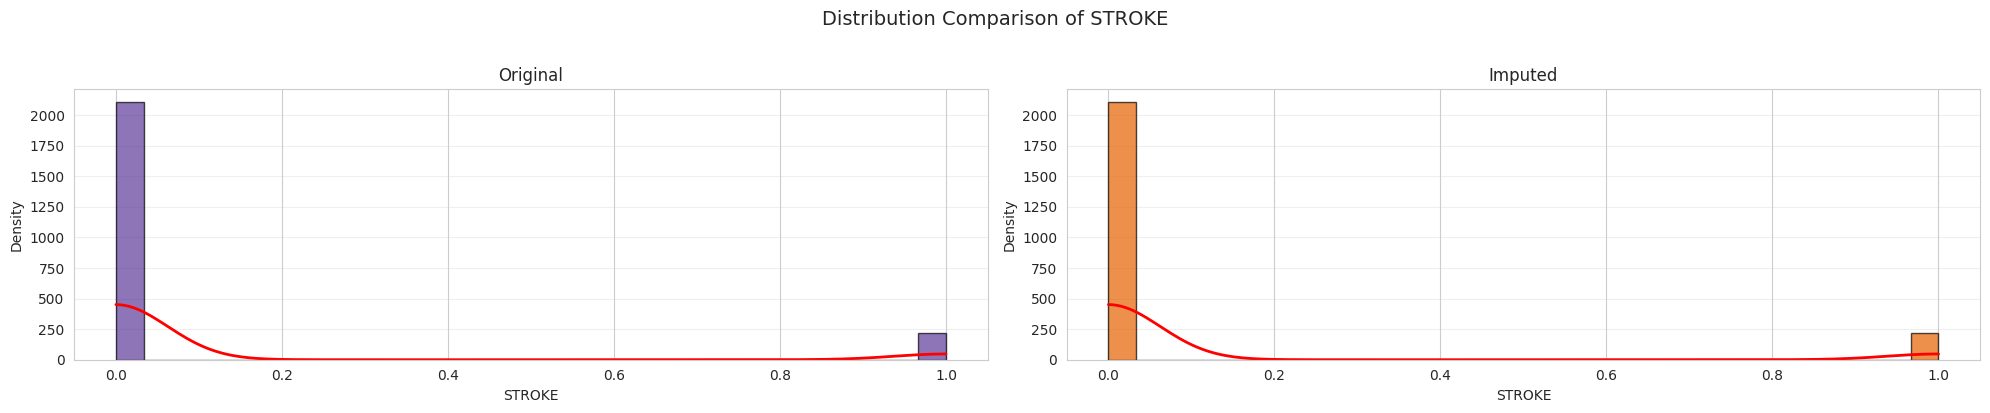

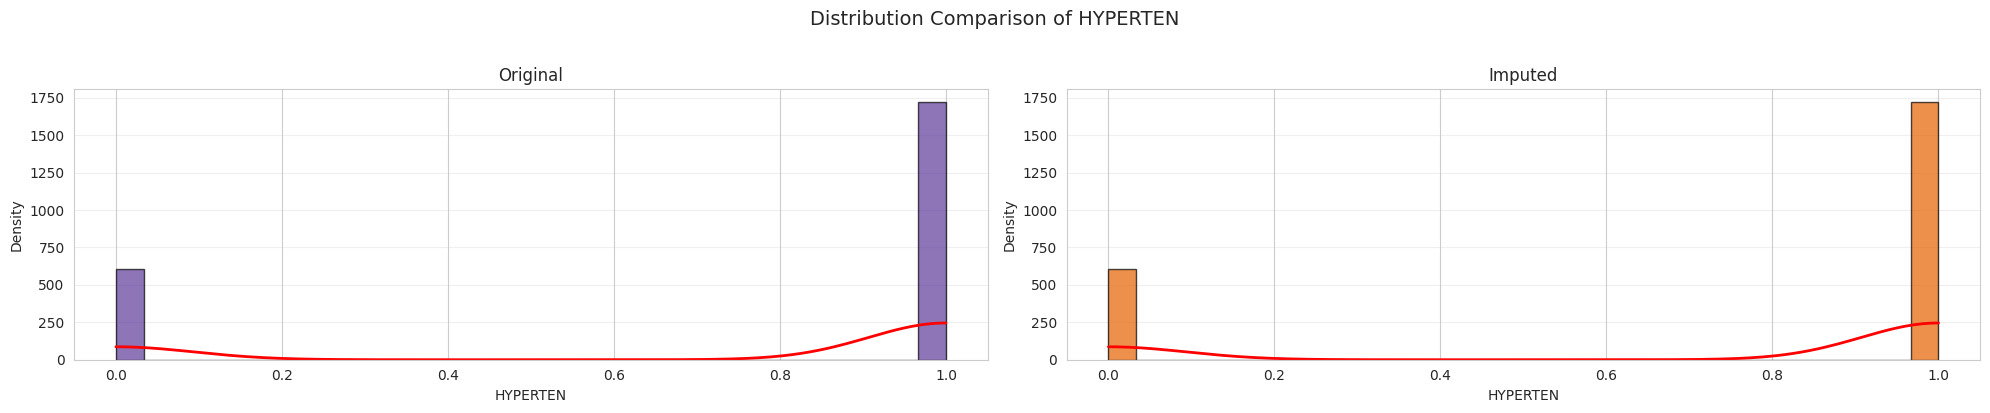

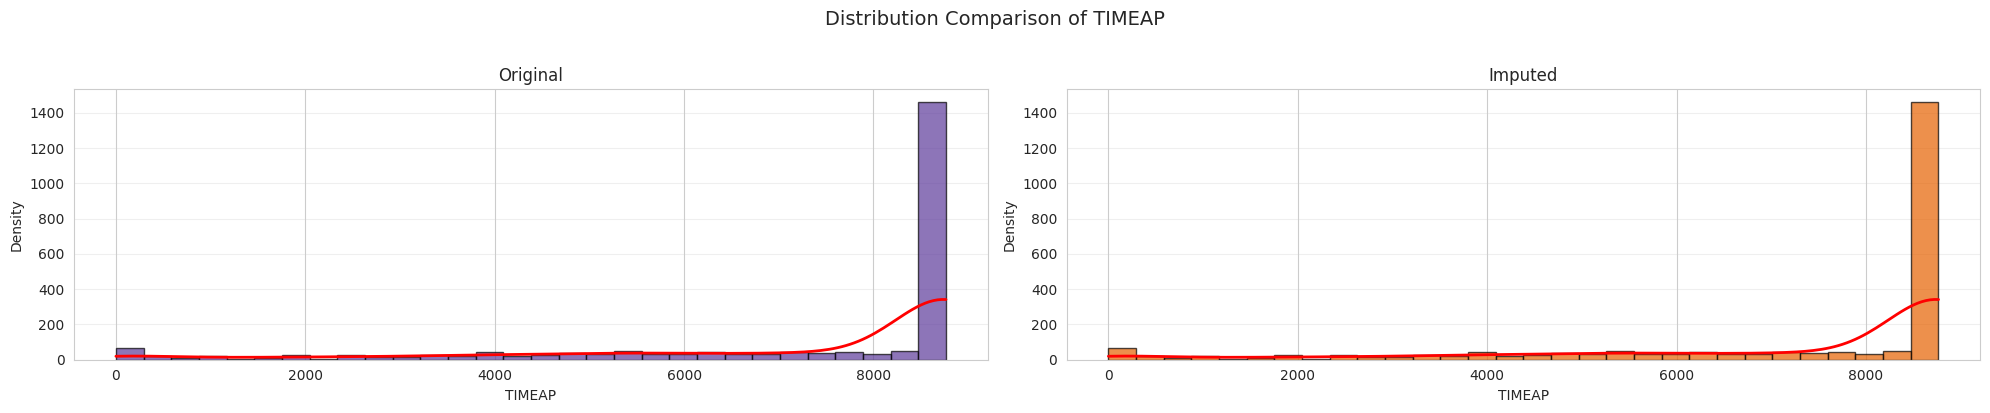

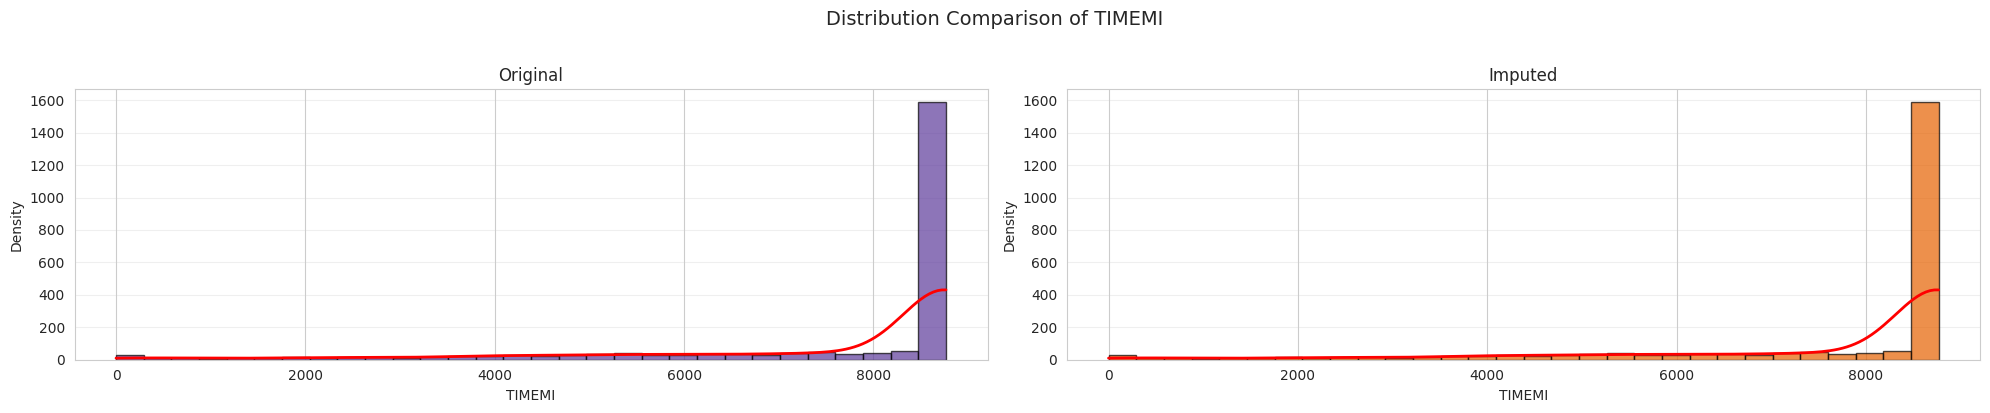

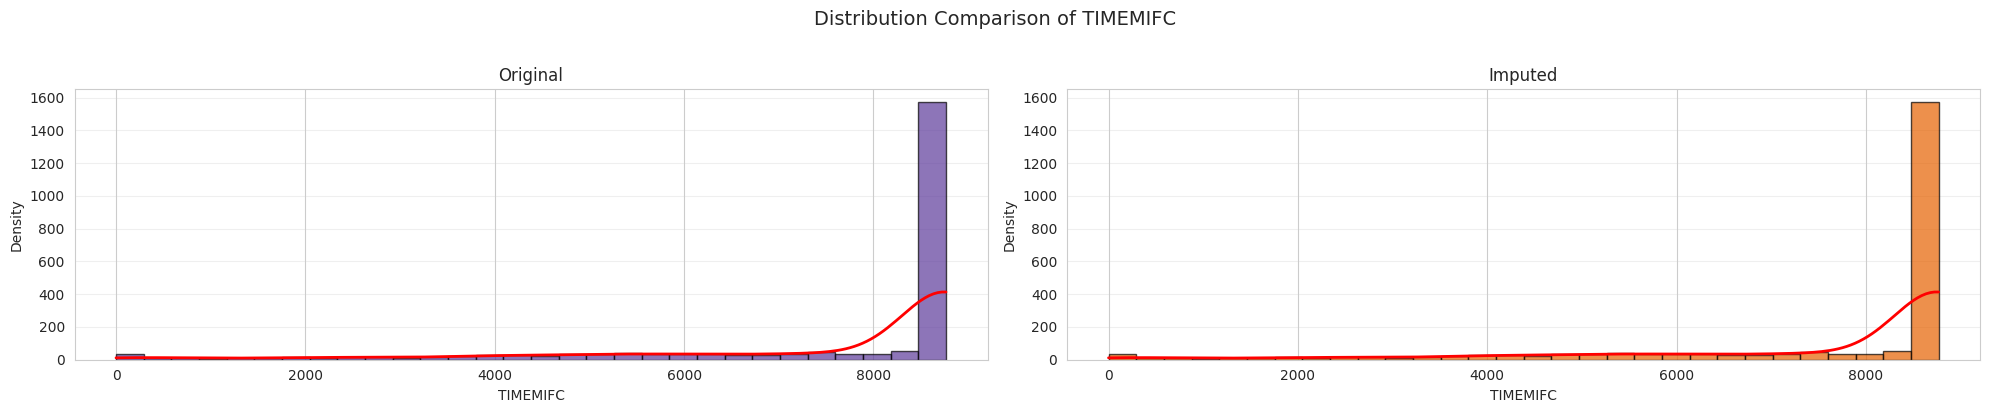

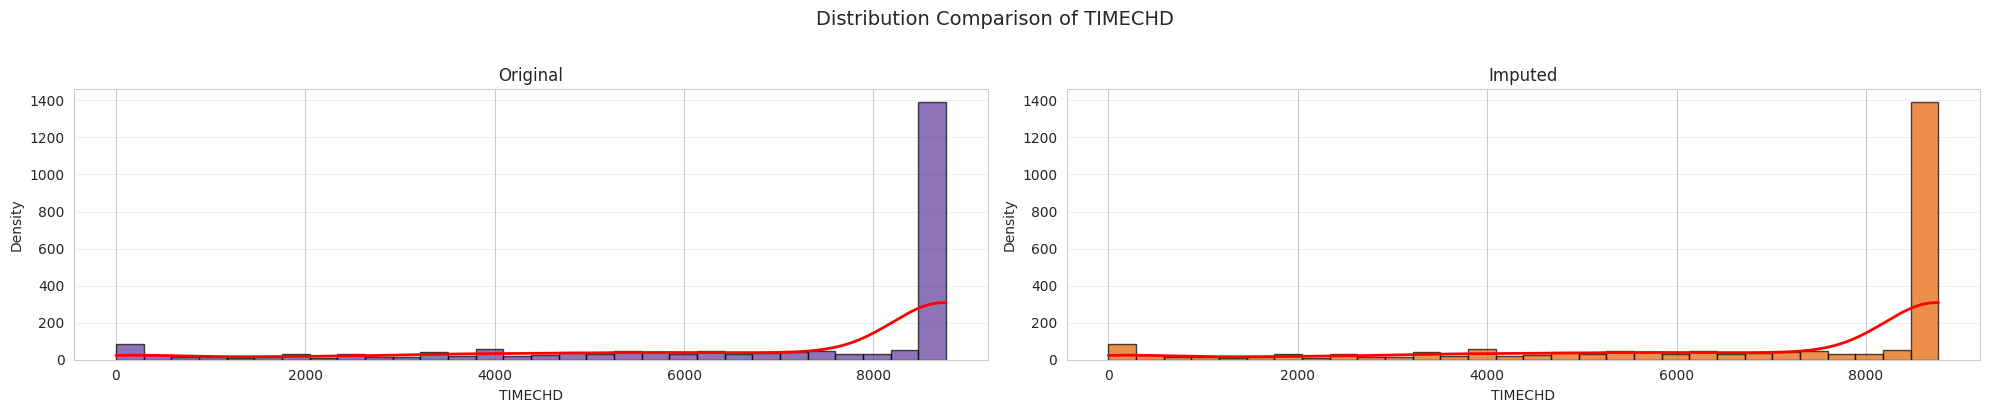

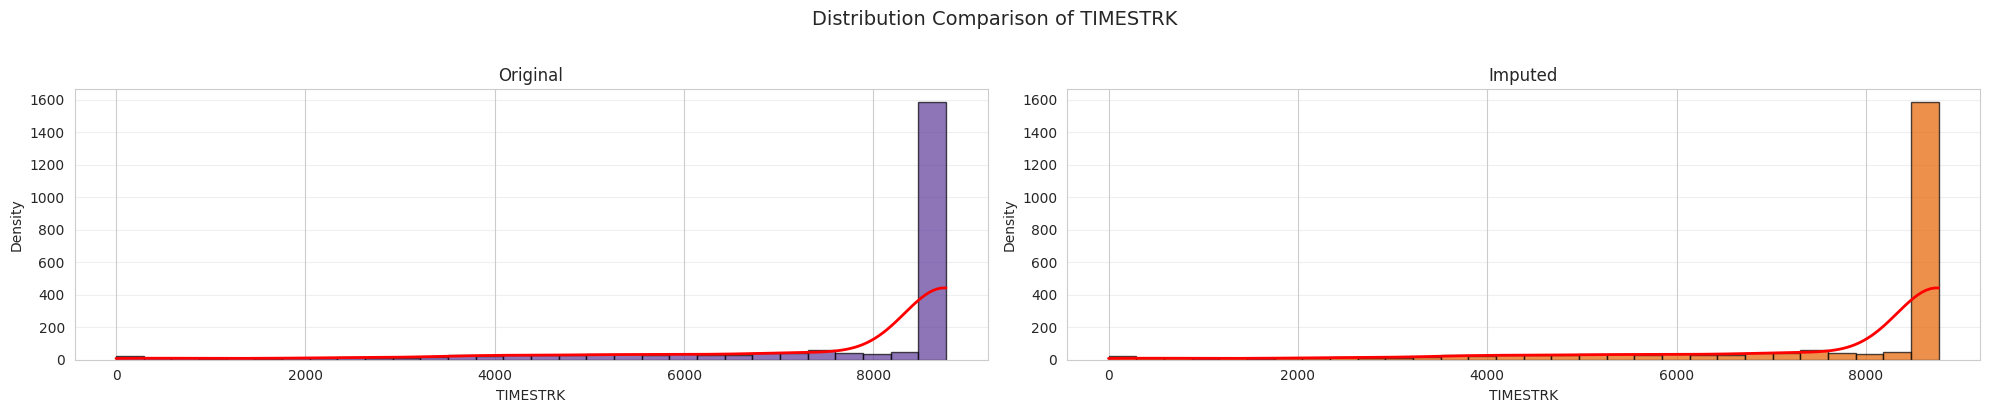

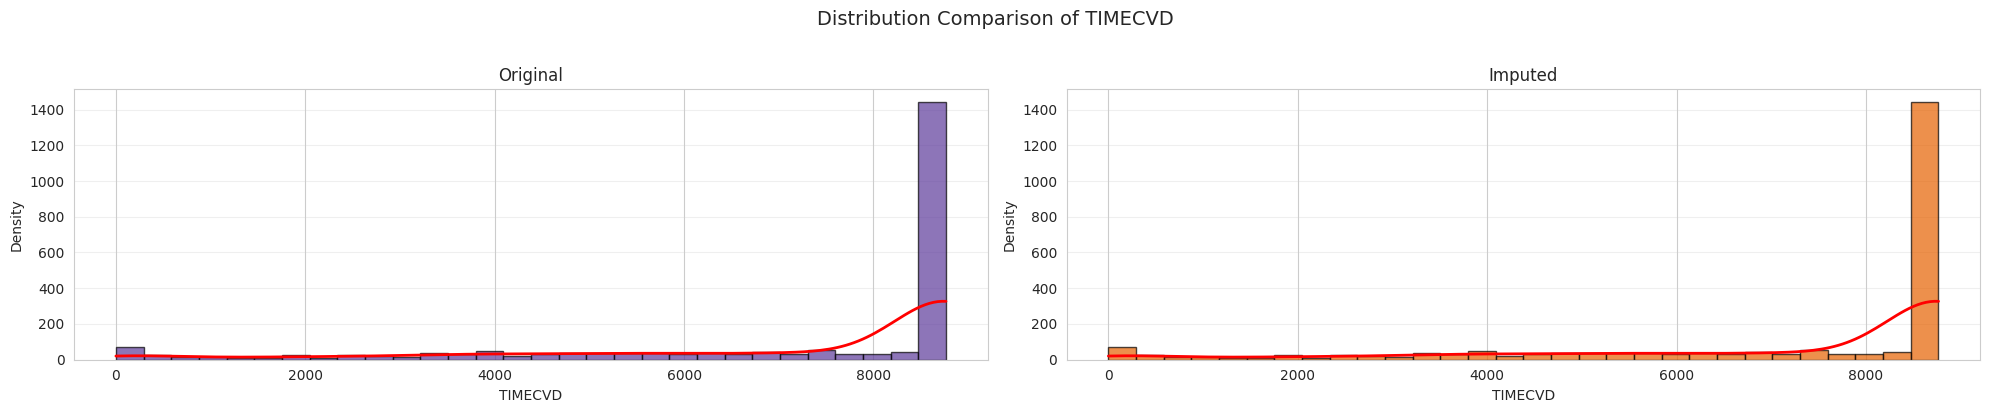

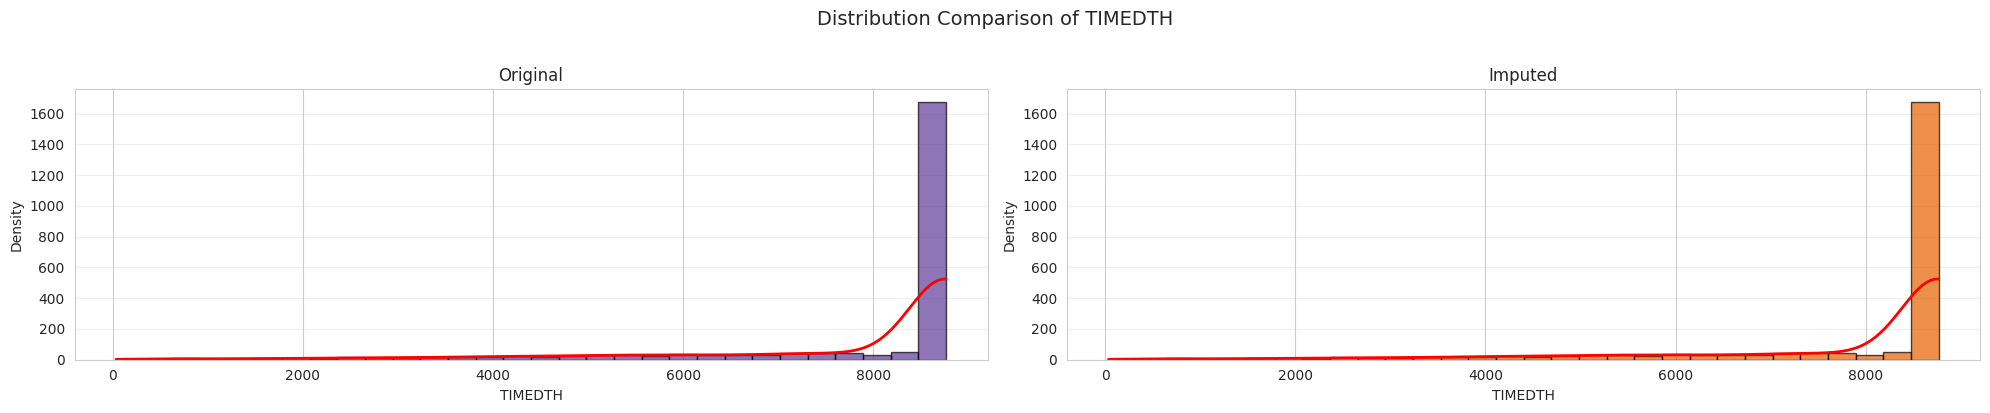

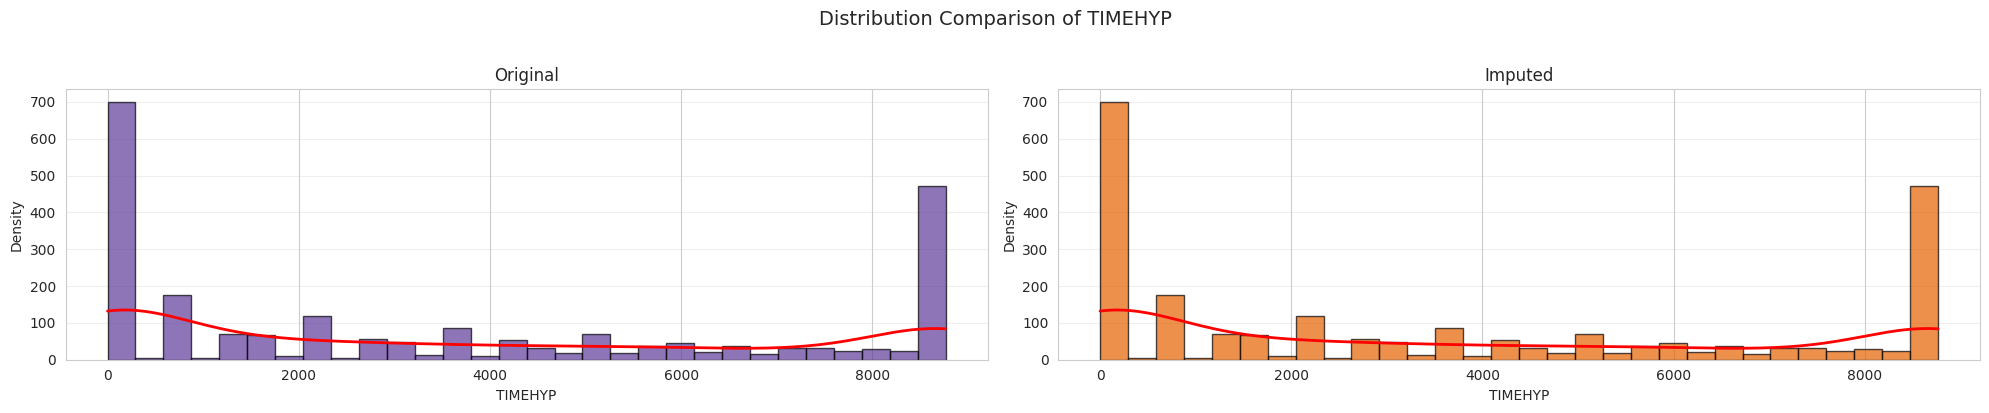

In [26]:
missing  = 0
misVariables = []
for data_imputed in ["X_train_imp", "X_test_imp"]:
    print(f"Checking {str(variable)}")
    if data_imputed == "X_train_imp": variable = X_train_imp; data = X_train
    else: variable = X_test_imp; data = X_test

    for column in variable.columns:
        defined_variable = column
        original = data[defined_variable]
        imputed = variable[defined_variable]

        fig, axes = plt.subplots(1, 2, figsize=(20, 4))

        axes[0].hist(original.dropna(), bins=30, alpha=0.7, color='#5D3A9B', edgecolor='black')
        if len(original.dropna()) > 1:
            from scipy import stats

            density = stats.gaussian_kde(original.dropna())
            xs = np.linspace(original.min(), original.max(), 200)
            axes[0].plot(xs, density(xs) * len(original.dropna()) * (original.max() - original.min()) / 30, 'r-',
                         linewidth=2)
        axes[0].set_xlabel(defined_variable)
        axes[0].set_ylabel('Density')
        axes[0].set_title('Original')
        axes[0].grid(axis='y', alpha=0.3)

        axes[1].hist(imputed, bins=30, alpha=0.7, color='#E66100', edgecolor='black')
        if len(imputed) > 1:
            density = stats.gaussian_kde(imputed)
            xs = np.linspace(imputed.min(), imputed.max(), 200)
            axes[1].plot(xs, density(xs) * len(imputed) * (imputed.max() - imputed.min()) / 30, 'r-', linewidth=2)
        axes[1].set_xlabel(defined_variable)
        axes[1].set_ylabel('Density')
        axes[1].set_title('Imputed')
        axes[1].grid(axis='y', alpha=0.3)

        plt.suptitle(f'Distribution Comparison of {defined_variable}', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

## Data skewness

In [ ]:
# TODO: check that it works properly

In [ ]:
data_imputed_unskewed = data_imputed.copy().drop(binary_cols, axis=1).drop(time_cols, axis=1)

for column in data_imputed_unskewed:
    skewness = stats.skew(data_imputed_unskewed[column])
    max_val = data_imputed[column].max()
    if skewness > 1:
        print(Fore.RED + f"{column} is strongly right skewed (skew: {skewness:.3f})")
        data_imputed_unskewed[column] = np.log1p(data_imputed_unskewed[column])
    elif skewness > 0.5:
        print(Fore.RED + f"{column} is moderately right skewed (skew: {skewness:.3f})")
        data_imputed_unskewed[column] = np.log1p(data_imputed_unskewed[column])
    elif stats.skew(data_imputed[column]) < -1:
        print(Fore.MAGENTA + f"{column} is strongly left skewed (skew: {skewness:.3f})")
        data_imputed_unskewed[column] = np.power(max_val + 1 - data_imputed_unskewed[column], 2)
    elif stats.skew(data_imputed[column]) < -0.5:
        print(Fore.MAGENTA + f"{column} is moderately left skewed (skew: {skewness:.3f})")
        data_imputed_unskewed[column] = np.power(max_val + 1 - data_imputed_unskewed[column], 2)
    else:
        print(Fore.GREEN + f"{column} is symmetric (skew: {skewness:.3f})")

In [ ]:
skewness_check(data_imputed_unskewed)

In [ ]:
distplots(data_imputed_unskewed)

In [ ]:
distplots(data.drop(binary_cols, axis=1).drop(time_cols, axis=1).drop(columns=['HDLC','LDLC']))

In [ ]:
data_imputed_unskewed = pd.concat([data_imputed_unskewed, data_imputed[time_cols], data_imputed[binary_cols]], axis=1)

## Research question exploration

### Exploring how the cholesterol differs between Smokers and Non-smokers

In [ ]:
mean_cholesterol = data_imputed.groupby('CURSMOKE')['TOTCHOL'].describe()
print("Mean Total Cholesterol:")
print(mean_cholesterol)

nonsmokers_chol = data_imputed[data_imputed['CURSMOKE'] == 0]['TOTCHOL']
smokers_chol = data_imputed[data_imputed['CURSMOKE'] == 1]['TOTCHOL']
_, levene_p = stats.levene(nonsmokers_chol, smokers_chol)

t_stat, p_value = stats.ttest_ind(smokers_chol, nonsmokers_chol,
                                  equal_var=False if levene_p < 0.05 else True)
print("\nIndependent T-Test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: The difference in mean total cholesterol is statistically significant.\n")
else:
    print("Result: There is no statistically significant difference in mean total cholesterol.\n")

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='CURSMOKE', y='TOTCHOL', data=data_imputed)


# Improve the plot labels
plt.title('Total Cholesterol by Smoking Status', fontsize=16)
plt.ylabel('Total Cholesterol', fontsize=12)
plt.xlabel('Current Smoker', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Smoker', 'Smoker'])

plt.text(0.5, 0.94, "p < 0.001" if p_value < 0.001 else round(p_value, 3),
         horizontalalignment='center',
         verticalalignment='top',
         transform=ax.transAxes, # Use axes-relative coordinates
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.2'))

plt.show()
plt.close()

### Exploring how the blood pressure differs between Smokers and Non-smokers


In [ ]:
mean_sys = data_imputed.groupby('CURSMOKE')['SYSBP'].describe()
mean_dias = data_imputed.groupby('CURSMOKE')['DIABP'].describe()

nonsmokers_sys = data_imputed[data_imputed['CURSMOKE'] == 0]['SYSBP']
smokers_sys = data_imputed[data_imputed['CURSMOKE'] == 1]['SYSBP']
nonsmokers_dias = data_imputed[data_imputed['CURSMOKE'] == 0]['DIABP']
smokers_dias = data_imputed[data_imputed['CURSMOKE'] == 1]['DIABP']

# Systolic blood pressure
t_stat, p_value = stats.ttest_ind(nonsmokers_sys, smokers_sys,
                                  equal_var=False if levene_p < 0.05 else True)
print("\nIndependent T-Test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: The difference in mean systolic blood pressure is statistically significant.\n")
else:
    print("Result: There is no statistically significant difference in mean systolic blood pressure.\n")

# Diastolic blood pressure
t_stat, p_value = stats.ttest_ind(nonsmokers_dias, smokers_dias,
                                  equal_var=False if levene_p < 0.05 else True)
print("\nIndependent T-Test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: The difference in mean diastolic blood pressure is statistically significant.\n")
else:
    print("Result: There is no statistically significant difference in mean diastolic blood pressure.\n")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='CURSMOKE', y='SYSBP', data=data_imputed, ax=axes[0])
axes[0].set_title('Systolic blood pressure by Smoking Status', fontsize=16)
axes[0].set_ylabel('Systolic blood pressure (mmHg)', fontsize=12)
axes[0].set_xlabel('Current Smoker', fontsize=12)
axes[0].set_xticks(ticks=[0, 1])
axes[0].set_xticklabels(['Non-Smoker', 'Smoker'])

axes[0].text(0.5, 0.94, "p < 0.001" if p_value < 0.001 else round(p_value, 3),
             horizontalalignment='center',
             verticalalignment='top',
             transform=axes[0].transAxes,
             fontsize=12,
             bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.2'))

sns.boxplot(x='CURSMOKE', y='DIABP', data=data_imputed, ax=axes[1])
axes[1].set_title('Diastolic blood pressure by Smoking Status', fontsize=16)
axes[1].set_ylabel('Diastolic blood pressure (mmHg)', fontsize=12)
axes[1].set_xlabel('Current Smoker', fontsize=12)
axes[1].set_xticks(ticks=[0, 1])
axes[1].set_xticklabels(['Non-Smoker', 'Smoker'])

axes[1].text(0.5, 0.94, "p < 0.001" if p_value < 0.001 else round(p_value, 3),
             horizontalalignment='center',
             verticalalignment='top',
             transform=axes[1].transAxes,
             fontsize=12,
             bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.close()

### Exploring how age differs for people developed Cardiovascular Disease based on their smoking status?

In [ ]:
patients_with_cvd = data_imputed[data_imputed['CVD'] == 1].copy()
if patients_with_cvd.empty:
    raise ValueError("No individuals with CVD found in the dataset.")

age_cvd_per_smoker_group = patients_with_cvd.groupby('CURSMOKE')['AGE'].describe()
print("Age Statistics for Patients with CVD:")
print(age_cvd_per_smoker_group)
print("\n")

smokers_age_with_cvd = patients_with_cvd[patients_with_cvd['CURSMOKE'] == 1]['AGE']
nonsmokers_age_without_cvd = patients_with_cvd[patients_with_cvd['CURSMOKE'] == 0]['AGE']

if smokers_age_with_cvd.empty or smokers_age_with_cvd.empty:
    raise ValueError("Not enough data for one or both groups to run a t-test.")

_, levene_p = stats.levene(smokers_age_with_cvd, nonsmokers_age_without_cvd)

t_stat, p_value = stats.ttest_ind(smokers_age_with_cvd, nonsmokers_age_without_cvd,
                          equal_var=False if levene_p < 0.05 else True)
print("\nIndependent T-Test Results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}\n")
if p_value < 0.05:
    print("Result: Among CVD patients, there is a significant age difference between smokers and non-smokers.\n")
else:
    print("Result: Among CVD patients, there is no significant age difference between smokers and non-smokers.\n")

plt.figure(figsize=(8, 6))

ax = sns.boxplot(x='CURSMOKE', y='AGE', data=patients_with_cvd)

# To see individual data points
sns.stripplot(x='CURSMOKE', y='AGE', data=patients_with_cvd, color=".25", alpha=0.3)

plt.title('Age of Patients with Cardiovascular Disease by Smoking Status', fontsize=16)
plt.ylabel('Age', fontsize=12)
plt.xlabel('Current Smoker', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Smoker', 'Smoker'])

plt.text(0.5, 0.91, "p < 0.001" if p_value < 0.001 else round(p_value, 3),
         horizontalalignment='center',
         verticalalignment='top',
         transform=ax.transAxes, # Use axes-relative coordinates
         fontsize=12,
         bbox=dict(facecolor='white', alpha=0.5, boxstyle='round,pad=0.2'))

plt.show()
plt.close()


# Machine learning

## Logistic Regression

### Baseline model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
lr_baseline = LogisticRegression(max_iter=1000, random_state=2025)
lr_baseline.fit(X_train, Y_train)
y_pred_base = lr_baseline.predict(X_test)

print(f"Baseline Accuracy: {f1_score(Y_test, y_pred_base):.4f}")

### Top features selection

In [ ]:
from sklearn.feature_selection import RFE

rng = np.random.RandomState(seed=2025)
seeds = rng.randint(low = 0, high = 10000, size = 7)
print(f"Generated Seeds: {seeds}")

votes = np.zeros(X_train.shape[1], dtype=int)

for i, seed in enumerate(seeds):

    model = LogisticRegression(random_state=seed)

    #Recursive Feature Elimination
    rfe = RFE(estimator=model, n_features_to_select=10)
    rfe.fit(X_train, Y_train)

    votes += rfe.support_.astype(int)

    print(f"Run {i+1}/{7} (Seed {seed}): Complete.")

In [ ]:
mask = votes > 0
top_features = X_train.columns[mask].tolist()
top_features

## Random forest

In [ ]:
X, y = data_imputed_unskewed[['SEX', 'TOTCHOL', 'AGE', 'SYSBP', 'DIABP', 'CURSMOKE', 'CIGPDAY', 'BMI', 'DIABETES', 'BPMEDS', 'GLUCOSE', 'PREVCHD']], data_imputed_unskewed['ANYCHD']

In [ ]:
clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=2023, class_weight='balanced')
clf = clf.fit(X_train, Y_train)
prediction = clf.predict(X_test)

print('Accuracy: ', accuracy_score(y_true=Y_test, y_pred=prediction))

cm = confusion_matrix(y_true=Y_test, y_pred=prediction, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot();


In [ ]:
fig_tree, ax = plt.subplots(figsize = (500, 200))

tree.plot_tree(clf, ax=ax, impurity = False, feature_names= X.columns, class_names= ("Died", "Survived") ,proportion = True, rounded = True, precision = 2, filled = True);

#plt.savefig('TreePlot.pdf', bbox_inches='tight')